# Home Credit Default Risk — Feature Engineering

## Notebook Overview

This notebook creates a clean, interpretable, and model-ready feature set for the Home Credit Default Risk problem.

The feature engineering decisions are based on the completed univariate, multivariate, temporal, structural, and financial relationship analyses. The purpose of this notebook is not to repeat those analyses. Its purpose is to implement the final evidence-based decisions using simple, readable, and reproducible code.

The notebook begins with the integrated applicant-level training and testing datasets. Existing features will be cleaned where necessary, and new features will be created from applicant information, financial capacity, repayment behaviour, credit history, temporal change, and cross-source financial stress.

The main workflow is:

1. Load the integrated training and testing datasets.
2. Load only the essential EDA decision files.
3. Remove exact and deterministic duplicate features.
4. Correct known invalid values and sentinel values.
5. Standardise reviewed categorical values and data types.
6. Create source-history and missingness-summary features.
7. Create zero-activity and exposure indicators.
8. Engineer application-level affordability and household-capacity features.
9. Engineer applicant stability, external-score, enquiry, and property features.
10. Engineer Bureau, Instalment, Credit Card, POS Cash, and Previous Application features.
11. Create exposure-normalised behavioural ratios.
12. Create validated temporal-change features.
13. Create cross-source coverage, stress, consensus, and disagreement features.
14. Add a small set of validated interaction and cyclical features.
15. Prepare main, lean, compact, and fairness-comparison feature lists.
16. Validate train-test alignment and save the final feature-engineered datasets.

## Design Principles

- The notebook follows a direct, step-by-step workflow.
- Simple tasks are implemented with simple code.
- Classes and large software-style frameworks are not used.
- Small helper functions are used only when they reduce repetition.
- Every engineered feature has a clear financial, behavioural, temporal, or structural meaning.
- Feature creation is identical for the training and testing datasets.
- The target and applicant identifier are never used to create predictor features.
- Exact and deterministic duplicates may be removed, but near-redundant features are handled through separate feature lists.
- Missing values are interpreted carefully because missingness may represent absent financial history, non-applicability, or data-quality issues.
- Zero values are not treated uniformly because zero may represent no activity, no adverse event, no exposure, or unavailable history.
- Large-scale automatic interaction generation is avoided.
- Only validated and interpretable interaction features are created.
- Model-specific preprocessing is intentionally excluded from this notebook.

## Modelling Boundary

This notebook does not perform model training, cross-validation, target encoding, supervised binning, scaling, PCA fitting, or model-based feature selection.

The following operations will be completed inside the model-training notebook and within the appropriate training folds:

- Missing-value imputation
- Scaling
- One-hot encoding
- Target encoding
- Weight-of-evidence encoding
- Yeo-Johnson transformation
- Quantile transformation
- Supervised binning
- PCA experiments
- Model-based feature selection
- Model training and blending

## Checkpoint Strategy

Large processing blocks are saved as parquet checkpoints. These checkpoints allow the notebook to resume after interruption without repeating all previous feature engineering steps.

The main checkpoints will represent:

- Cleaned integrated data
- Application-level engineered data
- Behavioural-source engineered data
- Final feature-engineered data

## Final Outputs

The notebook will create:

- Final feature-engineered training data
- Final feature-engineered testing data
- Engineered feature list
- Removed feature list
- Main feature list
- Lean feature list
- Compact explainable feature list
- Fairness exclusion list
- Feature engineering summary

The final datasets will be used as the direct inputs for the separate model-training notebook.

# Step 0 — Setup and Data Loading

This step imports the required libraries, defines the project paths, creates the output folders, and loads the integrated training and testing datasets.

Only a small number of structural checks are performed to confirm that the target, applicant identifier, dataset shapes, and predictor columns are correct.

No feature is created, removed, transformed, imputed, or encoded in this step.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk")

TRAIN_PATH = PROJECT_ROOT / "Data" / "Processed" / "home_credit_train_integrated.parquet"
TEST_PATH = PROJECT_ROOT / "Data" / "Processed" / "home_credit_test_integrated.parquet"

OUTPUT_DIR = PROJECT_ROOT / "Feature_engineering"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
RANDOM_STATE = 42

print("Project paths are ready.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project paths are ready.
Project root: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk
Output directory: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering


In [2]:
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train_predictors = [column for column in train.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
test_predictors = [column for column in test.columns if column != ID_COLUMN]

assert TARGET_COLUMN in train.columns, "TARGET is missing from the training dataset."
assert TARGET_COLUMN not in test.columns, "TARGET must not exist in the testing dataset."
assert ID_COLUMN in train.columns, "SK_ID_CURR is missing from the training dataset."
assert ID_COLUMN in test.columns, "SK_ID_CURR is missing from the testing dataset."
assert train[ID_COLUMN].is_unique, "Training applicant identifiers are not unique."
assert test[ID_COLUMN].is_unique, "Testing applicant identifiers are not unique."
assert set(train_predictors) == set(test_predictors), "Training and testing predictor columns do not match."

test = test[[ID_COLUMN] + train_predictors]

print(f"Training shape: {train.shape}")
print(f"Testing shape: {test.shape}")
print(f"Predictor count: {len(train_predictors)}")
print(f"Target default rate: {train[TARGET_COLUMN].mean():.4%}")
print(f"Training memory: {train.memory_usage(deep=True).sum() / (1024 ** 3):.3f} GB")
print(f"Testing memory: {test.memory_usage(deep=True).sum() / (1024 ** 3):.3f} GB")
print("Training and testing predictors are aligned.")

Training shape: (307511, 2568)
Testing shape: (48744, 2567)
Predictor count: 2566
Target default rate: 8.0729%
Training memory: 2.892 GB
Testing memory: 0.458 GB
Training and testing predictors are aligned.


### Basic Dataset Overview

,dataset,rows,columns,predictors,memory_gb
0,Training,307511,2568,2566,2.892286
1,Testing,48744,2567,2566,0.458426


,target,applicant_count,percentage
0,0,282686,91.927118
1,1,24825,8.072882


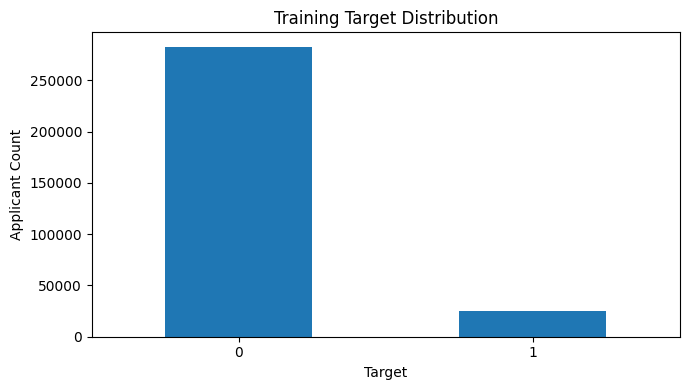

STEP 0 COMPLETE
The integrated datasets were loaded successfully.
No feature was created, removed, transformed, imputed, or encoded.


In [3]:
dataset_overview = pd.DataFrame({
    "dataset": ["Training", "Testing"],
    "rows": [train.shape[0], test.shape[0]],
    "columns": [train.shape[1], test.shape[1]],
    "predictors": [len(train_predictors), len(test_predictors)],
    "memory_gb": [
        train.memory_usage(deep=True).sum() / (1024 ** 3),
        test.memory_usage(deep=True).sum() / (1024 ** 3)
    ]
})

display(dataset_overview)

target_distribution = train[TARGET_COLUMN].value_counts().sort_index().rename_axis("target").reset_index(name="applicant_count")
target_distribution["percentage"] = target_distribution["applicant_count"] / len(train) * 100

display(target_distribution)

plt.figure(figsize=(7, 4))
train[TARGET_COLUMN].value_counts().sort_index().plot(kind="bar")
plt.title("Training Target Distribution")
plt.xlabel("Target")
plt.ylabel("Applicant Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("=" * 80)
print("STEP 0 COMPLETE")
print("The integrated datasets were loaded successfully.")
print("No feature was created, removed, transformed, imputed, or encoded.")
print("=" * 80)

# Step 1.1 — Load Essential EDA Evidence

This step loads the essential evidence and decision files created during the completed univariate, multivariate, structural, nonlinear, and temporal analyses.

The files are inspected directly so that their exact columns and structures are visible before any feature-engineering decision is implemented.

The univariate master provides feature categories, missingness evidence, transformation reviews, sentinel information, and manual decisions. The multivariate files provide final feature roles, structural identities, redundancy decisions, nonlinear target shapes, and temporal evidence.

No evidence tables are merged in this step. No feature is created, removed, transformed, imputed, or encoded.

In [4]:
UNIVARIATE_PATH = PROJECT_ROOT / "Notebook" / "Eda_report" / "Final_Univariate" / "master_file_univariate.csv"

STEP7_DIR = PROJECT_ROOT / "Notebook" / "relationship_outputs" / "Step_7_Final_Multivariate_Completion" / "tables"
STEP6_DIR = PROJECT_ROOT / "Notebook" / "relationship_outputs" / "Step_6_Global_Feature_Architecture" / "tables"
TEMPORAL_DIR = PROJECT_ROOT / "Notebook" / "Relationship_report" / "Tables" / "Step_5_Temporal_Financial_States"

FINAL_MULTIVARIATE_PATH = STEP7_DIR / "final_multivariate_feature_registry.parquet"
FINAL_DECISION_PATH = STEP7_DIR / "final_feature_decision_register.parquet"
NONLINEAR_PATH = STEP7_DIR / "univariate_nonlinear_geometry.parquet"
FEATURE_IDENTITY_PATH = STEP6_DIR / "6.03_feature_identity_and_lineage_registry.parquet"
STRUCTURAL_ROLE_PATH = STEP6_DIR / "6.09_feature_role_register.parquet"
TEMPORAL_FEATURE_PATH = TEMPORAL_DIR / "5.1_temporal_feature_registry.csv"

evidence_paths = {
    "univariate_master": UNIVARIATE_PATH,
    "final_multivariate": FINAL_MULTIVARIATE_PATH,
    "final_decision": FINAL_DECISION_PATH,
    "nonlinear_geometry": NONLINEAR_PATH,
    "feature_identity": FEATURE_IDENTITY_PATH,
    "structural_role": STRUCTURAL_ROLE_PATH,
    "temporal_features": TEMPORAL_FEATURE_PATH
}

missing_files = [f"{name}: {path}" for name, path in evidence_paths.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError("Missing evidence files:\n" + "\n".join(missing_files))

univariate_master = pd.read_csv(UNIVARIATE_PATH, low_memory=False)
final_multivariate = pd.read_parquet(FINAL_MULTIVARIATE_PATH)
final_decision = pd.read_parquet(FINAL_DECISION_PATH)
nonlinear_geometry = pd.read_parquet(NONLINEAR_PATH)
feature_identity = pd.read_parquet(FEATURE_IDENTITY_PATH)
structural_role = pd.read_parquet(STRUCTURAL_ROLE_PATH)
temporal_features = pd.read_csv(TEMPORAL_FEATURE_PATH, low_memory=False)

print("Essential EDA evidence files loaded successfully.")

Essential EDA evidence files loaded successfully.


In [5]:
evidence_tables = {
    "Univariate Master": univariate_master,
    "Final Multivariate Registry": final_multivariate,
    "Final Feature Decision Register": final_decision,
    "Nonlinear Geometry": nonlinear_geometry,
    "Feature Identity and Lineage": feature_identity,
    "Structural Feature Roles": structural_role,
    "Temporal Feature Registry": temporal_features
}

evidence_summary = pd.DataFrame([
    {
        "evidence": name,
        "rows": table.shape[0],
        "columns": table.shape[1],
        "memory_mb": table.memory_usage(deep=True).sum() / (1024 ** 2)
    }
    for name, table in evidence_tables.items()
])

display(evidence_summary)

for name, table in evidence_tables.items():
    print("=" * 100)
    print(name)
    print(f"Shape: {table.shape}")
    print(f"First 40 columns: {table.columns[:40].tolist()}")
    display(table.head(2))

print("=" * 100)
print("STEP 1 COMPLETE")
print("The essential EDA evidence files were loaded and inspected.")
print("No evidence tables were merged and no feature-engineering decision was applied.")
print("=" * 100)

,evidence,rows,columns,memory_mb
0,Univariate Master,2568,627,42.341532
1,Final Multivariate Registry,2566,56,3.865561
2,Final Feature Decision Register,2566,13,1.013150
3,Nonlinear Geometry,2566,15,0.911345
4,Feature Identity and Lineage,2566,24,2.314581
5,Structural Feature Roles,2566,13,1.075263
6,Temporal Feature Registry,11,15,0.012457


Univariate Master
Shape: (2568, 627)
First 40 columns: ['feature', 'master_feature_category', 'master_feature_family', 'master_dtype_semantic', 'master_model_role', 'master_final_univariate_decision', 'master_drop_now', 'master_next_stage', 'master_feature_engineering_status', 'master_decision_confidence_from_univariate_only', 'master_problem_flags', 'master_univariate_problem_and_route_summary', 'master_flag_high_missing', 'master_flag_extreme_missing', 'master_flag_large_missing_gap', 'master_flag_high_numeric_skew', 'master_flag_high_numeric_outlier', 'master_flag_zero_heavy', 'master_flag_rare_binary_or_near_constant', 'master_flag_rare_nominal_mass', 'master_flag_categorical_shift', 'master_flag_special_case', 'master_flag_manual_reviewed', 'final_univariate_feature_category', 'final_univariate_model_feature_role', 'final_univariate_universal_role', 'final_univariate_universal_dtype_train', 'final_univariate_universal_dtype_test', 'final_univariate_universal_missing_pct_train', 'f

,feature,master_feature_category,master_feature_family,master_dtype_semantic,master_model_role,master_final_univariate_decision,master_drop_now,master_next_stage,master_feature_engineering_status,master_decision_confidence_from_univariate_only,master_problem_flags,master_univariate_problem_and_route_summary,master_flag_high_missing,master_flag_extreme_missing,master_flag_large_missing_gap,master_flag_high_numeric_skew,master_flag_high_numeric_outlier,master_flag_zero_heavy,master_flag_rare_binary_or_near_constant,master_flag_rare_nominal_mass,master_flag_categorical_shift,master_flag_special_case,master_flag_manual_reviewed,final_univariate_feature_category,final_univariate_model_feature_role,final_univariate_universal_role,final_univariate_universal_dtype_train,final_univariate_universal_dtype_test,final_univariate_universal_missing_pct_train,final_univariate_universal_missing_pct_test,final_univariate_universal_missing_gap_pct,final_univariate_universal_n_unique_train,final_univariate_universal_n_unique_test,final_univariate_universal_basic_review_flag,final_univariate_universal_basic_review_reason,final_univariate_numeric_numeric_family,final_univariate_numeric_missing_band,final_univariate_numeric_skew_band,final_univariate_numeric_zero_band,final_univariate_numeric_outlier_band,final_univariate_numeric_section_review_flag,final_univariate_numeric_section_review_reason,final_univariate_binary_categorical_family,final_univariate_binary_missing_pct_train,final_univariate_binary_n_unique_train,final_univariate_binary_zero_pct_train,final_univariate_binary_one_pct_train,final_univariate_binary_one_pct_gap,final_univariate_binary_constant_train,final_univariate_binary_constant_test,...,ordinal_temporal_uppercase_level_count,ordinal_temporal_lowercase_level_count,ordinal_temporal_sample_levels,ordinal_temporal_top_levels_train,ordinal_temporal_special_numeric_level_present,ordinal_temporal_test_only_special_level_present,ordinal_temporal_expected_order_note,ordinal_temporal_missing_route,ordinal_temporal_cardinality_route,ordinal_temporal_rare_level_route,ordinal_temporal_dominance_route,ordinal_temporal_level_support_route,ordinal_temporal_distribution_shift_route,ordinal_temporal_order_support_route,ordinal_temporal_possible_encoding_route,ordinal_temporal_route_modifiers,ordinal_temporal_risk_score,ordinal_temporal_risk_level,ordinal_temporal_manual_check_needed,ordinal_temporal_manual_check_reason,ordinal_temporal_statistical_decision_summary,binary_manual_manual_decision_status,binary_manual_final_encoding_decision,binary_manual_final_missing_handling_decision,binary_manual_final_validation_decision,binary_manual_manual_risk_level,binary_manual_manual_check_needed,binary_manual_manual_check_reason,binary_manual_drop_now,binary_manual_next_stage_use,nominal_manual_manual_encoding_decision,nominal_manual_manual_risk_level,nominal_manual_manual_review_needed,nominal_manual_manual_decision_reason,nominal_manual_next_step_use,nominal_manual_drop_now,ordinal_manual_manual_decision_status,ordinal_manual_final_encoding_decision,ordinal_manual_final_order_or_mapping,ordinal_manual_special_handling_decision,ordinal_manual_manual_risk_level,ordinal_manual_manual_check_needed,ordinal_manual_manual_check_reason,ordinal_manual_drop_now,ordinal_manual_next_stage_use,special_special_case_type,special_special_case_reason,special_special_next_action,special_special_validation_stage,special_special_drop_now
0,AMT_ANNUITY,continuous_amount_numeric,amount_value,numeric,candidate_predictor,standard_candidate_for_next_stage,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,low_to_medium_standard,standard_profile,standard_univariate_profile || P3_normal_type_specific_eda || route_to_continuous_numeric_eda || continuous_numeric_...,0,0,0,0,0,0,0,0,0,0,0,continuous_amount_numeric,candidate_predictor,feature,float32,float32,0.003902,0.049237,0.045335,13672,7491.0,False,NaN,continuous,low,high,none,moderate,0.0,

Final Multivariate Registry
Shape: (2566, 56)
First 40 columns: ['feature', 'feature_index', 'source', 'declared_category', 'empirical_category', 'validated_category', 'train_dtype', 'test_dtype', 'train_missing_rate', 'test_missing_rate', 'missing_rate_drift', 'exact_cardinality_if_required', 'time_window', 'lineage_base', 'inner_aggregation', 'outer_aggregation', 'category_disagreement', 'target_correlation', 'absolute_target_information', 'present_default_rate', 'missing_default_rate', 'missingness_default_rate_gap', 'community_id', 'community_order', 'maximum_stable_dependency', 'strongest_partner', 'uniqueness_score', 'relationship_stability_score', 'cross_source_bridge_count', 'representative_suitability', 'provisional_feature_role', 'redundancy_status', 'analytical_role', 'generic_lineage_warning', 'confirmation_mutual_information', 'risk_range', 'shape_label', 'shape_agreement', 'max_interaction_gain', 'interaction_pair_count']


,feature,feature_index,source,declared_category,empirical_category,validated_category,train_dtype,test_dtype,train_missing_rate,test_missing_rate,missing_rate_drift,exact_cardinality_if_required,time_window,lineage_base,inner_aggregation,outer_aggregation,category_disagreement,target_correlation,absolute_target_information,present_default_rate,missing_default_rate,missingness_default_rate_gap,community_id,community_order,maximum_stable_dependency,strongest_partner,uniqueness_score,relationship_stability_score,cross_source_bridge_count,representative_suitability,provisional_feature_role,redundancy_status,analytical_role,generic_lineage_warning,confirmation_mutual_information,risk_range,shape_label,shape_agreement,max_interaction_gain,interaction_pair_count,max_absolute_pca_loading,pca_component_count_above_010,exact_duplicate_flag,deterministic_transform_duplicate_flag,nonlinear_interaction_driver_flag,core_latent_driver_flag,missingness_signal_flag,temporal_contrast_flag,final_primary_role,evidence_tags,retain_for_modelling,retain_for_interpretation,retain_for_interaction,retain_missing_indicator,candidate_for_removal,manual_review_required
0,NAME_CONTRACT_TYPE,0,Current application,categorical_binary,categorical_string,categorical_binary,category,category,0.0,0.0,0.0,2.0,Lifetime or non-temporal,name_contract_type,none,none,NONE,0.030894,0.030894,0.080729,NaN,NaN,5,17,0.099193,FLAG_DOCUMENT_3,0.900807,0.894073,0,0.693416,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,False,0.000595,0.027910,MISSINGNESS_DOMINATED,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | MISSINGNESS_DOMINATED,True,True,False,False,False,False
1,CODE_GENDER,1,Current application,categorical_nominal,categorical_string,categorical_nominal,category,category,0.0,0.0,0.0,3.0,Lifetime or non-temporal,code_gender,none,none,NONE,-0.054690,0.054690,0.080729,NaN,NaN,36,55,0.316716,FLAG_OWN_CAR,0.683284,0.984071,0,0.741392,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,False,0.001440,0.031475,THRESHOLD_EFFECT,0.999999,NaN,NaN,NaN,NaN,False,False,False,False,False,False,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | THRESHOLD_EFFECT,True,True,False,False,False,False


...

Structural Feature Roles
Shape: (2566, 13)
First 40 columns: ['feature', 'feature_index', 'source', 'validated_category', 'community_id', 'maximum_stable_dependency', 'strongest_partner', 'uniqueness_score', 'relationship_stability_score', 'cross_source_bridge_count', 'absolute_target_information', 'representative_suitability', 'provisional_feature_role']


,feature,feature_index,source,validated_category,community_id,maximum_stable_dependency,strongest_partner,uniqueness_score,relationship_stability_score,cross_source_bridge_count,absolute_target_information,representative_suitability,provisional_feature_role
0,pos_status_canceled_count_sum,721,POS cash,binary_flag,1,0.997887,pos_status_canceled_count_max,0.002113,0.964655,0,0.002011,0.515258,PRIMARY_REPRESENTATIVE
1,pos_status_canceled_count_max,723,POS cash,binary_flag,1,0.997887,pos_status_canceled_count_sum,0.002113,0.964655,0,0.002011,0.515258,COMPLEMENTARY_REPRESENTATIVE


Temporal Feature Registry
Shape: (11, 15)
First 40 columns: ['signal', 'label', 'mechanism', 'source', 'weight', 'statistic_type', 'recent_window', 'intermediate_window', 'historical_window', 'numerator_lifetime', 'denominator_lifetime', 'numerator_recent', 'denominator_recent', 'numerator_24m', 'denominator_24m']


,signal,label,mechanism,source,weight,statistic_type,recent_window,intermediate_window,historical_window,numerator_lifetime,denominator_lifetime,numerator_recent,denominator_recent,numerator_24m,denominator_24m
0,installment_late_rate,Installment late-payment rate,repayment_deterioration,Installments,1.25,rate,0–6 months,7–24 months,>24 months,inst_is_late_count_sum,inst_payment_row_count_sum,inst_recent_6m_late_count_sum,inst_is_recent_6m_count_sum,inst_recent_24m_late_count_sum,inst_is_recent_24m_count_sum
1,installment_underpayment_rate,Installment underpayment rate,repayment_deterioration,Installments,1.10,rate,0–6 months,7–24 months,>24 months,inst_is_underpaid_count_sum,inst_payment_row_count_sum,inst_recent_6m_underpaid_count_sum,inst_is_recent_6m_count_sum,inst_recent_24m_underpaid_count_sum,inst_is_recent_24m_count_sum


STEP 1 COMPLETE
The essential EDA evidence files were loaded and inspected.
No evidence tables were merged and no feature-engineering decision was applied.


# Step 1.2 — Review Final EDA Decisions

This step reviews the final decisions produced by the completed univariate and multivariate analyses.

The feature-level evidence tables are first aligned with the 2,566 integrated predictors. The exact values used for feature roles, removal decisions, missing indicators, redundancy status, nonlinear shape, and feature-engineering recommendations are then inspected.

The temporal registry is treated separately because it contains 11 temporal signal definitions rather than one row for every predictor.

No feature is created, removed, transformed, imputed, or encoded in this step.

In [6]:
univariate_predictors = univariate_master[univariate_master["feature"].isin(train_predictors)].copy()

assert set(univariate_predictors["feature"]) == set(train_predictors), "Univariate predictor coverage is incomplete."
assert set(final_multivariate["feature"]) == set(train_predictors), "Final multivariate predictors do not match the integrated dataset."
assert set(final_decision["feature"]) == set(train_predictors), "Final decision predictors do not match the integrated dataset."
assert set(nonlinear_geometry["feature"]) == set(train_predictors), "Nonlinear predictors do not match the integrated dataset."
assert set(feature_identity["feature"]) == set(train_predictors), "Feature identity predictors do not match the integrated dataset."
assert set(structural_role["feature"]) == set(train_predictors), "Structural role predictors do not match the integrated dataset."

alignment_summary = pd.DataFrame([
    {"evidence": "Univariate Predictors", "rows": len(univariate_predictors)},
    {"evidence": "Final Multivariate Registry", "rows": len(final_multivariate)},
    {"evidence": "Final Feature Decision Register", "rows": len(final_decision)},
    {"evidence": "Nonlinear Geometry", "rows": len(nonlinear_geometry)},
    {"evidence": "Feature Identity and Lineage", "rows": len(feature_identity)},
    {"evidence": "Structural Feature Roles", "rows": len(structural_role)},
    {"evidence": "Temporal Signal Definitions", "rows": len(temporal_features)}
])

display(alignment_summary)

print("All feature-level evidence tables match the 2,566 integrated predictors.")
print("The temporal registry contains 11 signal definitions and will be handled separately.")

,evidence,rows
0,Univariate Predictors,2566
1,Final Multivariate Registry,2566
2,Final Feature Decision Register,2566
3,Nonlinear Geometry,2566
4,Feature Identity and Lineage,2566
5,Structural Feature Roles,2566
6,Temporal Signal Definitions,11


All feature-level evidence tables match the 2,566 integrated predictors.
The temporal registry contains 11 signal definitions and will be handled separately.


In [7]:
univariate_columns = ["feature", "master_feature_category", "master_final_univariate_decision", "master_drop_now", "master_next_stage", "master_feature_engineering_status", "master_problem_flags", "master_flag_high_missing", "master_flag_extreme_missing", "master_flag_large_missing_gap", "master_flag_high_numeric_skew", "master_flag_high_numeric_outlier", "master_flag_zero_heavy", "master_flag_rare_binary_or_near_constant", "master_flag_special_case", "master_flag_manual_reviewed"]

multivariate_columns = ["feature", "source", "validated_category", "community_id", "provisional_feature_role", "redundancy_status", "analytical_role", "shape_label", "max_interaction_gain", "interaction_pair_count"]

final_decision_columns = ["feature", "source", "validated_category", "community_id", "final_primary_role", "evidence_tags", "retain_for_modelling", "retain_for_interpretation", "retain_for_interaction", "retain_missing_indicator", "candidate_for_removal", "manual_review_required"]

univariate_decisions = univariate_predictors[univariate_columns].copy()
multivariate_decisions = final_multivariate[multivariate_columns].copy()
final_decisions = final_decision[final_decision_columns].copy()

print("Univariate decision preview:")
display(univariate_decisions.head())

print("Multivariate decision preview:")
display(multivariate_decisions.head())

print("Final feature decision preview:")
display(final_decisions.head())

print("Temporal signal definitions:")
display(temporal_features)

Univariate decision preview:


,feature,master_feature_category,master_final_univariate_decision,master_drop_now,master_next_stage,master_feature_engineering_status,master_problem_flags,master_flag_high_missing,master_flag_extreme_missing,master_flag_large_missing_gap,master_flag_high_numeric_skew,master_flag_high_numeric_outlier,master_flag_zero_heavy,master_flag_rare_binary_or_near_constant,master_flag_special_case,master_flag_manual_reviewed
0,AMT_ANNUITY,continuous_amount_numeric,standard_candidate_for_next_stage,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,standard_profile,0,0,0,0,0,0,0,0,0
1,AMT_CREDIT,continuous_amount_numeric,standard_candidate_for_next_stage,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,standard_profile,0,0,0,0,0,0,0,0,0
2,AMT_GOODS_PRICE,continuous_amount_numeric,standard_candidate_for_next_stage,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,standard_profile,0,0,0,0,0,0,0,0,0
3,AMT_INCOME_TOTAL,continuous_amount_numeric,relationship_validation_needed,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,high_numeric_skew,0,0,0,1,0,0,0,0,0
4,AMT_REQ_CREDIT_BUREAU_DAY,discrete_count_numeric,special_case_carry_forward,no,relationship_and_multivariate_analysis,wait_for_relationship_and_multivariate_decision,high_numeric_skew | zero_heavy | special_case,0,0,0,1,0,1,0,1,0


Multivariate decision preview:


,feature,source,validated_category,community_id,provisional_feature_role,redundancy_status,analytical_role,shape_label,max_interaction_gain,interaction_pair_count
0,NAME_CONTRACT_TYPE,Current application,categorical_binary,5,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,MISSINGNESS_DOMINATED,NaN,NaN
1,CODE_GENDER,Current application,categorical_nominal,36,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,THRESHOLD_EFFECT,NaN,NaN
2,FLAG_OWN_CAR,Current application,categorical_binary,37,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,WEAK_OR_FLAT,NaN,NaN
3,FLAG_OWN_REALTY,Current application,categorical_binary,18,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,WEAK_OR_FLAT,NaN,NaN
4,CNT_CHILDREN,Current application,discrete_count_numeric,246,PRIMARY_REPRESENTATIVE,UNRESOLVED,PRIMARY_REPRESENTATIVE,INVERTED_U,NaN,NaN


Final feature decision preview:


,feature,source,validated_category,community_id,final_primary_role,evidence_tags,retain_for_modelling,retain_for_interpretation,retain_for_interaction,retain_missing_indicator,candidate_for_removal,manual_review_required
0,NAME_CONTRACT_TYPE,Current application,categorical_binary,5,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | MISSINGNESS_DOMINATED,True,True,False,False,False,False
1,CODE_GENDER,Current application,categorical_nominal,36,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | THRESHOLD_EFFECT,True,True,False,False,False,False
2,FLAG_OWN_CAR,Current application,categorical_binary,37,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE,True,True,False,False,False,False
3,FLAG_OWN_REALTY,Current application,categorical_binary,18,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE,True,True,False,False,False,False
4,CNT_CHILDREN,Current application,discrete_count_numeric,246,CORE_RAW_REPRESENTATIVE,COMMUNITY_REPRESENTATIVE | INVERTED_U,True,True,False,False,False,False


Temporal signal definitions:


,signal,label,mechanism,source,weight,statistic_type,recent_window,intermediate_window,historical_window,numerator_lifetime,denominator_lifetime,numerator_recent,denominator_recent,numerator_24m,denominator_24m
0,installment_late_rate,Installment late-payment rate,repayment_deterioration,Installments,1.25,rate,0–6 months,7–24 months,>24 months,inst_is_late_count_sum,inst_payment_row_count_sum,inst_recent_6m_late_count_sum,inst_is_recent_6m_count_sum,inst_recent_24m_late_count_sum,inst_is_recent_24m_count_sum
1,installment_underpayment_rate,Installment underpayment rate,repayment_deterioration,Installments,1.10,rate,0–6 months,7–24 months,>24 months,inst_is_underpaid_count_sum,inst_payment_row_count_sum,inst_recent_6m_underpaid_count_sum,inst_is_recent_6m_count_sum,inst_recent_24m_underpaid_count_sum,inst_is_recent_24m_count_sum
2,pos_dpd_rate,POS days-past-due rate,repayment_deterioration,POS cash,1.00,rate,0–6 months,7–24 months,>24 months,pos_has_dpd_count_sum,pos_month_record_count_sum,pos_recent_6m_has_dpd_count_sum,pos_is_recent_6m_count_sum,pos_recent_24m_has_dpd_count_sum,pos_is_recent_24m_count_sum
3,pos_severe_dpd_rate,POS severe DPD rate,repayment_deterioration,POS cash,1.05,rate,0–6 months,7–24 months,>24 months,pos_has_dpd_def_count_sum,pos_month_record_count_sum,pos_recent_6m_has_dpd_def_count_sum,pos_is_recent_6m_count_sum,pos_recent_24m_has_dpd_def_count_sum,pos_is_recent_24m_count_sum
4,credit_card_dpd_rate,Credit-card DPD rate,repayment_deterioration,Credit card,1.10,rate,0–6 months,7–24 months,>24 months,cc_has_dpd_count_sum,cc_month_record_count_sum,cc_recent_6m_has_dpd_count_sum,cc_is_recent_6m_count_sum,cc_recent_24m_has_dpd_count_sum,cc_is_recent_24m_count_sum
5,credit_card_severe_dpd_rate,Credit-card severe DPD rate,repayment_deterioration,Credit card,1.10,rate,0–6 months,7–24 months,>24 months,cc_has_dpd_def_count_sum,cc_month_record_count_sum,cc_recent_6m_has_dpd_def_count_sum,cc_is_recent_6m_count_sum,cc_recent_24m_has_dpd_def_count_sum,cc_is_recent_24m_count_sum
6,credit_card_high_utilization_rate,Credit-card high-utilisation rate,revolving_liquidity_deterioration,Credit card,1.20,rate,0–6 months,7–24 months,>24 months,cc_high_utilization_80plus_count_sum,cc_month_record_count_sum,cc_recent_6m_high_utilization_80plus_count_sum,cc_is_recent_6m_count_sum,cc_recent_24m_high_utilization_80plus_count_sum,cc_is_recent_24m_count_sum
7,credit_card_payment_shortfall_rate,Credit-card payment-below-minimum rate,revolving_liquidity_deterioration,Credit card,1.25,rate,0–6 months,7–24 months,>24 months,cc_payment_less_than_min_instalment_count_sum,cc_month_record_count_sum,cc_recent_6m_payment_less_than_min_count_sum,cc_is_recent_6m_count_sum,cc_recent_24m_payment_less_than_min_count_sum,cc_is_recent_24m_count_sum
8,previous_refusal_rate,Previous-application refusal rate,lender_response_deterioration,Previous applications,1.20,rate,0–12 months,13–24 months,>24 months,prev_refused_application_count,prev_application_count,prev_refused_recent_12m_count,prev_recent_12m_count,prev_refused_recent_24m_count,prev_recent_24m_count
9,bureau_debt_per_credit,Bureau debt per credit record,debt_exposure_deterioration,Bureau,1.10,amount_average,0–12 months,13–24 months,>24 months,bureau_debt_amount_sum,bureau_record_count,bureau_recent_12m_debt_amount_sum,bureau_recent_12m_count,bureau_recent_24m_debt_amount_sum,bureau_recent_24m_count


In [8]:
decision_columns = {
    "Final Primary Role": final_decisions["final_primary_role"],
    "Candidate for Removal": final_decisions["candidate_for_removal"],
    "Retain for Modelling": final_decisions["retain_for_modelling"],
    "Retain for Interpretation": final_decisions["retain_for_interpretation"],
    "Retain for Interaction": final_decisions["retain_for_interaction"],
    "Retain Missing Indicator": final_decisions["retain_missing_indicator"],
    "Manual Review Required": final_decisions["manual_review_required"],
    "Redundancy Status": multivariate_decisions["redundancy_status"],
    "Analytical Role": multivariate_decisions["analytical_role"],
    "Nonlinear Shape": multivariate_decisions["shape_label"],
    "Univariate Decision": univariate_decisions["master_final_univariate_decision"],
    "Drop Now": univariate_decisions["master_drop_now"],
    "Feature Engineering Status": univariate_decisions["master_feature_engineering_status"]
}

for title, values in decision_columns.items():
    print("=" * 90)
    print(title)
    display(values.value_counts(dropna=False).rename_axis("value").reset_index(name="feature_count"))

print("=" * 90)
print("STEP 2 COMPLETE")
print("The exact EDA decision values were reviewed.")
print("No feature-engineering decision was applied.")
print("=" * 90)

Final Primary Role


,value,feature_count
0,CROSS_SOURCE_BRIDGE,737
1,NEAR_REDUNDANT,576
2,CORE_RAW_REPRESENTATIVE,376
3,MISSINGNESS_SIGNAL_FEATURE,366
4,TEMPORAL_CONTRAST_FEATURE,299
5,EXACT_DUPLICATE,90
6,NONLINEAR_INTERACTION_DRIVER,70
7,COMPLEMENTARY_RAW_FEATURE,29
8,REVIEW_REQUIRED,16
9,DETERMINISTIC_TRANSFORM_DUPLICATE,6


Candidate for Removal


,value,feature_count
0,False,1894
1,True,672


Retain for Modelling


...

Drop Now


,value,feature_count
0,no,2566


Feature Engineering Status


,value,feature_count
0,wait_for_relationship_and_multivariate_decision,2566


STEP 2 COMPLETE
The exact EDA decision values were reviewed.
No feature-engineering decision was applied.


# Step 1.3 — Create Final Feature Decision Lists

This step converts the completed EDA decisions into simple feature lists that will be used throughout the feature-engineering notebook.

Exact duplicates and deterministic transformation duplicates are identified as safe removal features. Near-redundant features are retained in the main dataset but recorded for later lean and compact feature subsets.

The step also creates lists for missing indicators, interaction drivers, manual review, modelling, and interpretation.

No feature is removed, created, transformed, imputed, or encoded in this step.

In [9]:
feature_decisions = final_decisions.merge(multivariate_decisions[["feature", "analytical_role", "redundancy_status", "shape_label"]], on="feature", how="left")
feature_decisions = feature_decisions.merge(univariate_decisions[["feature", "master_feature_category", "master_final_univariate_decision", "master_problem_flags"]], on="feature", how="left")

exact_duplicate_features = feature_decisions.loc[feature_decisions["final_primary_role"].eq("EXACT_DUPLICATE"), "feature"].tolist()
deterministic_duplicate_features = feature_decisions.loc[feature_decisions["final_primary_role"].eq("DETERMINISTIC_TRANSFORM_DUPLICATE"), "feature"].tolist()
safe_drop_features = feature_decisions.loc[feature_decisions["retain_for_modelling"].eq(False), "feature"].tolist()
near_redundant_features = feature_decisions.loc[feature_decisions["final_primary_role"].eq("NEAR_REDUNDANT"), "feature"].tolist()
candidate_removal_features = feature_decisions.loc[feature_decisions["candidate_for_removal"].eq(True), "feature"].tolist()
missing_indicator_candidates = feature_decisions.loc[feature_decisions["retain_missing_indicator"].eq(True), "feature"].tolist()
interaction_driver_features = feature_decisions.loc[feature_decisions["retain_for_interaction"].eq(True), "feature"].tolist()
manual_review_features = feature_decisions.loc[feature_decisions["manual_review_required"].eq(True), "feature"].tolist()
modelling_features = feature_decisions.loc[feature_decisions["retain_for_modelling"].eq(True), "feature"].tolist()
interpretation_features = feature_decisions.loc[feature_decisions["retain_for_interpretation"].eq(True), "feature"].tolist()

assert set(safe_drop_features) == set(exact_duplicate_features + deterministic_duplicate_features), "The safe removal list does not match the final duplicate decisions."
assert len(modelling_features) + len(safe_drop_features) == len(train_predictors), "The modelling and removal lists do not cover all predictors."

print("Final feature decision lists created successfully.")

Final feature decision lists created successfully.


In [10]:
decision_summary = pd.DataFrame([
    {"decision_list": "Integrated predictors", "feature_count": len(train_predictors)},
    {"decision_list": "Exact duplicates", "feature_count": len(exact_duplicate_features)},
    {"decision_list": "Deterministic duplicates", "feature_count": len(deterministic_duplicate_features)},
    {"decision_list": "Safe drop features", "feature_count": len(safe_drop_features)},
    {"decision_list": "Near-redundant features", "feature_count": len(near_redundant_features)},
    {"decision_list": "Candidate removal features", "feature_count": len(candidate_removal_features)},
    {"decision_list": "Missing indicator candidates", "feature_count": len(missing_indicator_candidates)},
    {"decision_list": "Interaction driver features", "feature_count": len(interaction_driver_features)},
    {"decision_list": "Manual review features", "feature_count": len(manual_review_features)},
    {"decision_list": "Modelling features", "feature_count": len(modelling_features)},
    {"decision_list": "Interpretation features", "feature_count": len(interpretation_features)}
])

display(decision_summary)

print("Safe removal feature preview:")
display(feature_decisions.loc[feature_decisions["feature"].isin(safe_drop_features), ["feature", "source", "final_primary_role", "retain_for_modelling"]].head(20))

print("Manual review feature list:")
display(feature_decisions.loc[feature_decisions["feature"].isin(manual_review_features), ["feature", "source", "final_primary_role", "evidence_tags"]])

feature_decisions.to_csv(OUTPUT_DIR / "feature_decisions.csv", index=False)
decision_summary.to_csv(OUTPUT_DIR / "feature_decision_summary.csv", index=False)

print("=" * 80)
print("STEP 3 COMPLETE")
print(f"Safe removal features: {len(safe_drop_features)}")
print(f"Near-redundant features retained for the main dataset: {len(near_redundant_features)}")
print(f"Features retained for modelling: {len(modelling_features)}")
print(f"Missing indicator candidates: {len(missing_indicator_candidates)}")
print(f"Interaction driver features: {len(interaction_driver_features)}")
print(f"Manual review features: {len(manual_review_features)}")
print(f"Decision file: {OUTPUT_DIR / 'feature_decisions.csv'}")
print("No feature was removed, created, transformed, imputed, or encoded.")
print("=" * 80)

,decision_list,feature_count
0,Integrated predictors,2566
1,Exact duplicates,90
2,Deterministic duplicates,6
3,Safe drop features,96
4,Near-redundant features,576
5,Candidate removal features,672
6,Missing indicator candidates,995
7,Interaction driver features,70
8,Manual review features,16
9,Modelling features,2470


Safe removal feature preview:


,feature,source,final_primary_role,retain_for_modelling
433,bureau_bal_month_span_mean,Bureau balance,DETERMINISTIC_TRANSFORM_DUPLICATE,False
434,bureau_bal_month_span_max,Bureau balance,DETERMINISTIC_TRANSFORM_DUPLICATE,False
451,bureau_latest_days_credit,Bureau,EXACT_DUPLICATE,False
557,prev_approved_goods_price_sum,Previous applications,EXACT_DUPLICATE,False
617,prev_canceled_goods_price_sum,Previous applications,EXACT_DUPLICATE,False
647,prev_unused_offer_goods_price_sum,Previous applications,EXACT_DUPLICATE,False
695,pos_month_record_count_max,POS cash,EXACT_DUPLICATE,False
700,pos_month_count_sum,POS cash,EXACT_DUPLICATE,False
701,pos_month_count_mean,POS cash,EXACT_DUPLICATE,False
723,pos_status_canceled_count_max,POS cash,EXACT_DUPLICATE,False


Manual review feature list:


,feature,source,final_primary_role,evidence_tags
175,bureau_debt_amount_mean,Bureau,REVIEW_REQUIRED,NON_MONOTONIC_COMPLEX
200,bureau_days_credit_std,Bureau,REVIEW_REQUIRED,U_SHAPED
435,bureau_bal_month_span_min,Bureau balance,REVIEW_REQUIRED,U_SHAPED
437,bureau_bal_max_late_status_max,Bureau balance,REVIEW_REQUIRED,INVERTED_U
561,prev_approved_down_payment_mean,Previous applications,REVIEW_REQUIRED,U_SHAPED
785,pos_is_near_completion_count_mean,POS cash,REVIEW_REQUIRED,NON_MONOTONIC_COMPLEX
788,pos_is_completed_by_future_count_mean,POS cash,REVIEW_REQUIRED,NON_MONOTONIC_COMPLEX
799,pos_status_active_ratio_mean,POS cash,REVIEW_REQUIRED,NON_MONOTONIC_COMPLEX
880,pos_is_near_completion_ratio_mean,POS cash,REVIEW_REQUIRED,NON_MONOTONIC_COMPLEX
881,pos_is_near_completion_ratio_max,POS cash,REVIEW_REQUIRED,NON_MONOTONIC_COMPLEX


STEP 3 COMPLETE
Safe removal features: 96
Near-redundant features retained for the main dataset: 576
Features retained for modelling: 2470
Missing indicator candidates: 995
Interaction driver features: 70
Manual review features: 16
Decision file: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\feature_decisions.csv
No feature was removed, created, transformed, imputed, or encoded.


# Step 1.4 — Remove Exact and Deterministic Duplicate Features

## What This Step Does

- Creates the working feature-engineering datasets.
- Removes 90 exact duplicate features.
- Removes 6 deterministic transformation duplicates.
- Keeps all 576 near-redundant features in the main dataset.
- Preserves the applicant identifier, target, row order, and all non-duplicate predictors.
- Saves a readable list of the removed duplicate features.

## Why These Features Are Removed

- Exact duplicates contain the same information as another feature.
- Deterministic duplicates can be reproduced perfectly from another feature.
- Keeping them increases memory use and model complexity without adding new information.
- Near-redundant features are not removed because they may still provide useful information to tree-based models.


In [11]:
train_fe = train.copy()
test_fe = test.copy()

missing_from_train = [feature for feature in safe_drop_features if feature not in train_fe.columns]
missing_from_test = [feature for feature in safe_drop_features if feature not in test_fe.columns]

assert len(missing_from_train) == 0, f"Features missing from training data: {missing_from_train}"
assert len(missing_from_test) == 0, f"Features missing from testing data: {missing_from_test}"

train_fe.drop(columns=safe_drop_features, inplace=True)
test_fe.drop(columns=safe_drop_features, inplace=True)

removed_duplicate_features = feature_decisions.loc[feature_decisions["feature"].isin(safe_drop_features), ["feature", "source", "final_primary_role", "retain_for_modelling"]].copy()
removed_duplicate_features = removed_duplicate_features.sort_values(["final_primary_role", "feature"]).reset_index(drop=True)

removed_duplicate_features.to_csv(OUTPUT_DIR / "removed_duplicate_features.csv", index=False)

print("Exact and deterministic duplicate features were removed successfully.")

Exact and deterministic duplicate features were removed successfully.


In [12]:
train_fe_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
test_fe_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert set(train_fe_predictors) == set(test_fe_predictors), "Training and testing predictors are not aligned."
assert train_fe[ID_COLUMN].equals(train[ID_COLUMN]), "Training applicant order changed."
assert test_fe[ID_COLUMN].equals(test[ID_COLUMN]), "Testing applicant order changed."
assert train_fe[TARGET_COLUMN].equals(train[TARGET_COLUMN]), "Training target changed."
assert not any(feature in train_fe.columns for feature in safe_drop_features), "Some duplicate features remain in training data."
assert not any(feature in test_fe.columns for feature in safe_drop_features), "Some duplicate features remain in testing data."
assert all(feature in train_fe.columns for feature in near_redundant_features), "A near-redundant feature was removed unexpectedly."

duplicate_removal_summary = pd.DataFrame([
    {"metric": "Original predictors", "value": len(train_predictors)},
    {"metric": "Exact duplicates removed", "value": len(exact_duplicate_features)},
    {"metric": "Deterministic duplicates removed", "value": len(deterministic_duplicate_features)},
    {"metric": "Total duplicate features removed", "value": len(safe_drop_features)},
    {"metric": "Near-redundant features retained", "value": len(near_redundant_features)},
    {"metric": "Remaining predictors", "value": len(train_fe_predictors)}
])

display(duplicate_removal_summary)

print("Removed feature preview:")
display(removed_duplicate_features.head(20))

print("=" * 80)
print("STEP 4 COMPLETE")
print(f"Training shape before removal: {train.shape}")
print(f"Training shape after removal: {train_fe.shape}")
print(f"Testing shape before removal: {test.shape}")
print(f"Testing shape after removal: {test_fe.shape}")
print(f"Duplicate features removed: {len(safe_drop_features)}")
print(f"Remaining predictors: {len(train_fe_predictors)}")
print(f"Near-redundant features retained: {len(near_redundant_features)}")
print(f"Removed feature list: {OUTPUT_DIR / 'removed_duplicate_features.csv'}")
print("No missing value, sentinel value, transformation, encoding, or engineered feature was applied.")
print("=" * 80)

,metric,value
0,Original predictors,2566
1,Exact duplicates removed,90
2,Deterministic duplicates removed,6
3,Total duplicate features removed,96
4,Near-redundant features retained,576
5,Remaining predictors,2470


Removed feature preview:


,feature,source,final_primary_role,retain_for_modelling
0,bureau_bal_month_span_max,Bureau balance,DETERMINISTIC_TRANSFORM_DUPLICATE,False
1,bureau_bal_month_span_mean,Bureau balance,DETERMINISTIC_TRANSFORM_DUPLICATE,False
2,cc_latest_payment_to_balance_ratio,Credit card,DETERMINISTIC_TRANSFORM_DUPLICATE,False
3,cc_missing_credit_limit_ratio_mean,Credit card,DETERMINISTIC_TRANSFORM_DUPLICATE,False
4,pos_future_ratio_mean_max,POS cash,DETERMINISTIC_TRANSFORM_DUPLICATE,False
5,pos_future_ratio_mean_mean,POS cash,DETERMINISTIC_TRANSFORM_DUPLICATE,False
6,bureau_latest_days_credit,Bureau,EXACT_DUPLICATE,False
7,cc_contract_with_limit_change_count,Credit card,EXACT_DUPLICATE,False
8,cc_contract_with_limit_change_ratio,Credit card,EXACT_DUPLICATE,False
9,cc_dpd_30plus_count_max,Credit card,EXACT_DUPLICATE,False


STEP 4 COMPLETE
Training shape before removal: (307511, 2568)
Training shape after removal: (307511, 2472)
Testing shape before removal: (48744, 2567)
Testing shape after removal: (48744, 2471)
Duplicate features removed: 96
Remaining predictors: 2470
Near-redundant features retained: 576
Removed feature list: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\removed_duplicate_features.csv
No missing value, sentinel value, transformation, encoding, or engineered feature was applied.


# Step 1.5 — Clean Confirmed Sentinel Values

## What This Step Does

- Reviews the confirmed sentinel value in `DAYS_EMPLOYED`.
- Identifies applicants where `DAYS_EMPLOYED` equals `365243`.
- Creates `DAYS_EMPLOYED_SENTINEL_FLAG`.
- Replaces the invalid sentinel value with `NaN`.
- Applies the same rule to the training and testing datasets.
- Saves a short summary of the cleaning action.

## Why This Treatment Is Used

- `365243` does not represent a valid employment duration.
- Keeping it as a normal number would distort distributions, ratios, and model interpretation.
- The separate flag preserves the information that a sentinel value was originally present.
- Valid employment values remain unchanged.



In [13]:
SENTINEL_FEATURE = "DAYS_EMPLOYED"
SENTINEL_VALUE = 365243
SENTINEL_FLAG = "DAYS_EMPLOYED_SENTINEL_FLAG"

assert SENTINEL_FEATURE in train_fe.columns, f"{SENTINEL_FEATURE} is missing from the training data."
assert SENTINEL_FEATURE in test_fe.columns, f"{SENTINEL_FEATURE} is missing from the testing data."

train_sentinel_count = int(train_fe[SENTINEL_FEATURE].eq(SENTINEL_VALUE).sum())
test_sentinel_count = int(test_fe[SENTINEL_FEATURE].eq(SENTINEL_VALUE).sum())

sentinel_review = pd.DataFrame([
    {"dataset": "Training", "feature": SENTINEL_FEATURE, "sentinel_value": SENTINEL_VALUE, "sentinel_count": train_sentinel_count, "sentinel_percentage": train_sentinel_count / len(train_fe) * 100},
    {"dataset": "Testing", "feature": SENTINEL_FEATURE, "sentinel_value": SENTINEL_VALUE, "sentinel_count": test_sentinel_count, "sentinel_percentage": test_sentinel_count / len(test_fe) * 100}
])

display(sentinel_review)

,dataset,feature,sentinel_value,sentinel_count,sentinel_percentage
0,Training,DAYS_EMPLOYED,365243,55374,18.007161
1,Testing,DAYS_EMPLOYED,365243,9274,19.025931


In [14]:
train_sentinel_mask = train_fe[SENTINEL_FEATURE].eq(SENTINEL_VALUE)
test_sentinel_mask = test_fe[SENTINEL_FEATURE].eq(SENTINEL_VALUE)

train_fe[SENTINEL_FLAG] = train_sentinel_mask.astype("int8")
test_fe[SENTINEL_FLAG] = test_sentinel_mask.astype("int8")

train_fe[SENTINEL_FEATURE] = train_fe[SENTINEL_FEATURE].mask(train_sentinel_mask).astype("float32")
test_fe[SENTINEL_FEATURE] = test_fe[SENTINEL_FEATURE].mask(test_sentinel_mask).astype("float32")

assert train_fe[SENTINEL_FEATURE].eq(SENTINEL_VALUE).sum() == 0, "The training sentinel value was not fully removed."
assert test_fe[SENTINEL_FEATURE].eq(SENTINEL_VALUE).sum() == 0, "The testing sentinel value was not fully removed."
assert int(train_fe[SENTINEL_FLAG].sum()) == train_sentinel_count, "The training sentinel flag count is incorrect."
assert int(test_fe[SENTINEL_FLAG].sum()) == test_sentinel_count, "The testing sentinel flag count is incorrect."

sentinel_actions = pd.DataFrame([
    {"feature": SENTINEL_FEATURE, "sentinel_value": SENTINEL_VALUE, "replacement": "NaN", "flag_feature": SENTINEL_FLAG, "training_rows_affected": train_sentinel_count, "testing_rows_affected": test_sentinel_count}
])

sentinel_actions.to_csv(OUTPUT_DIR / "sentinel_value_actions.csv", index=False)

print("=" * 80)
print("STEP 5 COMPLETE")
print(f"Confirmed sentinel feature: {SENTINEL_FEATURE}")
print(f"Sentinel value replaced: {SENTINEL_VALUE}")
print(f"Training rows corrected: {train_sentinel_count}")
print(f"Testing rows corrected: {test_sentinel_count}")
print(f"New indicator feature: {SENTINEL_FLAG}")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Action file: {OUTPUT_DIR / 'sentinel_value_actions.csv'}")
print("No imputation, outlier removal, categorical cleaning, encoding, or scaling was performed.")
print("=" * 80)

STEP 5 COMPLETE
Confirmed sentinel feature: DAYS_EMPLOYED
Sentinel value replaced: 365243
Training rows corrected: 55374
Testing rows corrected: 9274
New indicator feature: DAYS_EMPLOYED_SENTINEL_FLAG
Training shape: (307511, 2473)
Testing shape: (48744, 2472)
Action file: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\sentinel_value_actions.csv
No imputation, outlier removal, categorical cleaning, encoding, or scaling was performed.


# Step 1.6 — Standardise Categorical Text Values

## What This Step Does

- Identifies the current categorical predictor columns.
- Removes accidental leading and trailing spaces.
- Converts empty strings into missing values.
- Uses the same cleaning rule for training and testing data.
- Preserves meaningful labels such as `XNA`, `Unknown`, and `Not specified`.
- Standardises categorical columns to a consistent object data type.
- Saves a summary of the applied categorical cleaning.

## Why This Treatment Is Used

- Accidental spaces can create duplicate categories.
- Empty strings should not be treated as meaningful categories.
- Known unknown labels may contain useful information and should remain visible to the model.
- Consistent train-test data types simplify later encoding and model training.



In [15]:
current_train_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
categorical_columns = [column for column in current_train_predictors if pd.api.types.is_object_dtype(train_fe[column]) or pd.api.types.is_string_dtype(train_fe[column]) or isinstance(train_fe[column].dtype, pd.CategoricalDtype)]

categorical_review_rows = []

for dataset_name, df in [("Training", train_fe), ("Testing", test_fe)]:
    for feature in categorical_columns:
        values = df[feature].astype("string")
        stripped_values = values.str.strip()
        whitespace_changes = int(values.fillna("<MISSING>").ne(stripped_values.fillna("<MISSING>")).sum())
        empty_string_count = int(stripped_values.eq("").sum())
        special_label_count = int(stripped_values.isin(["XNA", "Unknown", "Not specified", "Unspecified"]).sum())
        categorical_review_rows.append({"dataset": dataset_name, "feature": feature, "dtype_before": str(df[feature].dtype), "unique_values": int(values.nunique(dropna=True)), "missing_values": int(values.isna().sum()), "whitespace_changes": whitespace_changes, "empty_strings": empty_string_count, "special_label_values": special_label_count})

categorical_review = pd.DataFrame(categorical_review_rows)

print(f"Categorical predictor columns: {len(categorical_columns)}")
display(categorical_review.groupby("dataset")[["whitespace_changes", "empty_strings", "special_label_values"]].sum().reset_index())

print("Categorical column preview:")
display(pd.DataFrame({"feature": categorical_columns}).head(30))

Categorical predictor columns: 16


,dataset,whitespace_changes,empty_strings,special_label_values
0,Testing,0,0,9274
1,Training,0,0,55380


Categorical column preview:


,feature
0,NAME_CONTRACT_TYPE
1,CODE_GENDER
2,FLAG_OWN_CAR
3,FLAG_OWN_REALTY
4,NAME_TYPE_SUITE
5,NAME_INCOME_TYPE
6,NAME_EDUCATION_TYPE
7,NAME_FAMILY_STATUS
8,NAME_HOUSING_TYPE
9,OCCUPATION_TYPE


In [16]:
categorical_cleaning_rows = []

for dataset_name, df in [("Training", train_fe), ("Testing", test_fe)]:
    for feature in categorical_columns:
        original_values = df[feature].astype("string")
        cleaned_values = original_values.str.strip()
        whitespace_changes = int(original_values.fillna("<MISSING>").ne(cleaned_values.fillna("<MISSING>")).sum())
        empty_strings_replaced = int(cleaned_values.eq("").sum())
        cleaned_values = cleaned_values.replace("", pd.NA)
        df[feature] = cleaned_values.astype("object")
        categorical_cleaning_rows.append({"dataset": dataset_name, "feature": feature, "whitespace_values_cleaned": whitespace_changes, "empty_strings_replaced": empty_strings_replaced, "dtype_after": str(df[feature].dtype)})

categorical_cleaning_summary = pd.DataFrame(categorical_cleaning_rows)

assert all(str(train_fe[feature].dtype) == str(test_fe[feature].dtype) for feature in categorical_columns), "Training and testing categorical data types do not match."
assert sum(int(train_fe[feature].astype("string").str.strip().eq("").sum()) for feature in categorical_columns) == 0, "Empty strings remain in the training data."
assert sum(int(test_fe[feature].astype("string").str.strip().eq("").sum()) for feature in categorical_columns) == 0, "Empty strings remain in the testing data."
assert train_fe[ID_COLUMN].equals(train[ID_COLUMN]), "Training applicant order changed."
assert test_fe[ID_COLUMN].equals(test[ID_COLUMN]), "Testing applicant order changed."
assert train_fe[TARGET_COLUMN].equals(train[TARGET_COLUMN]), "Training target changed."

categorical_cleaning_summary.to_csv(OUTPUT_DIR / "categorical_cleaning_summary.csv", index=False)

categorical_result = categorical_cleaning_summary.groupby("dataset")[["whitespace_values_cleaned", "empty_strings_replaced"]].sum().reset_index()
display(categorical_result)

print("=" * 80)
print("STEP 6 COMPLETE")
print(f"Categorical columns standardised: {len(categorical_columns)}")
print(f"Training whitespace values cleaned: {categorical_result.loc[categorical_result['dataset'].eq('Training'), 'whitespace_values_cleaned'].iloc[0]}")
print(f"Testing whitespace values cleaned: {categorical_result.loc[categorical_result['dataset'].eq('Testing'), 'whitespace_values_cleaned'].iloc[0]}")
print(f"Training empty strings replaced: {categorical_result.loc[categorical_result['dataset'].eq('Training'), 'empty_strings_replaced'].iloc[0]}")
print(f"Testing empty strings replaced: {categorical_result.loc[categorical_result['dataset'].eq('Testing'), 'empty_strings_replaced'].iloc[0]}")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Cleaning summary: {OUTPUT_DIR / 'categorical_cleaning_summary.csv'}")
print("Meaningful unknown labels were preserved.")
print("No encoding, imputation, rare-category grouping, or feature creation was performed.")
print("=" * 80)

,dataset,whitespace_values_cleaned,empty_strings_replaced
0,Testing,0,0
1,Training,0,0


STEP 6 COMPLETE
Categorical columns standardised: 16
Training whitespace values cleaned: 0
Testing whitespace values cleaned: 0
Training empty strings replaced: 0
Testing empty strings replaced: 0
Training shape: (307511, 2473)
Testing shape: (48744, 2472)
Cleaning summary: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\categorical_cleaning_summary.csv
Meaningful unknown labels were preserved.
No encoding, imputation, rare-category grouping, or feature creation was performed.


# Step 1.7 — Save the Cleaned Data Checkpoint

## What This Step Does

- Saves the current training and testing datasets as parquet checkpoints.
- Preserves the completed duplicate removal, sentinel correction, and categorical cleaning.
- Records the current dataset shapes and predictor count.
- Allows the notebook to resume from this point after an interruption.

## Completed Before This Checkpoint

- Removed 90 exact duplicate features.
- Removed 6 deterministic transformation duplicates.
- Retained 576 near-redundant features.
- Replaced the confirmed `DAYS_EMPLOYED` sentinel value.
- Created `DAYS_EMPLOYED_SENTINEL_FLAG`.
- Standardised categorical text values.

## Checkpoint Files

- `train_01_cleaned.parquet`
- `test_01_cleaned.parquet`
- `cleaned_checkpoint_summary.csv`


In [17]:
TRAIN_CLEANED_PATH = CHECKPOINT_DIR / "train_01_cleaned.parquet"
TEST_CLEANED_PATH = CHECKPOINT_DIR / "test_01_cleaned.parquet"

train_fe.to_parquet(TRAIN_CLEANED_PATH, index=False)
test_fe.to_parquet(TEST_CLEANED_PATH, index=False)

cleaned_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]

checkpoint_summary = pd.DataFrame([
    {"dataset": "Training", "rows": train_fe.shape[0], "columns": train_fe.shape[1], "predictors": len(cleaned_predictors), "file_size_mb": TRAIN_CLEANED_PATH.stat().st_size / (1024 ** 2), "path": str(TRAIN_CLEANED_PATH)},
    {"dataset": "Testing", "rows": test_fe.shape[0], "columns": test_fe.shape[1], "predictors": len(cleaned_predictors), "file_size_mb": TEST_CLEANED_PATH.stat().st_size / (1024 ** 2), "path": str(TEST_CLEANED_PATH)}
])

checkpoint_summary.to_csv(OUTPUT_DIR / "cleaned_checkpoint_summary.csv", index=False)

display(checkpoint_summary)

print("=" * 80)
print("STEP 7 COMPLETE")
print(f"Training checkpoint: {TRAIN_CLEANED_PATH}")
print(f"Testing checkpoint: {TEST_CLEANED_PATH}")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Current predictors: {len(cleaned_predictors)}")
print("The cleaned datasets were saved successfully.")
print("=" * 80)

,dataset,rows,columns,predictors,file_size_mb,path
0,Training,307511,2473,2471,593.474456,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\tr...
1,Testing,48744,2472,2471,105.123878,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\te...


STEP 7 COMPLETE
Training checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\train_01_cleaned.parquet
Testing checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\test_01_cleaned.parquet
Training shape: (307511, 2473)
Testing shape: (48744, 2472)
Current predictors: 2471
The cleaned datasets were saved successfully.


# Step 2 — Missingness, History Availability, and Source Coverage

## Objectives

- Start from the cleaned datasets saved after structural cleaning.
- identify which financial-history sources are available for each applicant.
- Create compact source-coverage features.
- Summarise missing information by source.
- Preserve the original missing values for later model-specific preprocessing.

## Main Principles

- Missing values are not automatically imputed.
- Missing history may contain useful financial information.
- Source-level summaries are preferred over thousands of individual missing flags.
- Training and testing datasets receive identical feature definitions.
- All missingness counts are calculated from the cleaned base predictors only.



## Step 2.1 — Reload and Confirm the Cleaned Checkpoint

### Actions

- Load the cleaned training and testing checkpoints.
- Record the cleaned base predictor list.
- Confirm train-test column alignment.
- Confirm the applicant identifier and target structure.
- Initialise the engineered-feature tracker.

### Expected State

- Training rows: 307,511
- Testing rows: 48,744
- Cleaned predictors: 2,471

In [18]:
TRAIN_CLEANED_PATH = CHECKPOINT_DIR / "train_01_cleaned.parquet"
TEST_CLEANED_PATH = CHECKPOINT_DIR / "test_01_cleaned.parquet"

train_fe = pd.read_parquet(TRAIN_CLEANED_PATH)
test_fe = pd.read_parquet(TEST_CLEANED_PATH)

base_predictors_step2 = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
test_predictors_step2 = [column for column in test_fe.columns if column != ID_COLUMN]

assert base_predictors_step2 == test_predictors_step2, "Training and testing predictor order does not match."
assert train_fe[ID_COLUMN].is_unique, "Training applicant identifiers are not unique."
assert test_fe[ID_COLUMN].is_unique, "Testing applicant identifiers are not unique."
assert TARGET_COLUMN in train_fe.columns, "TARGET is missing from the training data."
assert TARGET_COLUMN not in test_fe.columns, "TARGET must not exist in the testing data."

engineered_features = []

print("STEP 2.1 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Cleaned base predictors: {len(base_predictors_step2)}")

STEP 2.1 COMPLETE
Training shape: (307511, 2473)
Testing shape: (48744, 2472)
Cleaned base predictors: 2471


## Step 2.2 — Create Source History Availability Features

### Actions

- Use the feature-lineage table to identify columns belonging to each financial source.
- Restrict each source group to columns still present after duplicate removal.
- Create one availability flag for each historical financial source.
- Treat a source as available when at least one source feature is observed.

### New Features

- `HAS_BUREAU_HISTORY`
- `HAS_BUREAU_BALANCE_HISTORY`
- `HAS_CREDIT_CARD_HISTORY`
- `HAS_INSTALLMENT_HISTORY`
- `HAS_POS_HISTORY`
- `HAS_PREVIOUS_APPLICATION_HISTORY`

### Important Note

These flags represent observed source information. They do not impute or alter the original source features.

In [19]:
source_lookup = feature_identity[["feature", "source"]].copy()
source_lookup = source_lookup[source_lookup["feature"].isin(base_predictors_step2)].copy()
source_lookup["source_normalized"] = source_lookup["source"].astype("string").str.lower().fillna("")

application_mask = source_lookup["source_normalized"].str.contains("application", na=False) & ~source_lookup["source_normalized"].str.contains("previous", na=False)
bureau_balance_mask = source_lookup["source_normalized"].str.contains("bureau", na=False) & source_lookup["source_normalized"].str.contains("balance", na=False)
bureau_mask = source_lookup["source_normalized"].str.contains("bureau", na=False) & ~source_lookup["source_normalized"].str.contains("balance", na=False)
credit_card_mask = source_lookup["source_normalized"].str.contains("credit", na=False) & source_lookup["source_normalized"].str.contains("card", na=False)
installment_mask = source_lookup["source_normalized"].str.contains("installment", na=False)
pos_mask = source_lookup["source_normalized"].str.contains("pos", na=False)
previous_mask = source_lookup["source_normalized"].str.contains("previous", na=False)

source_feature_groups = {"APPLICATION": source_lookup.loc[application_mask, "feature"].tolist(), "BUREAU": source_lookup.loc[bureau_mask, "feature"].tolist(), "BUREAU_BALANCE": source_lookup.loc[bureau_balance_mask, "feature"].tolist(), "CREDIT_CARD": source_lookup.loc[credit_card_mask, "feature"].tolist(), "INSTALLMENT": source_lookup.loc[installment_mask, "feature"].tolist(), "POS": source_lookup.loc[pos_mask, "feature"].tolist(), "PREVIOUS_APPLICATION": source_lookup.loc[previous_mask, "feature"].tolist()}

source_group_summary = pd.DataFrame([{"source_group": source, "feature_count": len(columns)} for source, columns in source_feature_groups.items()])
display(source_group_summary)

required_history_sources = ["BUREAU", "BUREAU_BALANCE", "CREDIT_CARD", "INSTALLMENT", "POS", "PREVIOUS_APPLICATION"]
assert all(len(source_feature_groups[source]) > 0 for source in required_history_sources), "At least one financial source group contains no features."

history_feature_names = {"BUREAU": "HAS_BUREAU_HISTORY", "BUREAU_BALANCE": "HAS_BUREAU_BALANCE_HISTORY", "CREDIT_CARD": "HAS_CREDIT_CARD_HISTORY", "INSTALLMENT": "HAS_INSTALLMENT_HISTORY", "POS": "HAS_POS_HISTORY", "PREVIOUS_APPLICATION": "HAS_PREVIOUS_APPLICATION_HISTORY"}

for df in [train_fe, test_fe]:
    for source, feature_name in history_feature_names.items():
        df[feature_name] = df[source_feature_groups[source]].notna().any(axis=1).astype("int8")

history_flag_columns = list(history_feature_names.values())
engineered_features = list(dict.fromkeys(engineered_features + history_flag_columns))

history_availability_summary = pd.DataFrame([{"feature": feature, "training_available_pct": train_fe[feature].mean() * 100, "testing_available_pct": test_fe[feature].mean() * 100} for feature in history_flag_columns])
display(history_availability_summary)

print("STEP 2.2 COMPLETE")
print(f"History availability features created: {len(history_flag_columns)}")

,source_group,feature_count
0,APPLICATION,126
1,BUREAU,222
2,BUREAU_BALANCE,118
3,CREDIT_CARD,999
4,INSTALLMENT,471
5,POS,311
6,PREVIOUS_APPLICATION,223


,feature,training_available_pct,testing_available_pct
0,HAS_BUREAU_HISTORY,85.685065,86.820942
1,HAS_BUREAU_BALANCE_HISTORY,85.685065,86.820942
2,HAS_CREDIT_CARD_HISTORY,28.260778,34.164205
3,HAS_INSTALLMENT_HISTORY,94.839859,98.358772
4,HAS_POS_HISTORY,94.124763,98.079764
5,HAS_PREVIOUS_APPLICATION_HISTORY,94.649297,98.063351


STEP 2.2 COMPLETE
History availability features created: 6


## Step 2.3 — Create Overall Financial Source Coverage Features

### Actions

- Count how many historical financial sources are available.
- Count how many historical sources are missing.
- Identify applicants with no recorded historical source.
- Identify applicants with a thin credit history.
- Identify applicants with information from multiple sources.

### New Features

- `AVAILABLE_FINANCIAL_SOURCE_COUNT`
- `MISSING_FINANCIAL_SOURCE_COUNT`
- `NO_FINANCIAL_HISTORY_FLAG`
- `THIN_CREDIT_FILE_FLAG`
- `MULTI_SOURCE_HISTORY_FLAG`



In [20]:
for df in [train_fe, test_fe]:
    df["AVAILABLE_FINANCIAL_SOURCE_COUNT"] = df[history_flag_columns].sum(axis=1).astype("int8")
    df["MISSING_FINANCIAL_SOURCE_COUNT"] = (len(history_flag_columns) - df["AVAILABLE_FINANCIAL_SOURCE_COUNT"]).astype("int8")
    df["NO_FINANCIAL_HISTORY_FLAG"] = df["AVAILABLE_FINANCIAL_SOURCE_COUNT"].eq(0).astype("int8")
    df["THIN_CREDIT_FILE_FLAG"] = df["AVAILABLE_FINANCIAL_SOURCE_COUNT"].le(1).astype("int8")
    df["MULTI_SOURCE_HISTORY_FLAG"] = df["AVAILABLE_FINANCIAL_SOURCE_COUNT"].ge(3).astype("int8")

source_coverage_features = ["AVAILABLE_FINANCIAL_SOURCE_COUNT", "MISSING_FINANCIAL_SOURCE_COUNT", "NO_FINANCIAL_HISTORY_FLAG", "THIN_CREDIT_FILE_FLAG", "MULTI_SOURCE_HISTORY_FLAG"]
engineered_features = list(dict.fromkeys(engineered_features + source_coverage_features))

source_coverage_summary = pd.DataFrame([{"dataset": "Training", "mean_available_sources": train_fe["AVAILABLE_FINANCIAL_SOURCE_COUNT"].mean(), "no_history_pct": train_fe["NO_FINANCIAL_HISTORY_FLAG"].mean() * 100, "thin_file_pct": train_fe["THIN_CREDIT_FILE_FLAG"].mean() * 100, "multi_source_pct": train_fe["MULTI_SOURCE_HISTORY_FLAG"].mean() * 100}, {"dataset": "Testing", "mean_available_sources": test_fe["AVAILABLE_FINANCIAL_SOURCE_COUNT"].mean(), "no_history_pct": test_fe["NO_FINANCIAL_HISTORY_FLAG"].mean() * 100, "thin_file_pct": test_fe["THIN_CREDIT_FILE_FLAG"].mean() * 100, "multi_source_pct": test_fe["MULTI_SOURCE_HISTORY_FLAG"].mean() * 100}])

display(source_coverage_summary)

print("STEP 2.3 COMPLETE")
print(f"Source coverage features created: {len(source_coverage_features)}")

,dataset,mean_available_sources,no_history_pct,thin_file_pct,multi_source_pct
0,Training,4.832448,0.715422,0.752168,95.089281
1,Testing,5.023080,0.328246,0.344658,98.658296


STEP 2.3 COMPLETE
Source coverage features created: 5


## Step 2.4 — Create Compact Missingness Summary Features

### Actions

- Count missing values across the cleaned base predictors.
- Calculate the overall missing-value rate.
- Count missing values separately for each data source.
- Count missing external credit scores.
- Keep all original missing values unchanged.

### New Features

- `TOTAL_MISSING_COUNT`
- `TOTAL_MISSING_RATE`
- `APPLICATION_MISSING_COUNT`
- `BUREAU_MISSING_COUNT`
- `BUREAU_BALANCE_MISSING_COUNT`
- `CREDIT_CARD_MISSING_COUNT`
- `INSTALLMENT_MISSING_COUNT`
- `POS_MISSING_COUNT`
- `PREVIOUS_APPLICATION_MISSING_COUNT`
- `EXTERNAL_SCORE_MISSING_COUNT`

### Important Note

The counts are calculated from the cleaned base predictors recorded in Step 2.1. Newly engineered flags are not included in the missingness counts.

In [21]:
external_score_columns = [column for column in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if column in base_predictors_step2]
assert len(external_score_columns) > 0, "External score columns were not found."

missing_count_feature_names = {"APPLICATION": "APPLICATION_MISSING_COUNT", "BUREAU": "BUREAU_MISSING_COUNT", "BUREAU_BALANCE": "BUREAU_BALANCE_MISSING_COUNT", "CREDIT_CARD": "CREDIT_CARD_MISSING_COUNT", "INSTALLMENT": "INSTALLMENT_MISSING_COUNT", "POS": "POS_MISSING_COUNT", "PREVIOUS_APPLICATION": "PREVIOUS_APPLICATION_MISSING_COUNT"}

for df in [train_fe, test_fe]:
    df["TOTAL_MISSING_COUNT"] = df[base_predictors_step2].isna().sum(axis=1).astype("int16")
    df["TOTAL_MISSING_RATE"] = (df["TOTAL_MISSING_COUNT"] / len(base_predictors_step2)).astype("float32")
    for source, feature_name in missing_count_feature_names.items():
        df[feature_name] = df[source_feature_groups[source]].isna().sum(axis=1).astype("int16")
    df["EXTERNAL_SCORE_MISSING_COUNT"] = df[external_score_columns].isna().sum(axis=1).astype("int8")

missingness_summary_features = ["TOTAL_MISSING_COUNT", "TOTAL_MISSING_RATE", "APPLICATION_MISSING_COUNT", "BUREAU_MISSING_COUNT", "BUREAU_BALANCE_MISSING_COUNT", "CREDIT_CARD_MISSING_COUNT", "INSTALLMENT_MISSING_COUNT", "POS_MISSING_COUNT", "PREVIOUS_APPLICATION_MISSING_COUNT", "EXTERNAL_SCORE_MISSING_COUNT"]
engineered_features = list(dict.fromkeys(engineered_features + missingness_summary_features))

missingness_summary = pd.DataFrame([{"dataset": "Training", "mean_total_missing": train_fe["TOTAL_MISSING_COUNT"].mean(), "mean_missing_rate": train_fe["TOTAL_MISSING_RATE"].mean(), "mean_external_scores_missing": train_fe["EXTERNAL_SCORE_MISSING_COUNT"].mean()}, {"dataset": "Testing", "mean_total_missing": test_fe["TOTAL_MISSING_COUNT"].mean(), "mean_missing_rate": test_fe["TOTAL_MISSING_RATE"].mean(), "mean_external_scores_missing": test_fe["EXTERNAL_SCORE_MISSING_COUNT"].mean()}])

display(missingness_summary)

print("=" * 80)
print("STEP 2.1 TO STEP 2.4 COMPLETE")
print(f"Base predictors: {len(base_predictors_step2)}")
print(f"History availability features: {len(history_flag_columns)}")
print(f"Source coverage features: {len(source_coverage_features)}")
print(f"Missingness summary features: {len(missingness_summary_features)}")
print(f"Total engineered features so far: {len(engineered_features)}")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print("No missing value was imputed or removed.")
print("=" * 80)

,dataset,mean_total_missing,mean_missing_rate,mean_external_scores_missing
0,Training,1036.413810,0.419431,0.764210
1,Testing,880.492307,0.356330,0.599212


STEP 2.1 TO STEP 2.4 COMPLETE
Base predictors: 2471
History availability features: 6
Source coverage features: 5
Missingness summary features: 10
Total engineered features so far: 21
Training shape: (307511, 2494)
Testing shape: (48744, 2493)
No missing value was imputed or removed.


## Step 2.5 — Create Selected Missing Indicators

### Actions

- Use the final multivariate evidence to rank missing-indicator candidates.
- Prioritise features with a final missingness-signal role.
- Prioritise features with a missingness-dominated nonlinear pattern.
- Rank candidates using the missingness default-rate gap.
- Create a maximum of 40 individual missing indicators.
- Keep all original feature values unchanged.

### Selection Policy

A feature must:

- Exist in the cleaned dataset.
- Have missing values in the training data.
- Be approved for missing-indicator retention.
- Have either a missingness-signal role or a missingness-dominated shape.



In [22]:
MAX_SELECTED_MISSING_FLAGS = 40

missing_indicator_evidence = final_decisions[["feature", "final_primary_role", "retain_missing_indicator"]].merge(final_multivariate[["feature", "source", "train_missing_rate", "missingness_default_rate_gap", "shape_label"]], on="feature", how="left")

priority_missing_mask = missing_indicator_evidence["retain_missing_indicator"].eq(True) & missing_indicator_evidence["feature"].isin(base_predictors_step2) & missing_indicator_evidence["train_missing_rate"].gt(0) & (missing_indicator_evidence["final_primary_role"].eq("MISSINGNESS_SIGNAL") | missing_indicator_evidence["shape_label"].eq("MISSINGNESS_DOMINATED"))

selected_missing_evidence = missing_indicator_evidence.loc[priority_missing_mask].copy()
selected_missing_evidence["absolute_missingness_gap"] = selected_missing_evidence["missingness_default_rate_gap"].abs()
selected_missing_evidence = selected_missing_evidence.sort_values(["absolute_missingness_gap", "train_missing_rate"], ascending=[False, False]).head(MAX_SELECTED_MISSING_FLAGS).reset_index(drop=True)

selected_missing_indicator_features = selected_missing_evidence["feature"].tolist()
selected_missing_flag_columns = [f"MISS__{feature}" for feature in selected_missing_indicator_features]

for df in [train_fe, test_fe]:
    for feature, flag_feature in zip(selected_missing_indicator_features, selected_missing_flag_columns):
        df[flag_feature] = df[feature].isna().astype("int8")

engineered_features = list(dict.fromkeys(engineered_features + selected_missing_flag_columns))

selected_missing_evidence["indicator_feature"] = selected_missing_flag_columns
selected_missing_evidence.to_csv(OUTPUT_DIR / "selected_missing_indicators.csv", index=False)

display(selected_missing_evidence[["feature", "source", "final_primary_role", "shape_label", "train_missing_rate", "missingness_default_rate_gap", "indicator_feature"]])

print("STEP 2.5 COMPLETE")
print(f"Eligible priority candidates: {int(priority_missing_mask.sum())}")
print(f"Selected missing indicators: {len(selected_missing_indicator_features)}")

,feature,source,final_primary_role,shape_label,train_missing_rate,missingness_default_rate_gap,indicator_feature
0,OBS_30_CNT_SOCIAL_CIRCLE,Current application,CORE_RAW_REPRESENTATIVE,MISSINGNESS_DOMINATED,0.003320,-0.045621,MISS__OBS_30_CNT_SOCIAL_CIRCLE
1,OBS_60_CNT_SOCIAL_CIRCLE,Current application,MISSINGNESS_SIGNAL_FEATURE,MISSINGNESS_DOMINATED,0.003320,-0.045621,MISS__OBS_60_CNT_SOCIAL_CIRCLE
2,bureau_closed_limit_amount_sum,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_limit_amount_sum
3,bureau_closed_annuity_amount_sum,Bureau,CORE_RAW_REPRESENTATIVE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_annuity_amount_sum
4,bureau_closed_overdue_amount_sum,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_overdue_amount_sum
5,bureau_closed_overdue_amount_mean,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_overdue_amount_mean
6,bureau_closed_overdue_amount_max,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_overdue_amount_max
7,bureau_closed_overdue_days_sum,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_overdue_days_sum
8,bureau_closed_overdue_days_mean,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_overdue_days_mean
9,bureau_closed_overdue_days_max,Bureau,CROSS_SOURCE_BRIDGE,MISSINGNESS_DOMINATED,0.251523,0.032940,MISS__bureau_closed_overdue_days_max


STEP 2.5 COMPLETE
Eligible priority candidates: 178
Selected missing indicators: 40


## Step 2.6 — Create Source-Level Activity Features

### Actions

- Use numeric features from each historical financial source.
- Count how many numeric source features are observed.
- Count how many observed numeric source features are non-zero.
- Calculate the non-zero activity rate.
- Identify sources that are observed but contain only zero values.

### New Features for Each Source

- `SOURCE_OBSERVED_NUMERIC_COUNT`
- `SOURCE_NONZERO_NUMERIC_COUNT`
- `SOURCE_NONZERO_ACTIVITY_RATE`
- `SOURCE_OBSERVED_ALL_ZERO_FLAG`

### Interpretation

- Observed count measures available numerical information.
- Non-zero count measures recorded source activity.
- Activity rate normalises activity by available information.
- All-zero flag separates observed zero history from completely missing history.

### Important Note

These features describe structural activity only. They do not assume that every zero value is positive or negative.

In [23]:
activity_sources = ["BUREAU", "BUREAU_BALANCE", "CREDIT_CARD", "INSTALLMENT", "POS", "PREVIOUS_APPLICATION"]

source_numeric_groups = {}

for source in activity_sources:
    source_numeric_groups[source] = [column for column in source_feature_groups[source] if column in base_predictors_step2 and pd.api.types.is_numeric_dtype(train_fe[column])]

source_numeric_summary = pd.DataFrame([{"source": source, "numeric_feature_count": len(columns)} for source, columns in source_numeric_groups.items()])
display(source_numeric_summary)

source_activity_features = []

for df in [train_fe, test_fe]:
    for source in activity_sources:
        columns = source_numeric_groups[source]
        observed_count_feature = f"{source}_OBSERVED_NUMERIC_COUNT"
        nonzero_count_feature = f"{source}_NONZERO_NUMERIC_COUNT"
        activity_rate_feature = f"{source}_NONZERO_ACTIVITY_RATE"
        all_zero_feature = f"{source}_OBSERVED_ALL_ZERO_FLAG"
        observed_mask = df[columns].notna()
        nonzero_mask = observed_mask & df[columns].ne(0)
        df[observed_count_feature] = observed_mask.sum(axis=1).astype("int16")
        df[nonzero_count_feature] = nonzero_mask.sum(axis=1).astype("int16")
        df[activity_rate_feature] = df[nonzero_count_feature].div(df[observed_count_feature].replace(0, np.nan)).astype("float32")
        df[all_zero_feature] = (df[observed_count_feature].gt(0) & df[nonzero_count_feature].eq(0)).astype("int8")
        source_activity_features.extend([observed_count_feature, nonzero_count_feature, activity_rate_feature, all_zero_feature])

source_activity_features = list(dict.fromkeys(source_activity_features))
engineered_features = list(dict.fromkeys(engineered_features + source_activity_features))

source_activity_summary = pd.DataFrame([{"source": source, "training_mean_observed": train_fe[f"{source}_OBSERVED_NUMERIC_COUNT"].mean(), "training_mean_nonzero": train_fe[f"{source}_NONZERO_NUMERIC_COUNT"].mean(), "training_mean_activity_rate": train_fe[f"{source}_NONZERO_ACTIVITY_RATE"].mean(), "training_all_zero_pct": train_fe[f"{source}_OBSERVED_ALL_ZERO_FLAG"].mean() * 100, "testing_mean_activity_rate": test_fe[f"{source}_NONZERO_ACTIVITY_RATE"].mean()} for source in activity_sources])

display(source_activity_summary)

print("STEP 2.6 COMPLETE")
print(f"Source activity features created: {len(source_activity_features)}")

,source,numeric_feature_count
0,BUREAU,222
1,BUREAU_BALANCE,118
2,CREDIT_CARD,999
3,INSTALLMENT,471
4,POS,311
5,PREVIOUS_APPLICATION,223


,source,training_mean_observed,training_mean_nonzero,training_mean_activity_rate,training_all_zero_pct,testing_mean_activity_rate
0,BUREAU,146.664318,66.221117,0.443819,0.000000,0.459870
1,BUREAU_BALANCE,46.529906,13.626638,0.134773,55.692317,0.392845
2,CREDIT_CARD,267.610433,120.643083,0.435864,0.000000,0.409067
3,INSTALLMENT,442.281307,236.071718,0.533531,0.000000,0.533830
4,POS,292.715724,110.405039,0.377173,0.000000,0.376069
5,PREVIOUS_APPLICATION,141.727623,86.801019,0.605476,0.000000,0.606406


STEP 2.6 COMPLETE
Source activity features created: 24


In [24]:
step2_train_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step2_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step2_train_predictors == step2_test_predictors, "Training and testing predictors are not aligned."
assert train_fe[ID_COLUMN].equals(train[ID_COLUMN]), "Training applicant order changed."
assert test_fe[ID_COLUMN].equals(test[ID_COLUMN]), "Testing applicant order changed."
assert train_fe[TARGET_COLUMN].equals(train[TARGET_COLUMN]), "Training target changed."
assert len(engineered_features) == len(set(engineered_features)), "Duplicate engineered feature names were detected."

step2_numeric_features = [column for column in engineered_features if column in train_fe.columns and pd.api.types.is_numeric_dtype(train_fe[column])]
train_infinite_count = int(np.isinf(train_fe[step2_numeric_features].to_numpy()).sum())
test_infinite_count = int(np.isinf(test_fe[step2_numeric_features].to_numpy()).sum())

assert train_infinite_count == 0, "Infinite values were found in training engineered features."
assert test_infinite_count == 0, "Infinite values were found in testing engineered features."

TRAIN_STEP2_PATH = CHECKPOINT_DIR / "train_02_missingness_features.parquet"
TEST_STEP2_PATH = CHECKPOINT_DIR / "test_02_missingness_features.parquet"

train_fe.to_parquet(TRAIN_STEP2_PATH, index=False)
test_fe.to_parquet(TEST_STEP2_PATH, index=False)

step2_feature_table = pd.DataFrame({"engineered_feature": engineered_features})
step2_feature_table.to_csv(OUTPUT_DIR / "step2_engineered_features.csv", index=False)

step2_summary = pd.DataFrame([
    {"metric": "Base predictors", "value": len(base_predictors_step2)},
    {"metric": "History availability features", "value": len(history_flag_columns)},
    {"metric": "Source coverage features", "value": len(source_coverage_features)},
    {"metric": "Missingness summary features", "value": len(missingness_summary_features)},
    {"metric": "Selected missing indicators", "value": len(selected_missing_flag_columns)},
    {"metric": "Source activity features", "value": len(source_activity_features)},
    {"metric": "Total Step 2 engineered features", "value": len(engineered_features)},
    {"metric": "Current predictors", "value": len(step2_train_predictors)},
    {"metric": "Training infinite values", "value": train_infinite_count},
    {"metric": "Testing infinite values", "value": test_infinite_count}
])

step2_summary.to_csv(OUTPUT_DIR / "step2_summary.csv", index=False)
display(step2_summary)

print("=" * 80)
print("STEP 2 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Base predictors: {len(base_predictors_step2)}")
print(f"Step 2 engineered features: {len(engineered_features)}")
print(f"Current predictors: {len(step2_train_predictors)}")
print(f"Selected missing indicators: {len(selected_missing_flag_columns)}")
print(f"Source activity features: {len(source_activity_features)}")
print(f"Training checkpoint: {TRAIN_STEP2_PATH}")
print(f"Testing checkpoint: {TEST_STEP2_PATH}")
print("No missing value was imputed or removed.")
print("=" * 80)

,metric,value
0,Base predictors,2471
1,History availability features,6
2,Source coverage features,5
3,Missingness summary features,10
4,Selected missing indicators,40
5,Source activity features,24
6,Total Step 2 engineered features,85
7,Current predictors,2556
8,Training infinite values,0
9,Testing infinite values,0


STEP 2 COMPLETE
Training shape: (307511, 2558)
Testing shape: (48744, 2557)
Base predictors: 2471
Step 2 engineered features: 85
Current predictors: 2556
Selected missing indicators: 40
Source activity features: 24
Training checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\train_02_missingness_features.parquet
Testing checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\test_02_missingness_features.parquet
No missing value was imputed or removed.


# Step 3 — Application-Level Feature Engineering

## Objectives

- Measure the affordability of the current loan application.
- Estimate household-adjusted repayment capacity.
- Represent applicant age, employment, and registration stability.
- Combine external credit scores into robust summary features.
- Summarise document, contact, address, enquiry, and social-circle information.
- Measure property-information completeness and internal disagreement.
- Preserve all original application features.

## Main Principles

- Ratios use safe denominators.
- Division by zero produces missing values instead of infinity.
- Missing values are not imputed.
- Existing raw features are not overwritten.
- Train and test receive identical feature definitions.
- Deterministic duplicate features are avoided.

In [25]:
TRAIN_STEP2_PATH = CHECKPOINT_DIR / "train_02_missingness_features.parquet"
TEST_STEP2_PATH = CHECKPOINT_DIR / "test_02_missingness_features.parquet"

train_fe = pd.read_parquet(TRAIN_STEP2_PATH)
test_fe = pd.read_parquet(TEST_STEP2_PATH)

step3_base_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step3_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step3_base_predictors == step3_test_predictors, "Training and testing predictors are not aligned."
assert TARGET_COLUMN in train_fe.columns, "TARGET is missing from the training data."
assert TARGET_COLUMN not in test_fe.columns, "TARGET must not exist in the testing data."

step3_train_id = train_fe[ID_COLUMN].copy()
step3_test_id = test_fe[ID_COLUMN].copy()
step3_target = train_fe[TARGET_COLUMN].copy()

step3_engineered_features = []
step3_feature_groups = {}

def safe_divide(numerator, denominator):
    result = numerator.astype("float64").div(denominator.astype("float64").replace(0, np.nan))
    return result.replace([np.inf, -np.inf], np.nan).astype("float32")

print("STEP 3.1 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Current predictors: {len(step3_base_predictors)}")

STEP 3.1 COMPLETE
Training shape: (307511, 2558)
Testing shape: (48744, 2557)
Current predictors: 2556


## Step 3.2 — Create Loan Affordability Features

### Actions

- Compare the requested credit with applicant income.
- Measure the payment burden represented by the annuity.
- Compare the loan amount with the financed goods price.
- Measure the financing gap relative to applicant income.

### New Features

- `ANNUITY_TO_INCOME`
- `CREDIT_TO_INCOME`
- `GOODS_TO_INCOME`
- `ANNUITY_TO_CREDIT`
- `GOODS_TO_CREDIT`
- `CREDIT_GOODS_GAP`
- `CREDIT_GOODS_GAP_TO_INCOME`

### Interpretation

Higher payment or credit burdens may indicate lower financial flexibility, while the credit-goods gap describes additional financing beyond the recorded goods price.

In [26]:
affordability_required_columns = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

assert all(column in train_fe.columns for column in affordability_required_columns), "Required affordability columns are missing from training data."
assert all(column in test_fe.columns for column in affordability_required_columns), "Required affordability columns are missing from testing data."

for df in [train_fe, test_fe]:
    df["ANNUITY_TO_INCOME"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
    df["CREDIT_TO_INCOME"] = safe_divide(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
    df["GOODS_TO_INCOME"] = safe_divide(df["AMT_GOODS_PRICE"], df["AMT_INCOME_TOTAL"])
    df["ANNUITY_TO_CREDIT"] = safe_divide(df["AMT_ANNUITY"], df["AMT_CREDIT"])
    df["GOODS_TO_CREDIT"] = safe_divide(df["AMT_GOODS_PRICE"], df["AMT_CREDIT"])
    df["CREDIT_GOODS_GAP"] = (df["AMT_CREDIT"] - df["AMT_GOODS_PRICE"]).astype("float32")
    df["CREDIT_GOODS_GAP_TO_INCOME"] = safe_divide(df["CREDIT_GOODS_GAP"], df["AMT_INCOME_TOTAL"])

affordability_features = ["ANNUITY_TO_INCOME", "CREDIT_TO_INCOME", "GOODS_TO_INCOME", "ANNUITY_TO_CREDIT", "GOODS_TO_CREDIT", "CREDIT_GOODS_GAP", "CREDIT_GOODS_GAP_TO_INCOME"]
step3_engineered_features.extend(affordability_features)
step3_feature_groups["Loan Affordability"] = affordability_features

affordability_summary = train_fe[affordability_features].describe().T[["count", "mean", "std", "min", "50%", "max"]]
display(affordability_summary)

print("STEP 3.2 COMPLETE")
print(f"Loan affordability features created: {len(affordability_features)}")

,count,mean,std,min,50%,max
ANNUITY_TO_INCOME,307499.0,0.180930,0.094574,0.000224,0.162833,1.875965
CREDIT_TO_INCOME,307511.0,3.957570,2.689728,0.004808,3.265067,84.736839
GOODS_TO_INCOME,307233.0,3.544321,2.427708,0.003885,2.941176,84.736839
ANNUITY_TO_CREDIT,307499.0,0.053695,0.022481,0.022073,0.050000,0.124430
GOODS_TO_CREDIT,307233.0,0.900689,0.096630,0.166667,0.893815,6.666667
CREDIT_GOODS_GAP,307233.0,60918.789062,70495.117188,-765000.000000,39204.000000,540000.000000
CREDIT_GOODS_GAP_TO_INCOME,307233.0,0.414750,0.515831,-8.947369,0.264000,8.924776


STEP 3.2 COMPLETE
Loan affordability features created: 7


## Step 3.3 — Create Household Capacity Features

### Actions

- Adjust income, credit, annuity, and goods price for household size.
- Estimate the number of adults in the household.
- Measure the concentration of children and dependants.
- Estimate income remaining after the current annuity payment.

### New Features

- `ADULT_COUNT`
- `INCOME_PER_FAMILY_MEMBER`
- `CREDIT_PER_FAMILY_MEMBER`
- `ANNUITY_PER_FAMILY_MEMBER`
- `GOODS_PRICE_PER_FAMILY_MEMBER`
- `CHILDREN_RATIO`
- `DEPENDANTS_PER_ADULT`
- `HOUSEHOLD_INCOME_AFTER_ANNUITY`
- `HOUSEHOLD_REMAINING_CAPACITY`

In [27]:
household_required_columns = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "CNT_FAM_MEMBERS", "CNT_CHILDREN"]

assert all(column in train_fe.columns for column in household_required_columns), "Required household columns are missing from training data."
assert all(column in test_fe.columns for column in household_required_columns), "Required household columns are missing from testing data."

for df in [train_fe, test_fe]:
    adult_count = (df["CNT_FAM_MEMBERS"] - df["CNT_CHILDREN"]).astype("float32")
    valid_adult_count = adult_count.where(adult_count.gt(0))
    df["ADULT_COUNT"] = adult_count
    df["INCOME_PER_FAMILY_MEMBER"] = safe_divide(df["AMT_INCOME_TOTAL"], df["CNT_FAM_MEMBERS"])
    df["CREDIT_PER_FAMILY_MEMBER"] = safe_divide(df["AMT_CREDIT"], df["CNT_FAM_MEMBERS"])
    df["ANNUITY_PER_FAMILY_MEMBER"] = safe_divide(df["AMT_ANNUITY"], df["CNT_FAM_MEMBERS"])
    df["GOODS_PRICE_PER_FAMILY_MEMBER"] = safe_divide(df["AMT_GOODS_PRICE"], df["CNT_FAM_MEMBERS"])
    df["CHILDREN_RATIO"] = safe_divide(df["CNT_CHILDREN"], df["CNT_FAM_MEMBERS"])
    df["DEPENDANTS_PER_ADULT"] = safe_divide(df["CNT_CHILDREN"], valid_adult_count)
    df["HOUSEHOLD_INCOME_AFTER_ANNUITY"] = (df["AMT_INCOME_TOTAL"] - df["AMT_ANNUITY"]).astype("float32")
    df["HOUSEHOLD_REMAINING_CAPACITY"] = safe_divide(df["HOUSEHOLD_INCOME_AFTER_ANNUITY"], df["CNT_FAM_MEMBERS"])

household_features = ["ADULT_COUNT", "INCOME_PER_FAMILY_MEMBER", "CREDIT_PER_FAMILY_MEMBER", "ANNUITY_PER_FAMILY_MEMBER", "GOODS_PRICE_PER_FAMILY_MEMBER", "CHILDREN_RATIO", "DEPENDANTS_PER_ADULT", "HOUSEHOLD_INCOME_AFTER_ANNUITY", "HOUSEHOLD_REMAINING_CAPACITY"]
step3_engineered_features.extend(household_features)
step3_feature_groups["Household Capacity"] = household_features

household_summary = train_fe[household_features].describe().T[["count", "mean", "std", "min", "50%", "max"]]
display(household_summary)

print("STEP 3.3 COMPLETE")
print(f"Household capacity features created: {len(household_features)}")

,count,mean,std,min,50%,max
ADULT_COUNT,307509.0,1.735611,0.441008,1.000000,2.0,2.000000e+00
INCOME_PER_FAMILY_MEMBER,307509.0,93105.882812,101373.367188,2812.500000,75000.0,3.900000e+07
CREDIT_PER_FAMILY_MEMBER,307509.0,323949.562500,259087.046875,6750.000000,255051.0,4.031032e+06
ANNUITY_PER_FAMILY_MEMBER,307497.0,14741.264648,10127.753906,439.424988,12375.0,2.250000e+05
GOODS_PRICE_PER_FAMILY_MEMBER,307233.0,290996.937500,235928.187500,6375.000000,225000.0,3.712500e+06
CHILDREN_RATIO,307509.0,0.125502,0.199578,0.000000,0.0,9.500000e-01
DEPENDANTS_PER_ADULT,307509.0,0.235312,0.421160,0.000000,0.0,1.900000e+01
HOUSEHOLD_INCOME_AFTER_ANNUITY,307499.0,141688.656250,234780.875000,-25677.000000,121077.0,1.169738e+08
HOUSEHOLD_REMAINING_CAPACITY,307497.0,78363.750000,97307.859375,-12838.500000,61227.0,3.899127e+07


STEP 3.3 COMPLETE
Household capacity features created: 9


## Step 3.4 — Create Applicant Stability Features

### Actions

- Convert day-based durations into interpretable years.
- Measure employment duration relative to applicant age.
- Measure registration and identification history relative to age.
- Compare car age with applicant age.

### New Features

- `AGE_YEARS`
- `EMPLOYMENT_YEARS`
- `REGISTRATION_YEARS`
- `ID_PUBLISH_YEARS`
- `EMPLOYMENT_TO_AGE`
- `REGISTRATION_TO_AGE`
- `ID_PUBLISH_TO_AGE`
- `CAR_AGE_TO_APPLICANT_AGE`

### Important Note

The invalid `DAYS_EMPLOYED = 365243` value was already replaced with missing data in Step 1.

In [28]:
stability_required_columns = ["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "OWN_CAR_AGE"]

assert all(column in train_fe.columns for column in stability_required_columns), "Required stability columns are missing from training data."
assert all(column in test_fe.columns for column in stability_required_columns), "Required stability columns are missing from testing data."

for df in [train_fe, test_fe]:
    df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).astype("float32")
    df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"] / 365.25).astype("float32")
    df["REGISTRATION_YEARS"] = (-df["DAYS_REGISTRATION"] / 365.25).astype("float32")
    df["ID_PUBLISH_YEARS"] = (-df["DAYS_ID_PUBLISH"] / 365.25).astype("float32")
    df["EMPLOYMENT_TO_AGE"] = safe_divide(df["EMPLOYMENT_YEARS"], df["AGE_YEARS"])
    df["REGISTRATION_TO_AGE"] = safe_divide(df["REGISTRATION_YEARS"], df["AGE_YEARS"])
    df["ID_PUBLISH_TO_AGE"] = safe_divide(df["ID_PUBLISH_YEARS"], df["AGE_YEARS"])
    df["CAR_AGE_TO_APPLICANT_AGE"] = safe_divide(df["OWN_CAR_AGE"], df["AGE_YEARS"])

stability_features = ["AGE_YEARS", "EMPLOYMENT_YEARS", "REGISTRATION_YEARS", "ID_PUBLISH_YEARS", "EMPLOYMENT_TO_AGE", "REGISTRATION_TO_AGE", "ID_PUBLISH_TO_AGE", "CAR_AGE_TO_APPLICANT_AGE"]
step3_engineered_features.extend(stability_features)
step3_feature_groups["Applicant Stability"] = stability_features

stability_summary = train_fe[stability_features].describe().T[["count", "mean", "std", "min", "50%", "max"]]
display(stability_summary)

print("STEP 3.4 COMPLETE")
print(f"Applicant stability features created: {len(stability_features)}")

,count,mean,std,min,50%,max
AGE_YEARS,307511.0,43.906902,11.947950,20.503765,43.121151,69.073235
EMPLOYMENT_YEARS,252137.0,6.527499,6.402081,-0.000000,4.511978,49.040382
REGISTRATION_YEARS,307511.0,13.651255,9.645137,-0.000000,12.331280,67.548256
ID_PUBLISH_YEARS,307511.0,8.197679,4.132650,0.000000,8.908966,19.704311
EMPLOYMENT_TO_AGE,252137.0,0.156861,0.133549,-0.000000,0.118733,0.728811
REGISTRATION_TO_AGE,307511.0,0.315873,0.214385,-0.000000,0.302371,1.000004
ID_PUBLISH_TO_AGE,307511.0,0.193693,0.101416,0.000000,0.191463,0.469001
CAR_AGE_TO_APPLICANT_AGE,104582.0,0.311507,0.348152,0.000000,0.229141,3.359385


STEP 3.4 COMPLETE
Applicant stability features created: 8


## Step 3.5 — Create External Score Ensemble Features

### Actions

- Combine the three external credit scores.
- Measure the average and range of available scores.
- Measure disagreement between external score providers.
- Count how many external scores are available.

### New Features

- `EXT_SOURCE_MEAN`
- `EXT_SOURCE_MIN`
- `EXT_SOURCE_MAX`
- `EXT_SOURCE_RANGE`
- `EXT_SOURCE_STD`
- `EXT_SOURCE_AVAILABLE_COUNT`

### Existing Feature Reused

`EXTERNAL_SCORE_MISSING_COUNT` was already created in Step 2, so a duplicate missing-count feature is not created.

In [29]:
external_score_columns = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

assert all(column in train_fe.columns for column in external_score_columns), "Required external score columns are missing from training data."
assert all(column in test_fe.columns for column in external_score_columns), "Required external score columns are missing from testing data."
assert "EXTERNAL_SCORE_MISSING_COUNT" in train_fe.columns, "The Step 2 external-score missing-count feature is missing."

for df in [train_fe, test_fe]:
    external_values = df[external_score_columns].astype("float32")
    df["EXT_SOURCE_MEAN"] = external_values.mean(axis=1, skipna=True).astype("float32")
    df["EXT_SOURCE_MIN"] = external_values.min(axis=1, skipna=True).astype("float32")
    df["EXT_SOURCE_MAX"] = external_values.max(axis=1, skipna=True).astype("float32")
    df["EXT_SOURCE_RANGE"] = (df["EXT_SOURCE_MAX"] - df["EXT_SOURCE_MIN"]).astype("float32")
    df["EXT_SOURCE_STD"] = external_values.std(axis=1, skipna=True, ddof=0).astype("float32")
    df["EXT_SOURCE_AVAILABLE_COUNT"] = external_values.notna().sum(axis=1).astype("int8")

external_ensemble_features = ["EXT_SOURCE_MEAN", "EXT_SOURCE_MIN", "EXT_SOURCE_MAX", "EXT_SOURCE_RANGE", "EXT_SOURCE_STD", "EXT_SOURCE_AVAILABLE_COUNT"]
step3_engineered_features.extend(external_ensemble_features)
step3_feature_groups["External Score Ensemble"] = external_ensemble_features

external_score_summary = train_fe[external_ensemble_features + ["EXTERNAL_SCORE_MISSING_COUNT"]].describe().T[["count", "mean", "std", "min", "50%", "max"]]
display(external_score_summary)

print("STEP 3.5 COMPLETE")
print(f"External score ensemble features created: {len(external_ensemble_features)}")

,count,mean,std,min,50%,max
EXT_SOURCE_MEAN,307339.0,0.509251,0.149802,5.939651e-06,0.524502,0.878903
EXT_SOURCE_MIN,307339.0,0.399582,0.187425,8.173617e-08,0.403167,0.878903
EXT_SOURCE_MAX,307339.0,0.615882,0.156130,5.939651e-06,0.648470,0.962693
EXT_SOURCE_RANGE,307339.0,0.216300,0.172253,0.000000e+00,0.190871,0.921988
EXT_SOURCE_STD,307339.0,0.100397,0.079313,0.000000e+00,0.089289,0.460994
EXT_SOURCE_AVAILABLE_COUNT,307511.0,2.235790,0.649986,0.000000e+00,2.000000,3.000000
EXTERNAL_SCORE_MISSING_COUNT,307511.0,0.764210,0.649986,0.000000e+00,1.000000,3.000000


STEP 3.5 COMPLETE
External score ensemble features created: 6


## Step 3.6 — Create Document, Contact, and Address Features

### Actions

- Count the number of submitted document indicators.
- Count the available applicant contact channels.
- Count registration and residence address mismatches.

### New Features

- `DOCUMENT_COUNT`
- `CONTACTABILITY_COUNT`
- `ADDRESS_MISMATCH_COUNT`

### Important Note

The original binary indicators remain available. These features provide compact summaries without replacing them.

In [30]:
document_columns = [column for column in train_fe.columns if column.startswith("FLAG_DOCUMENT_")]
contact_columns = [column for column in ["FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE", "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"] if column in train_fe.columns and column in test_fe.columns]
address_mismatch_columns = [column for column in ["REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION", "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"] if column in train_fe.columns and column in test_fe.columns]

assert len(document_columns) > 0, "Document indicator columns were not found."
assert len(contact_columns) > 0, "Contact indicator columns were not found."
assert len(address_mismatch_columns) > 0, "Address mismatch columns were not found."

for df in [train_fe, test_fe]:
    df["DOCUMENT_COUNT"] = df[document_columns].sum(axis=1, min_count=1).astype("float32")
    df["CONTACTABILITY_COUNT"] = df[contact_columns].sum(axis=1, min_count=1).astype("float32")
    df["ADDRESS_MISMATCH_COUNT"] = df[address_mismatch_columns].sum(axis=1, min_count=1).astype("float32")

application_information_features = ["DOCUMENT_COUNT", "CONTACTABILITY_COUNT", "ADDRESS_MISMATCH_COUNT"]
step3_engineered_features.extend(application_information_features)
step3_feature_groups["Application Information"] = application_information_features

application_information_structure = pd.DataFrame([{"feature_group": "Document indicators", "source_columns": len(document_columns)}, {"feature_group": "Contact indicators", "source_columns": len(contact_columns)}, {"feature_group": "Address mismatch indicators", "source_columns": len(address_mismatch_columns)}])
display(application_information_structure)

display(train_fe[application_information_features].describe().T[["count", "mean", "std", "min", "50%", "max"]])

print("STEP 3.6 COMPLETE")
print(f"Application information features created: {len(application_information_features)}")

,feature_group,source_columns
0,Document indicators,20
1,Contact indicators,6
2,Address mismatch indicators,6


,count,mean,std,min,50%,max
DOCUMENT_COUNT,307511.0,0.930155,0.344295,0.0,1.0,4.0
CONTACTABILITY_COUNT,307511.0,3.355174,0.865288,1.0,3.0,6.0
ADDRESS_MISMATCH_COUNT,307511.0,0.594753,1.084638,0.0,0.0,6.0


STEP 3.6 COMPLETE
Application information features created: 3


## Step 3.7 — Create Credit Enquiry and Social-Circle Features

### Actions

- Aggregate credit enquiries across available time windows.
- Separate very recent enquiries from total enquiries.
- Calculate the recent share of credit enquiries.
- Measure observed social-circle default pressure.

### New Features

- `CREDIT_ENQUIRY_TOTAL`
- `RECENT_CREDIT_ENQUIRY_TOTAL`
- `RECENT_ENQUIRY_SHARE`
- `SOCIAL_CIRCLE_DEFAULT_RATE_30`
- `SOCIAL_CIRCLE_DEFAULT_RATE_60`
- `SOCIAL_CIRCLE_DEFAULT_PRESSURE`

### Missingness Policy

When all source values are missing, the aggregate remains missing rather than becoming zero.

In [31]:
enquiry_columns = [column for column in ["AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY", "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR"] if column in train_fe.columns and column in test_fe.columns]
recent_enquiry_columns = [column for column in ["AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY", "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON"] if column in train_fe.columns and column in test_fe.columns]
social_circle_columns = ["OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE", "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"]

assert len(enquiry_columns) == 6, "One or more credit enquiry columns are missing."
assert len(recent_enquiry_columns) == 4, "One or more recent enquiry columns are missing."
assert all(column in train_fe.columns for column in social_circle_columns), "Required social-circle columns are missing from training data."
assert all(column in test_fe.columns for column in social_circle_columns), "Required social-circle columns are missing from testing data."

for df in [train_fe, test_fe]:
    df["CREDIT_ENQUIRY_TOTAL"] = df[enquiry_columns].sum(axis=1, min_count=1).astype("float32")
    df["RECENT_CREDIT_ENQUIRY_TOTAL"] = df[recent_enquiry_columns].sum(axis=1, min_count=1).astype("float32")
    df["RECENT_ENQUIRY_SHARE"] = safe_divide(df["RECENT_CREDIT_ENQUIRY_TOTAL"], df["CREDIT_ENQUIRY_TOTAL"])
    df["SOCIAL_CIRCLE_DEFAULT_RATE_30"] = safe_divide(df["DEF_30_CNT_SOCIAL_CIRCLE"], df["OBS_30_CNT_SOCIAL_CIRCLE"])
    df["SOCIAL_CIRCLE_DEFAULT_RATE_60"] = safe_divide(df["DEF_60_CNT_SOCIAL_CIRCLE"], df["OBS_60_CNT_SOCIAL_CIRCLE"])
    df["SOCIAL_CIRCLE_DEFAULT_PRESSURE"] = df[["SOCIAL_CIRCLE_DEFAULT_RATE_30", "SOCIAL_CIRCLE_DEFAULT_RATE_60"]].mean(axis=1, skipna=True).astype("float32")

enquiry_social_features = ["CREDIT_ENQUIRY_TOTAL", "RECENT_CREDIT_ENQUIRY_TOTAL", "RECENT_ENQUIRY_SHARE", "SOCIAL_CIRCLE_DEFAULT_RATE_30", "SOCIAL_CIRCLE_DEFAULT_RATE_60", "SOCIAL_CIRCLE_DEFAULT_PRESSURE"]
step3_engineered_features.extend(enquiry_social_features)
step3_feature_groups["Enquiry and Social Circle"] = enquiry_social_features

display(train_fe[enquiry_social_features].describe().T[["count", "mean", "std", "min", "50%", "max"]])

print("STEP 3.7 COMPLETE")
print(f"Enquiry and social-circle features created: {len(enquiry_social_features)}")

,count,mean,std,min,50%,max
CREDIT_ENQUIRY_TOTAL,265992.0,2.480608,2.288329,0.0,2.0,262.0
RECENT_CREDIT_ENQUIRY_TOTAL,265992.0,0.315160,0.952994,0.0,0.0,27.0
RECENT_ENQUIRY_SHARE,215081.0,0.124763,0.262397,0.0,0.0,1.0
SOCIAL_CIRCLE_DEFAULT_RATE_30,142580.0,0.143940,0.299485,0.0,0.0,1.0
SOCIAL_CIRCLE_DEFAULT_RATE_60,141824.0,0.109023,0.270458,0.0,0.0,1.0
SOCIAL_CIRCLE_DEFAULT_PRESSURE,142580.0,0.126227,0.275599,0.0,0.0,1.0


STEP 3.7 COMPLETE
Enquiry and social-circle features created: 6


## Step 3.8 — Create Property Completeness and Disagreement Features

### Actions

- Identify numeric property features ending with `AVG`, `MEDI`, or `MODE`.
- Measure how much property information is available.
- Count complete property measurement families.
- Measure disagreement between alternative measurements of the same property characteristic.

### New Features

- `PROPERTY_INFORMATION_COUNT`
- `PROPERTY_MISSING_COUNT`
- `PROPERTY_INFORMATION_RATE`
- `PROPERTY_BASE_AVAILABLE_COUNT`
- `PROPERTY_COMPLETE_FAMILY_COUNT`
- `PROPERTY_COMPARABLE_FAMILY_COUNT`
- `PROPERTY_DISAGREEMENT_MEAN`
- `PROPERTY_DISAGREEMENT_MAX`

### Design Decision

A single raw property mean is not created because property variables use different units and scales. The engineered features focus on completeness and within-family disagreement.

In [32]:
property_suffixes = ("_AVG", "_MEDI", "_MODE")
property_columns = [column for column in step3_base_predictors if column.endswith(property_suffixes) and pd.api.types.is_numeric_dtype(train_fe[column])]

property_family_map = {}

for column in property_columns:
    for suffix in property_suffixes:
        if column.endswith(suffix):
            base_name = column[:-len(suffix)]
            property_family_map.setdefault(base_name, []).append(column)
            break

property_comparable_families = {base_name: columns for base_name, columns in property_family_map.items() if len(columns) >= 2}

assert len(property_columns) > 0, "Numeric property columns were not found."
assert len(property_comparable_families) > 0, "Comparable property measurement families were not found."

property_structure_summary = pd.DataFrame([{"metric": "Numeric property columns", "value": len(property_columns)}, {"metric": "Property base families", "value": len(property_family_map)}, {"metric": "Comparable property families", "value": len(property_comparable_families)}])
display(property_structure_summary)

for df in [train_fe, test_fe]:
    property_values = df[property_columns]
    df["PROPERTY_INFORMATION_COUNT"] = property_values.notna().sum(axis=1).astype("int16")
    df["PROPERTY_MISSING_COUNT"] = (len(property_columns) - df["PROPERTY_INFORMATION_COUNT"]).astype("int16")
    df["PROPERTY_INFORMATION_RATE"] = (df["PROPERTY_INFORMATION_COUNT"] / len(property_columns)).astype("float32")

    property_available_data = {}
    property_complete_data = {}
    property_comparable_data = {}
    property_disagreement_data = {}

    for base_name, columns in property_family_map.items():
        family_values = df[columns]
        observed_count = family_values.notna().sum(axis=1)
        property_available_data[base_name] = observed_count.gt(0)
        property_complete_data[base_name] = observed_count.eq(len(columns))

        if len(columns) >= 2:
            family_mean = family_values.mean(axis=1, skipna=True)
            family_range = family_values.max(axis=1, skipna=True) - family_values.min(axis=1, skipna=True)
            family_disagreement = safe_divide(family_range, family_mean.abs() + 1e-6).where(observed_count.ge(2))
            property_comparable_data[base_name] = observed_count.ge(2)
            property_disagreement_data[base_name] = family_disagreement

    property_available_frame = pd.DataFrame(property_available_data, index=df.index)
    property_complete_frame = pd.DataFrame(property_complete_data, index=df.index)
    property_comparable_frame = pd.DataFrame(property_comparable_data, index=df.index)
    property_disagreement_frame = pd.DataFrame(property_disagreement_data, index=df.index)

    df["PROPERTY_BASE_AVAILABLE_COUNT"] = property_available_frame.sum(axis=1).astype("int16")
    df["PROPERTY_COMPLETE_FAMILY_COUNT"] = property_complete_frame.sum(axis=1).astype("int16")
    df["PROPERTY_COMPARABLE_FAMILY_COUNT"] = property_comparable_frame.sum(axis=1).astype("int16")
    df["PROPERTY_DISAGREEMENT_MEAN"] = property_disagreement_frame.mean(axis=1, skipna=True).astype("float32")
    df["PROPERTY_DISAGREEMENT_MAX"] = property_disagreement_frame.max(axis=1, skipna=True).astype("float32")

property_summary_features = ["PROPERTY_INFORMATION_COUNT", "PROPERTY_MISSING_COUNT", "PROPERTY_INFORMATION_RATE", "PROPERTY_BASE_AVAILABLE_COUNT", "PROPERTY_COMPLETE_FAMILY_COUNT", "PROPERTY_COMPARABLE_FAMILY_COUNT", "PROPERTY_DISAGREEMENT_MEAN", "PROPERTY_DISAGREEMENT_MAX"]
step3_engineered_features.extend(property_summary_features)
step3_feature_groups["Property Information"] = property_summary_features

display(train_fe[property_summary_features].describe().T[["count", "mean", "std", "min", "50%", "max"]])

print("STEP 3.8 COMPLETE")
print(f"Property summary features created: {len(property_summary_features)}")

,metric,value
0,Numeric property columns,43
1,Property base families,15
2,Comparable property families,14


,count,mean,std,min,50%,max
PROPERTY_INFORMATION_COUNT,307511.0,17.971071,18.911322,0.0,13.000000,43.000000
PROPERTY_MISSING_COUNT,307511.0,25.028929,18.911322,0.0,30.000000,43.000000
PROPERTY_INFORMATION_RATE,307511.0,0.417932,0.439798,0.0,0.302326,1.000000
PROPERTY_BASE_AVAILABLE_COUNT,307511.0,6.335234,6.610362,0.0,5.000000,15.000000
PROPERTY_COMPLETE_FAMILY_COUNT,307511.0,6.335234,6.610362,0.0,5.000000,15.000000
PROPERTY_COMPARABLE_FAMILY_COUNT,307511.0,5.817919,6.151516,0.0,4.000000,14.000000
PROPERTY_DISAGREEMENT_MEAN,158701.0,0.069251,0.162711,0.0,0.018063,1.752970
PROPERTY_DISAGREEMENT_MAX,158701.0,0.280533,0.611600,0.0,0.089044,2.999984


STEP 3.8 COMPLETE
Property summary features created: 8


## Step 3.9 — Validate and Save the Application Feature Checkpoint

### Actions

- Confirm train-test feature alignment.
- Confirm that applicant identifiers and target values remain unchanged.
- Check all Step 3 numeric features for infinite values.
- Save the application-level feature datasets.
- Save the Step 3 feature registry and summary.

### Checkpoint Files

- `train_03_application_features.parquet`
- `test_03_application_features.parquet`
- `step3_engineered_features.csv`
- `step3_summary.csv`

In [33]:
step3_engineered_features = list(dict.fromkeys(step3_engineered_features))

step3_train_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step3_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step3_train_predictors == step3_test_predictors, "Training and testing predictors are not aligned."
assert train_fe[ID_COLUMN].equals(step3_train_id), "Training applicant order changed."
assert test_fe[ID_COLUMN].equals(step3_test_id), "Testing applicant order changed."
assert train_fe[TARGET_COLUMN].equals(step3_target), "Training target changed."
assert len(step3_engineered_features) == len(set(step3_engineered_features)), "Duplicate Step 3 feature names were detected."
assert all(feature in train_fe.columns for feature in step3_engineered_features), "A Step 3 feature is missing from training data."
assert all(feature in test_fe.columns for feature in step3_engineered_features), "A Step 3 feature is missing from testing data."

step3_numeric_features = [feature for feature in step3_engineered_features if pd.api.types.is_numeric_dtype(train_fe[feature])]

train_step3_infinite_count = int(sum(np.isinf(train_fe[feature].to_numpy()).sum() for feature in step3_numeric_features))
test_step3_infinite_count = int(sum(np.isinf(test_fe[feature].to_numpy()).sum() for feature in step3_numeric_features))

assert train_step3_infinite_count == 0, "Infinite values were found in training Step 3 features."
assert test_step3_infinite_count == 0, "Infinite values were found in testing Step 3 features."

TRAIN_STEP3_PATH = CHECKPOINT_DIR / "train_03_application_features.parquet"
TEST_STEP3_PATH = CHECKPOINT_DIR / "test_03_application_features.parquet"

train_fe.to_parquet(TRAIN_STEP3_PATH, index=False)
test_fe.to_parquet(TEST_STEP3_PATH, index=False)

step3_feature_rows = []

for feature_group, features in step3_feature_groups.items():
    for feature in features:
        step3_feature_rows.append({"feature_group": feature_group, "engineered_feature": feature, "training_dtype": str(train_fe[feature].dtype), "training_missing_rate": train_fe[feature].isna().mean(), "testing_missing_rate": test_fe[feature].isna().mean()})

step3_feature_table = pd.DataFrame(step3_feature_rows)
step3_feature_table.to_csv(OUTPUT_DIR / "step3_engineered_features.csv", index=False)

step3_summary_rows = [{"feature_group": feature_group, "feature_count": len(features)} for feature_group, features in step3_feature_groups.items()]
step3_summary_rows.extend([{"feature_group": "Total Step 3 Engineered Features", "feature_count": len(step3_engineered_features)}, {"feature_group": "Current Predictors", "feature_count": len(step3_train_predictors)}, {"feature_group": "Training Infinite Values", "feature_count": train_step3_infinite_count}, {"feature_group": "Testing Infinite Values", "feature_count": test_step3_infinite_count}])

step3_summary = pd.DataFrame(step3_summary_rows)
step3_summary.to_csv(OUTPUT_DIR / "step3_summary.csv", index=False)

display(step3_summary)

print("=" * 80)
print("STEP 3 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Predictors before Step 3: {len(step3_base_predictors)}")
print(f"Step 3 engineered features: {len(step3_engineered_features)}")
print(f"Current predictors: {len(step3_train_predictors)}")
print(f"Training infinite values: {train_step3_infinite_count}")
print(f"Testing infinite values: {test_step3_infinite_count}")
print(f"Training checkpoint: {TRAIN_STEP3_PATH}")
print(f"Testing checkpoint: {TEST_STEP3_PATH}")
print("No missing value was imputed or removed.")
print("=" * 80)

,feature_group,feature_count
0,Loan Affordability,7
1,Household Capacity,9
2,Applicant Stability,8
3,External Score Ensemble,6
4,Application Information,3
5,Enquiry and Social Circle,6
6,Property Information,8
7,Total Step 3 Engineered Features,47
8,Current Predictors,2603
9,Training Infinite Values,0


STEP 3 COMPLETE
Training shape: (307511, 2605)
Testing shape: (48744, 2604)
Predictors before Step 3: 2556
Step 3 engineered features: 47
Current predictors: 2603
Training infinite values: 0
Testing infinite values: 0
Training checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\train_03_application_features.parquet
Testing checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\test_03_application_features.parquet
No missing value was imputed or removed.


# Step 4 — Evidence-Driven Behavioural Feature Engineering

## Objectives

- Convert historical credit behaviour into financially meaningful mechanism features.
- Use compatible numerator and denominator pairs from the integrated applicant-level matrix.
- Separate exposure, frequency, severity, coverage, stability, and decision behaviour.
- Avoid arbitrary ratios, incompatible aggregations, and mixed temporal windows.
- Preserve every original behavioural feature.
- Produce a complete feature-construction and validation registry.

## Behavioural Sources

- Bureau
- Instalments
- Credit Card
- POS Cash
- Previous Applications

## Engineering Rules

- Only existing and compatible source features are used.
- Lifetime features are combined only with other lifetime features.
- Zero or missing denominators produce missing ratios.
- No ratio is clipped automatically.
- Unsupported candidates are recorded instead of silently ignored.
- Temporal recent-versus-historical contrasts are reserved for Step 5.
- Cross-source consensus and interaction features are reserved for Step 5.



## Step 4.1 — Reload, Audit, and Prepare Behavioural Engineering

### Actions

- Reload the completed Step 3 checkpoint.
- Confirm train-test alignment, identifier order, and target integrity.
- Identify all behavioural source columns.
- Attach available lineage and final-decision evidence.
- Define safe ratio and adaptive feature-construction helpers.
- Save the source-level semantic audit.

### Audit Fields

- Feature name
- Behavioural source
- Source lineage
- Time window
- Inner aggregation
- Outer aggregation
- Missingness
- Final analytical role
- Nonlinear shape

In [34]:
TRAIN_STEP3_PATH = CHECKPOINT_DIR / "train_03_application_features.parquet"
TEST_STEP3_PATH = CHECKPOINT_DIR / "test_03_application_features.parquet"

train_fe = pd.read_parquet(TRAIN_STEP3_PATH)
test_fe = pd.read_parquet(TEST_STEP3_PATH)

step4_base_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step4_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step4_base_predictors == step4_test_predictors, "Training and testing predictors are not aligned."
assert TARGET_COLUMN in train_fe.columns, "TARGET is missing from the training data."
assert TARGET_COLUMN not in test_fe.columns, "TARGET must not exist in the testing data."

step4_train_id = train_fe[ID_COLUMN].copy()
step4_test_id = test_fe[ID_COLUMN].copy()
step4_target = train_fe[TARGET_COLUMN].copy()

step4_engineered_features = []
step4_feature_groups = {}
step4_candidate_specs = []
step4_build_records = []

source_prefix_map = {"Bureau": "bureau_", "Instalments": "inst_", "Credit Card": "cc_", "POS Cash": "pos_", "Previous Applications": "prev_"}

def behavioural_source(feature):
    for source, prefix in source_prefix_map.items():
        if feature.startswith(prefix):
            return source
    return "Other"

def safe_behaviour_ratio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna() & denominator.gt(0)
    result = pd.Series(np.nan, index=numerator.index, dtype="float32")
    result.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return result.replace([np.inf, -np.inf], np.nan)

def first_existing(candidates):
    return next((column for column in candidates if column in train_fe.columns and column in test_fe.columns), None)

def register_candidate(name, feature_group, source, operation, numerator_candidates, denominator_candidates, expected_min, expected_max, mechanism):
    step4_candidate_specs.append({"feature": name, "feature_group": feature_group, "source": source, "operation": operation, "numerator_candidates": numerator_candidates, "denominator_candidates": denominator_candidates, "expected_min": expected_min, "expected_max": expected_max, "mechanism": mechanism})

def build_registered_group(feature_group):
    train_new = {}
    test_new = {}
    records = []

    for spec in [row for row in step4_candidate_specs if row["feature_group"] == feature_group]:
        numerator = first_existing(spec["numerator_candidates"])
        denominator = first_existing(spec["denominator_candidates"])

        if numerator is None or denominator is None:
            records.append({"feature": spec["feature"], "feature_group": feature_group, "source": spec["source"], "mechanism": spec["mechanism"], "operation": spec["operation"], "numerator": numerator, "denominator": denominator, "formula": None, "expected_min": spec["expected_min"], "expected_max": spec["expected_max"], "build_status": "SKIPPED_MISSING_INPUT"})
            continue

        if spec["operation"] == "ratio":
            train_values = safe_behaviour_ratio(train_fe[numerator], train_fe[denominator])
            test_values = safe_behaviour_ratio(test_fe[numerator], test_fe[denominator])
            formula = f"{numerator} / {denominator}"

        elif spec["operation"] == "one_minus_ratio":
            train_values = (1.0 - safe_behaviour_ratio(train_fe[numerator], train_fe[denominator])).astype("float32")
            test_values = (1.0 - safe_behaviour_ratio(test_fe[numerator], test_fe[denominator])).astype("float32")
            formula = f"1 - ({numerator} / {denominator})"

        elif spec["operation"] == "cv":
            train_values = safe_behaviour_ratio(train_fe[numerator].abs(), train_fe[denominator].abs())
            test_values = safe_behaviour_ratio(test_fe[numerator].abs(), test_fe[denominator].abs())
            formula = f"abs({numerator}) / abs({denominator})"

        else:
            records.append({"feature": spec["feature"], "feature_group": feature_group, "source": spec["source"], "mechanism": spec["mechanism"], "operation": spec["operation"], "numerator": numerator, "denominator": denominator, "formula": None, "expected_min": spec["expected_min"], "expected_max": spec["expected_max"], "build_status": "SKIPPED_UNKNOWN_OPERATION"})
            continue

        train_new[spec["feature"]] = train_values
        test_new[spec["feature"]] = test_values
        records.append({"feature": spec["feature"], "feature_group": feature_group, "source": spec["source"], "mechanism": spec["mechanism"], "operation": spec["operation"], "numerator": numerator, "denominator": denominator, "formula": formula, "expected_min": spec["expected_min"], "expected_max": spec["expected_max"], "build_status": "CREATED"})

    return pd.DataFrame(train_new, index=train_fe.index), pd.DataFrame(test_new, index=test_fe.index), records

behavioural_columns = [column for column in step4_base_predictors if any(column.startswith(prefix) for prefix in source_prefix_map.values())]

behaviour_audit = pd.DataFrame({"feature": behavioural_columns})
behaviour_audit["behavioural_source"] = behaviour_audit["feature"].map(behavioural_source)
behaviour_audit["training_dtype"] = behaviour_audit["feature"].map(lambda feature: str(train_fe[feature].dtype))
behaviour_audit["training_missing_rate"] = behaviour_audit["feature"].map(lambda feature: train_fe[feature].isna().mean())
behaviour_audit["testing_missing_rate"] = behaviour_audit["feature"].map(lambda feature: test_fe[feature].isna().mean())

if "feature_identity" in globals():
    identity_fields = [column for column in ["feature", "source", "validated_category", "time_window", "lineage_base", "inner_aggregation", "outer_aggregation"] if column in feature_identity.columns]
    behaviour_audit = behaviour_audit.merge(feature_identity[identity_fields].drop_duplicates("feature"), on="feature", how="left")

if "feature_decisions" in globals():
    decision_fields = [column for column in ["feature", "final_primary_role", "analytical_role", "shape_label", "retain_for_modelling"] if column in feature_decisions.columns]
    behaviour_audit = behaviour_audit.merge(feature_decisions[decision_fields].drop_duplicates("feature"), on="feature", how="left")

behaviour_audit.to_csv(OUTPUT_DIR / "step4_source_semantic_registry.csv", index=False)

source_audit_summary = behaviour_audit.groupby("behavioural_source").agg(feature_count=("feature", "size"), mean_train_missing_rate=("training_missing_rate", "mean"), mean_test_missing_rate=("testing_missing_rate", "mean")).reset_index()

display(source_audit_summary)

if "time_window" in behaviour_audit.columns:
    display(behaviour_audit.groupby(["behavioural_source", "time_window"], dropna=False).size().rename("feature_count").reset_index().head(50))

print("=" * 80)
print("STEP 4.1 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Predictors before Step 4: {len(step4_base_predictors)}")
print(f"Behavioural source columns audited: {len(behavioural_columns)}")
print(f"Audit file: {OUTPUT_DIR / 'step4_source_semantic_registry.csv'}")
print("=" * 80)

,behavioural_source,feature_count,mean_train_missing_rate,mean_test_missing_rate
0,Bureau,340,0.431782,0.241173
1,Credit Card,999,0.732122,0.677593
2,Instalments,471,0.060974,0.026545
3,POS Cash,311,0.058792,0.019240
4,Previous Applications,223,0.364450,0.332237


,behavioural_source,time_window,feature_count
0,Bureau,Historical,11
1,Bureau,Latest,22
2,Bureau,Lifetime or non-temporal,235
3,Bureau,Recent 12 months,38
4,Bureau,Recent 24 months,20
5,Bureau,Recent 6 months,14
6,Credit Card,Historical,16
7,Credit Card,Latest,108
8,Credit Card,Lifetime or non-temporal,753
9,Credit Card,Recent 12 months,30


STEP 4.1 COMPLETE
Training shape: (307511, 2605)
Testing shape: (48744, 2604)
Predictors before Step 4: 2603
Behavioural source columns audited: 2344
Audit file: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step4_source_semantic_registry.csv


## Step 4.2 — Create Bureau Credit Behaviour Features

### Mechanisms

- Total debt burden
- Overdue burden
- Active-credit pressure
- Account-state breadth
- Exposure per account
- Credit-type diversity
- Prolongation behaviour

### Compatibility Policy

- Amount sums are divided only by compatible amount sums or record counts.
- Account counts use the lifetime bureau record count.
- Recent bureau windows are not used in this step.

In [35]:
BUREAU_GROUP = "Bureau Behaviour"

step4_candidate_specs = [spec for spec in step4_candidate_specs if spec["feature_group"] != BUREAU_GROUP]

register_candidate("BUREAU_DEBT_TO_CREDIT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_debt_amount_sum"], ["bureau_credit_amount_sum"], 0.0, None, "Outstanding debt relative to total bureau credit")
register_candidate("BUREAU_OVERDUE_TO_CREDIT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_overdue_amount_sum"], ["bureau_credit_amount_sum"], 0.0, None, "Overdue amount relative to total bureau credit")
register_candidate("BUREAU_OVERDUE_TO_DEBT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_overdue_amount_sum"], ["bureau_debt_amount_sum"], 0.0, None, "Overdue amount relative to outstanding debt")
register_candidate("BUREAU_ACTIVE_DEBT_TO_ACTIVE_CREDIT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_active_debt_amount_sum"], ["bureau_active_credit_amount_sum"], 0.0, None, "Active debt relative to active credit")
register_candidate("BUREAU_ACTIVE_ACCOUNT_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_active_count"], ["bureau_record_count"], 0.0, 1.0, "Share of bureau records currently active")
register_candidate("BUREAU_CLOSED_ACCOUNT_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_closed_count"], ["bureau_record_count"], 0.0, 1.0, "Share of bureau records closed")
register_candidate("BUREAU_BAD_DEBT_ACCOUNT_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_bad_debt_count"], ["bureau_record_count"], 0.0, 1.0, "Share of bureau records marked as bad debt")
register_candidate("BUREAU_DEBT_RECORD_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_debt_record_count"], ["bureau_record_count"], 0.0, 1.0, "Share of bureau records containing debt")
register_candidate("BUREAU_OVERDUE_RECORD_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_overdue_amount_record_count"], ["bureau_record_count"], 0.0, 1.0, "Share of bureau records containing overdue amount")
register_candidate("BUREAU_CREDIT_PER_ACCOUNT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_credit_amount_sum"], ["bureau_record_count"], 0.0, None, "Average bureau credit exposure per record")
register_candidate("BUREAU_DEBT_PER_ACCOUNT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_debt_amount_sum"], ["bureau_record_count"], 0.0, None, "Average bureau debt per record")
register_candidate("BUREAU_OVERDUE_PER_ACCOUNT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_overdue_amount_sum"], ["bureau_record_count"], 0.0, None, "Average bureau overdue amount per record")
register_candidate("BUREAU_UNIQUE_TYPE_PER_ACCOUNT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_unique_credit_type_count"], ["bureau_record_count"], 0.0, 1.0, "Credit-type diversity relative to record count")
register_candidate("BUREAU_PROLONGATION_PER_ACCOUNT", BUREAU_GROUP, "Bureau", "ratio", ["bureau_prolong_sum"], ["bureau_record_count"], 0.0, None, "Credit prolongations per bureau record")
register_candidate("BUREAU_ACTIVE_DEBT_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_active_debt_amount_sum"], ["bureau_debt_amount_sum"], 0.0, 1.0, "Share of total debt associated with active credit")
register_candidate("BUREAU_CLOSED_CREDIT_SHARE", BUREAU_GROUP, "Bureau", "ratio", ["bureau_closed_credit_amount_sum"], ["bureau_credit_amount_sum"], 0.0, 1.0, "Share of total credit associated with closed records")

bureau_planned_features = [spec["feature"] for spec in step4_candidate_specs if spec["feature_group"] == BUREAU_GROUP]

train_fe.drop(columns=[feature for feature in bureau_planned_features if feature in train_fe.columns], inplace=True)
test_fe.drop(columns=[feature for feature in bureau_planned_features if feature in test_fe.columns], inplace=True)

step4_engineered_features = [feature for feature in step4_engineered_features if feature not in bureau_planned_features]
step4_build_records = [record for record in step4_build_records if record["feature_group"] != BUREAU_GROUP]

bureau_train_block, bureau_test_block, bureau_records = build_registered_group(BUREAU_GROUP)

train_fe = pd.concat([train_fe, bureau_train_block], axis=1)
test_fe = pd.concat([test_fe, bureau_test_block], axis=1)

bureau_features = [record["feature"] for record in bureau_records if record["build_status"] == "CREATED"]
step4_engineered_features.extend(bureau_features)
step4_feature_groups[BUREAU_GROUP] = bureau_features
step4_build_records.extend(bureau_records)

display(pd.DataFrame(bureau_records)[["feature", "numerator", "denominator", "build_status"]])
print("STEP 4.2 COMPLETE")
print(f"Bureau candidates: {len(bureau_records)}")
print(f"Bureau features created: {len(bureau_features)}")

,feature,numerator,denominator,build_status
0,BUREAU_DEBT_TO_CREDIT,bureau_debt_amount_sum,bureau_credit_amount_sum,CREATED
1,BUREAU_OVERDUE_TO_CREDIT,bureau_overdue_amount_sum,bureau_credit_amount_sum,CREATED
2,BUREAU_OVERDUE_TO_DEBT,bureau_overdue_amount_sum,bureau_debt_amount_sum,CREATED
3,BUREAU_ACTIVE_DEBT_TO_ACTIVE_CREDIT,bureau_active_debt_amount_sum,bureau_active_credit_amount_sum,CREATED
4,BUREAU_ACTIVE_ACCOUNT_SHARE,bureau_active_count,bureau_record_count,CREATED
5,BUREAU_CLOSED_ACCOUNT_SHARE,bureau_closed_count,bureau_record_count,CREATED
6,BUREAU_BAD_DEBT_ACCOUNT_SHARE,bureau_bad_debt_count,bureau_record_count,CREATED
7,BUREAU_DEBT_RECORD_SHARE,bureau_debt_record_count,bureau_record_count,CREATED
8,BUREAU_OVERDUE_RECORD_SHARE,bureau_overdue_amount_record_count,bureau_record_count,CREATED
9,BUREAU_CREDIT_PER_ACCOUNT,bureau_credit_amount_sum,bureau_record_count,CREATED


STEP 4.2 COMPLETE
Bureau candidates: 16
Bureau features created: 16


## Step 4.3 — Create Instalment Repayment Behaviour Features

### Mechanisms

- Late-payment frequency
- Severe late-payment frequency
- Underpayment and overpayment frequency
- Full-payment and early-payment behaviour
- Payment coverage
- Contract-level distress breadth
- Payment variability
- Latest repayment quality

### Compatibility Policy

- Payment-event counts use total payment rows.
- Contract-level counts use total instalment contracts.
- Amount coverage uses compatible sum-over-sum amounts.

In [36]:
INSTALLMENT_GROUP = "Instalment Behaviour"

step4_candidate_specs = [spec for spec in step4_candidate_specs if spec["feature_group"] != INSTALLMENT_GROUP]

register_candidate("INSTALLMENT_LATE_PAYMENT_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_is_late_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Late payment rows relative to all payment rows")
register_candidate("INSTALLMENT_UNDERPAYMENT_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_is_underpaid_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Underpaid rows relative to all payment rows")
register_candidate("INSTALLMENT_OVERPAYMENT_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_is_overpaid_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Overpaid rows relative to all payment rows")
register_candidate("INSTALLMENT_FULL_PAYMENT_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_is_fully_paid_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Fully paid rows relative to all payment rows")
register_candidate("INSTALLMENT_EARLY_PAYMENT_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_is_early_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Early payments relative to all payment rows")
register_candidate("INSTALLMENT_ON_TIME_OR_EARLY_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_is_on_time_or_early_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "On-time or early payments relative to payment rows")
register_candidate("INSTALLMENT_LATE_30PLUS_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_late_30plus_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Payments at least 30 days late")
register_candidate("INSTALLMENT_LATE_60PLUS_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_late_60plus_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Payments at least 60 days late")
register_candidate("INSTALLMENT_LATE_90PLUS_RATE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_late_90plus_count_sum"], ["inst_payment_row_count_sum"], 0.0, 1.0, "Payments at least 90 days late")
register_candidate("INSTALLMENT_PAYMENT_COVERAGE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_paid_amount_sum_sum"], ["inst_expected_amount_sum_sum"], 0.0, None, "Total paid amount relative to total expected amount")
register_candidate("INSTALLMENT_EXPECTED_AMOUNT_PER_PAYMENT", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_expected_amount_sum_sum"], ["inst_payment_row_count_sum"], 0.0, None, "Expected instalment amount per payment row")
register_candidate("INSTALLMENT_PAID_AMOUNT_PER_PAYMENT", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_paid_amount_sum_sum"], ["inst_payment_row_count_sum"], 0.0, None, "Paid amount per payment row")
register_candidate("INSTALLMENT_CONTRACT_LATE_SHARE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_contract_with_late_count"], ["inst_contract_count"], 0.0, 1.0, "Contracts containing at least one late payment")
register_candidate("INSTALLMENT_CONTRACT_UNDERPAID_SHARE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_contract_with_underpaid_count"], ["inst_contract_count"], 0.0, 1.0, "Contracts containing underpayment")
register_candidate("INSTALLMENT_CONTRACT_MULTIPLE_PAYMENT_SHARE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_contract_with_multiple_payment_count"], ["inst_contract_count"], 0.0, 1.0, "Contracts containing multiple payments")
register_candidate("INSTALLMENT_PAID_AMOUNT_CV", INSTALLMENT_GROUP, "Instalments", "cv", ["inst_paid_amount_std_mean"], ["inst_paid_amount_mean_mean"], 0.0, None, "Relative variability of paid amount")
register_candidate("INSTALLMENT_EXPECTED_AMOUNT_CV", INSTALLMENT_GROUP, "Instalments", "cv", ["inst_expected_amount_std_mean"], ["inst_expected_amount_mean_mean"], 0.0, None, "Relative variability of expected amount")
register_candidate("INSTALLMENT_LATEST_PAYMENT_COVERAGE", INSTALLMENT_GROUP, "Instalments", "ratio", ["inst_latest_paid_amount"], ["inst_latest_expected_amount"], 0.0, None, "Latest paid amount relative to latest expected amount")

installment_planned_features = [spec["feature"] for spec in step4_candidate_specs if spec["feature_group"] == INSTALLMENT_GROUP]

train_fe.drop(columns=[feature for feature in installment_planned_features if feature in train_fe.columns], inplace=True)
test_fe.drop(columns=[feature for feature in installment_planned_features if feature in test_fe.columns], inplace=True)

step4_engineered_features = [feature for feature in step4_engineered_features if feature not in installment_planned_features]
step4_build_records = [record for record in step4_build_records if record["feature_group"] != INSTALLMENT_GROUP]

installment_train_block, installment_test_block, installment_records = build_registered_group(INSTALLMENT_GROUP)

train_fe = pd.concat([train_fe, installment_train_block], axis=1)
test_fe = pd.concat([test_fe, installment_test_block], axis=1)

installment_features = [record["feature"] for record in installment_records if record["build_status"] == "CREATED"]
step4_engineered_features.extend(installment_features)
step4_feature_groups[INSTALLMENT_GROUP] = installment_features
step4_build_records.extend(installment_records)

display(pd.DataFrame(installment_records)[["feature", "numerator", "denominator", "build_status"]])
print("STEP 4.3 COMPLETE")
print(f"Instalment candidates: {len(installment_records)}")
print(f"Instalment features created: {len(installment_features)}")

,feature,numerator,denominator,build_status
0,INSTALLMENT_LATE_PAYMENT_RATE,inst_is_late_count_sum,inst_payment_row_count_sum,CREATED
1,INSTALLMENT_UNDERPAYMENT_RATE,inst_is_underpaid_count_sum,inst_payment_row_count_sum,CREATED
2,INSTALLMENT_OVERPAYMENT_RATE,inst_is_overpaid_count_sum,inst_payment_row_count_sum,CREATED
3,INSTALLMENT_FULL_PAYMENT_RATE,inst_is_fully_paid_count_sum,inst_payment_row_count_sum,CREATED
4,INSTALLMENT_EARLY_PAYMENT_RATE,inst_is_early_count_sum,inst_payment_row_count_sum,CREATED
5,INSTALLMENT_ON_TIME_OR_EARLY_RATE,inst_is_on_time_or_early_count_sum,inst_payment_row_count_sum,CREATED
6,INSTALLMENT_LATE_30PLUS_RATE,inst_late_30plus_count_sum,inst_payment_row_count_sum,CREATED
7,INSTALLMENT_LATE_60PLUS_RATE,inst_late_60plus_count_sum,inst_payment_row_count_sum,CREATED
8,INSTALLMENT_LATE_90PLUS_RATE,inst_late_90plus_count_sum,inst_payment_row_count_sum,CREATED
9,INSTALLMENT_PAYMENT_COVERAGE,inst_paid_amount_sum_sum,inst_expected_amount_sum_sum,CREATED


STEP 4.3 COMPLETE
Instalment candidates: 18
Instalment features created: 18


## Step 4.4 — Create Credit Card Revolving Behaviour Features

### Mechanisms

- Credit utilisation
- Receivable pressure
- Drawing intensity
- Cash-drawing dependence
- Payment coverage
- Minimum-payment shortfall
- Delinquency frequency
- Over-limit pressure
- Balance and limit instability
- Latest revolving position

### Compatibility Policy

- Monthly event counts use total recorded card months.
- Amount ratios use compatible cumulative amount aggregations.
- Latest values are combined only with other latest values.

In [37]:
CREDIT_CARD_GROUP = "Credit Card Behaviour"

step4_candidate_specs = [spec for spec in step4_candidate_specs if spec["feature_group"] != CREDIT_CARD_GROUP]

register_candidate("CARD_DPD_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_has_dpd_count_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Card months containing DPD")
register_candidate("CARD_SEVERE_DPD_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_has_dpd_def_count_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Card months containing severe DPD")
register_candidate("CARD_HIGH_UTILISATION_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_high_utilization_80plus_count_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Card months with utilisation of at least 80 percent")
register_candidate("CARD_PAYMENT_SHORTFALL_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_payment_less_than_min_instalment_count_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Card months with payment below minimum")
register_candidate("CARD_NO_PAYMENT_WITH_BALANCE_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_no_payment_with_balance_count_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Card months with balance but no payment")
register_candidate("CARD_OVER_LIMIT_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_over_limit_flag_count_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Card months above the credit limit")
register_candidate("CARD_LIMIT_CHANGE_RATE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_limit_change_flag_sum"], ["cc_month_record_count_sum"], 0.0, 1.0, "Frequency of credit-limit changes")
register_candidate("CARD_BALANCE_TO_LIMIT", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_balance_sum_sum"], ["cc_credit_limit_sum_sum"], 0.0, None, "Cumulative balance relative to cumulative credit limit")
register_candidate("CARD_RECEIVABLE_TO_LIMIT", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_total_receivable_sum_sum"], ["cc_credit_limit_sum_sum"], 0.0, None, "Total receivable relative to cumulative credit limit")
register_candidate("CARD_PAYMENT_TO_BALANCE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_payment_total_sum_sum"], ["cc_balance_sum_sum"], 0.0, None, "Total card payments relative to cumulative balance")
register_candidate("CARD_PAYMENT_TO_MINIMUM", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_payment_current_sum_sum"], ["cc_min_instalment_sum_sum"], 0.0, None, "Current payments relative to minimum instalments")
register_candidate("CARD_DRAWING_TO_LIMIT", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_drawing_amount_sum_sum"], ["cc_credit_limit_sum_sum"], 0.0, None, "Total drawings relative to cumulative credit limit")
register_candidate("CARD_ATM_DRAWING_SHARE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_atm_drawing_amount_sum_sum"], ["cc_drawing_amount_sum_sum"], 0.0, 1.0, "ATM drawings relative to total drawings")
register_candidate("CARD_POS_DRAWING_SHARE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_pos_drawing_amount_sum_sum"], ["cc_drawing_amount_sum_sum"], 0.0, 1.0, "POS drawings relative to total drawings")
register_candidate("CARD_BALANCE_CV", CREDIT_CARD_GROUP, "Credit Card", "cv", ["cc_balance_std_mean"], ["cc_balance_mean_mean"], 0.0, None, "Relative balance variability")
register_candidate("CARD_LIMIT_CV", CREDIT_CARD_GROUP, "Credit Card", "cv", ["cc_credit_limit_std_mean"], ["cc_credit_limit_mean_mean"], 0.0, None, "Relative credit-limit variability")
register_candidate("CARD_LATEST_UTILISATION", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_latest_balance"], ["cc_latest_credit_limit"], 0.0, None, "Latest balance relative to latest credit limit")
register_candidate("CARD_LATEST_PAYMENT_TO_BALANCE", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_latest_payment_total"], ["cc_latest_balance"], 0.0, None, "Latest total payment relative to latest balance")
register_candidate("CARD_LATEST_PAYMENT_TO_MINIMUM", CREDIT_CARD_GROUP, "Credit Card", "ratio", ["cc_latest_payment_current"], ["cc_latest_min_instalment"], 0.0, None, "Latest current payment relative to latest minimum instalment")

credit_card_planned_features = [spec["feature"] for spec in step4_candidate_specs if spec["feature_group"] == CREDIT_CARD_GROUP]

train_fe.drop(columns=[feature for feature in credit_card_planned_features if feature in train_fe.columns], inplace=True)
test_fe.drop(columns=[feature for feature in credit_card_planned_features if feature in test_fe.columns], inplace=True)

step4_engineered_features = [feature for feature in step4_engineered_features if feature not in credit_card_planned_features]
step4_build_records = [record for record in step4_build_records if record["feature_group"] != CREDIT_CARD_GROUP]

credit_card_train_block, credit_card_test_block, credit_card_records = build_registered_group(CREDIT_CARD_GROUP)

train_fe = pd.concat([train_fe, credit_card_train_block], axis=1)
test_fe = pd.concat([test_fe, credit_card_test_block], axis=1)

credit_card_features = [record["feature"] for record in credit_card_records if record["build_status"] == "CREATED"]
step4_engineered_features.extend(credit_card_features)
step4_feature_groups[CREDIT_CARD_GROUP] = credit_card_features
step4_build_records.extend(credit_card_records)

display(pd.DataFrame(credit_card_records)[["feature", "numerator", "denominator", "build_status"]])
print("STEP 4.4 COMPLETE")
print(f"Credit-card candidates: {len(credit_card_records)}")
print(f"Credit-card features created: {len(credit_card_features)}")

,feature,numerator,denominator,build_status
0,CARD_DPD_RATE,cc_has_dpd_count_sum,cc_month_record_count_sum,CREATED
1,CARD_SEVERE_DPD_RATE,cc_has_dpd_def_count_sum,cc_month_record_count_sum,CREATED
2,CARD_HIGH_UTILISATION_RATE,cc_high_utilization_80plus_count_sum,cc_month_record_count_sum,CREATED
3,CARD_PAYMENT_SHORTFALL_RATE,cc_payment_less_than_min_instalment_count_sum,cc_month_record_count_sum,CREATED
4,CARD_NO_PAYMENT_WITH_BALANCE_RATE,cc_no_payment_with_balance_count_sum,cc_month_record_count_sum,CREATED
5,CARD_OVER_LIMIT_RATE,cc_over_limit_flag_count_sum,cc_month_record_count_sum,CREATED
6,CARD_LIMIT_CHANGE_RATE,cc_limit_change_flag_sum,cc_month_record_count_sum,CREATED
7,CARD_BALANCE_TO_LIMIT,cc_balance_sum_sum,None,SKIPPED_MISSING_INPUT
8,CARD_RECEIVABLE_TO_LIMIT,cc_total_receivable_sum_sum,None,SKIPPED_MISSING_INPUT
9,CARD_PAYMENT_TO_BALANCE,cc_payment_total_sum_sum,cc_balance_sum_sum,CREATED


STEP 4.4 COMPLETE
Credit-card candidates: 19
Credit-card features created: 14


## Step 4.5 — Create POS Cash Contract Behaviour Features

### Mechanisms

- DPD frequency
- Severe DPD frequency
- Contract-level delinquency breadth
- Monthly contract status
- Remaining-instalment pressure
- Contract completion progress
- Instalment-plan instability

### Compatibility Policy

- Monthly event counts use total POS recorded months.
- Contract event counts use total POS contracts.
- Completion progress uses compatible current and future instalment measures.

In [38]:
POS_GROUP = "POS Cash Behaviour"

step4_candidate_specs = [spec for spec in step4_candidate_specs if spec["feature_group"] != POS_GROUP]

register_candidate("POS_DPD_RATE", POS_GROUP, "POS Cash", "ratio", ["pos_has_dpd_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS months containing DPD")
register_candidate("POS_SEVERE_DPD_RATE", POS_GROUP, "POS Cash", "ratio", ["pos_has_dpd_def_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS months containing severe DPD")
register_candidate("POS_DPD_30PLUS_RATE", POS_GROUP, "POS Cash", "ratio", ["pos_dpd_30plus_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS months with DPD of at least 30 days")
register_candidate("POS_DPD_60PLUS_RATE", POS_GROUP, "POS Cash", "ratio", ["pos_dpd_60plus_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS months with DPD of at least 60 days")
register_candidate("POS_DPD_90PLUS_RATE", POS_GROUP, "POS Cash", "ratio", ["pos_dpd_90plus_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS months with DPD of at least 90 days")
register_candidate("POS_CONTRACT_DPD_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_contract_with_dpd_count"], ["pos_contract_count"], 0.0, 1.0, "POS contracts containing DPD")
register_candidate("POS_CONTRACT_SEVERE_DPD_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_contract_with_dpd_def_count"], ["pos_contract_count"], 0.0, 1.0, "POS contracts containing severe DPD")
register_candidate("POS_CONTRACT_DPD_30PLUS_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_contract_with_dpd_30plus_count"], ["pos_contract_count"], 0.0, 1.0, "POS contracts with DPD of at least 30 days")
register_candidate("POS_CONTRACT_DPD_60PLUS_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_contract_with_dpd_60plus_count"], ["pos_contract_count"], 0.0, 1.0, "POS contracts with DPD of at least 60 days")
register_candidate("POS_CONTRACT_DPD_90PLUS_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_contract_with_dpd_90plus_count"], ["pos_contract_count"], 0.0, 1.0, "POS contracts with DPD of at least 90 days")
register_candidate("POS_INSTALMENT_CHANGE_CONTRACT_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_contract_with_instalment_change_count"], ["pos_contract_count"], 0.0, 1.0, "POS contracts with instalment-plan changes")
register_candidate("POS_ACTIVE_MONTH_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_status_active_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS monthly records with active status")
register_candidate("POS_COMPLETED_MONTH_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_status_completed_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS monthly records with completed status")
register_candidate("POS_FUTURE_INSTALMENT_MONTH_SHARE", POS_GROUP, "POS Cash", "ratio", ["pos_has_future_installment_count_sum"], ["pos_month_record_count_sum"], 0.0, 1.0, "POS months with remaining future instalments")
register_candidate("POS_COMPLETION_PROGRESS", POS_GROUP, "POS Cash", "one_minus_ratio", ["pos_cnt_instalment_future_mean_mean"], ["pos_cnt_instalment_mean_mean"], None, None, "Estimated completed share of the original instalment schedule")

pos_planned_features = [spec["feature"] for spec in step4_candidate_specs if spec["feature_group"] == POS_GROUP]

train_fe.drop(columns=[feature for feature in pos_planned_features if feature in train_fe.columns], inplace=True)
test_fe.drop(columns=[feature for feature in pos_planned_features if feature in test_fe.columns], inplace=True)

step4_engineered_features = [feature for feature in step4_engineered_features if feature not in pos_planned_features]
step4_build_records = [record for record in step4_build_records if record["feature_group"] != POS_GROUP]

pos_train_block, pos_test_block, pos_records = build_registered_group(POS_GROUP)

train_fe = pd.concat([train_fe, pos_train_block], axis=1)
test_fe = pd.concat([test_fe, pos_test_block], axis=1)

pos_features = [record["feature"] for record in pos_records if record["build_status"] == "CREATED"]
step4_engineered_features.extend(pos_features)
step4_feature_groups[POS_GROUP] = pos_features
step4_build_records.extend(pos_records)

display(pd.DataFrame(pos_records)[["feature", "numerator", "denominator", "build_status"]])
print("STEP 4.5 COMPLETE")
print(f"POS Cash candidates: {len(pos_records)}")
print(f"POS Cash features created: {len(pos_features)}")

,feature,numerator,denominator,build_status
0,POS_DPD_RATE,pos_has_dpd_count_sum,pos_month_record_count_sum,CREATED
1,POS_SEVERE_DPD_RATE,pos_has_dpd_def_count_sum,pos_month_record_count_sum,CREATED
2,POS_DPD_30PLUS_RATE,pos_dpd_30plus_count_sum,pos_month_record_count_sum,CREATED
3,POS_DPD_60PLUS_RATE,pos_dpd_60plus_count_sum,pos_month_record_count_sum,CREATED
4,POS_DPD_90PLUS_RATE,pos_dpd_90plus_count_sum,pos_month_record_count_sum,CREATED
5,POS_CONTRACT_DPD_SHARE,pos_contract_with_dpd_count,pos_contract_count,CREATED
6,POS_CONTRACT_SEVERE_DPD_SHARE,pos_contract_with_dpd_def_count,pos_contract_count,CREATED
7,POS_CONTRACT_DPD_30PLUS_SHARE,pos_contract_with_dpd_30plus_count,pos_contract_count,CREATED
8,POS_CONTRACT_DPD_60PLUS_SHARE,pos_contract_with_dpd_60plus_count,pos_contract_count,CREATED
9,POS_CONTRACT_DPD_90PLUS_SHARE,pos_contract_with_dpd_90plus_count,pos_contract_count,CREATED


STEP 4.5 COMPLETE
POS Cash candidates: 15
POS Cash features created: 14


## Step 4.6 — Create Previous Application Behaviour Features

### Mechanisms

- Approval, refusal, cancellation, and unused-offer rates
- Requested-versus-approved credit
- Historical affordability
- Historical demand relative to current income
- Decision, channel, and product diversity
- Client repetition and insurance behaviour
- Latest previous-application terms

### Compatibility Policy

- Outcome counts use total previous applications.
- Approved financial amounts are combined only with approved amounts.
- Latest amounts are combined only with other latest amounts.

In [39]:
PREVIOUS_GROUP = "Previous Application Behaviour"

step4_candidate_specs = [spec for spec in step4_candidate_specs if spec["feature_group"] != PREVIOUS_GROUP]

register_candidate("PREVIOUS_APPROVAL_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_approved_application_count"], ["prev_application_count"], 0.0, 1.0, "Approved previous applications relative to all previous applications")
register_candidate("PREVIOUS_REFUSAL_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_refused_application_count"], ["prev_application_count"], 0.0, 1.0, "Refused previous applications relative to all previous applications")
register_candidate("PREVIOUS_CANCELLATION_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_canceled_application_count"], ["prev_application_count"], 0.0, 1.0, "Cancelled previous applications relative to all previous applications")
register_candidate("PREVIOUS_UNUSED_OFFER_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_unused_offer_application_count"], ["prev_application_count"], 0.0, 1.0, "Unused previous offers relative to all previous applications")
register_candidate("PREVIOUS_APPROVED_TO_REQUESTED_CREDIT", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_approved_credit_amount_sum"], ["prev_approved_application_amount_sum"], 0.0, None, "Approved credit relative to requested amount for approved applications")
register_candidate("PREVIOUS_APPROVED_GOODS_TO_CREDIT", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_approved_goods_price_sum"], ["prev_approved_credit_amount_sum"], 0.0, None, "Goods price relative to approved credit")
register_candidate("PREVIOUS_APPROVED_DOWN_PAYMENT_TO_GOODS", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_approved_down_payment_sum"], ["prev_approved_goods_price_sum"], 0.0, None, "Down payment relative to goods price")
register_candidate("PREVIOUS_APPROVED_ANNUITY_TO_CREDIT", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_approved_annuity_amount_sum"], ["prev_approved_credit_amount_sum"], 0.0, None, "Approved annuity relative to approved credit")
register_candidate("PREVIOUS_REQUESTED_DEMAND_TO_CURRENT_INCOME", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_application_amount_sum"], ["AMT_INCOME_TOTAL"], 0.0, None, "Historical requested credit demand relative to current income")
register_candidate("PREVIOUS_APPROVED_CREDIT_TO_CURRENT_INCOME", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_approved_credit_amount_sum"], ["AMT_INCOME_TOTAL"], 0.0, None, "Historical approved credit relative to current income")
register_candidate("PREVIOUS_STATUS_DIVERSITY_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_unique_contract_status_count"], ["prev_application_count"], 0.0, 1.0, "Contract-status diversity relative to application count")
register_candidate("PREVIOUS_CHANNEL_DIVERSITY_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_unique_channel_count"], ["prev_application_count"], 0.0, 1.0, "Application-channel diversity relative to application count")
register_candidate("PREVIOUS_PRODUCT_DIVERSITY_RATE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_unique_product_combination_count"], ["prev_application_count"], 0.0, 1.0, "Product-combination diversity relative to application count")
register_candidate("PREVIOUS_REPEATER_CLIENT_SHARE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_repeater_client_count"], ["prev_application_count"], 0.0, 1.0, "Previous applications classified as repeater client")
register_candidate("PREVIOUS_NEW_CLIENT_SHARE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_new_client_count"], ["prev_application_count"], 0.0, 1.0, "Previous applications classified as new client")
register_candidate("PREVIOUS_INSURED_APPROVAL_SHARE", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_insured_on_approval_count"], ["prev_approved_application_count"], 0.0, 1.0, "Approved applications insured at approval")
register_candidate("PREVIOUS_LATEST_APPROVED_TO_REQUESTED", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_latest_credit_amount"], ["prev_latest_application_amount"], 0.0, None, "Latest approved credit relative to latest requested amount")
register_candidate("PREVIOUS_LATEST_DOWN_PAYMENT_TO_GOODS", PREVIOUS_GROUP, "Previous Applications", "ratio", ["prev_latest_down_payment"], ["prev_latest_goods_price"], 0.0, None, "Latest down payment relative to latest goods price")

previous_planned_features = [spec["feature"] for spec in step4_candidate_specs if spec["feature_group"] == PREVIOUS_GROUP]

train_fe.drop(columns=[feature for feature in previous_planned_features if feature in train_fe.columns], inplace=True)
test_fe.drop(columns=[feature for feature in previous_planned_features if feature in test_fe.columns], inplace=True)

step4_engineered_features = [feature for feature in step4_engineered_features if feature not in previous_planned_features]
step4_build_records = [record for record in step4_build_records if record["feature_group"] != PREVIOUS_GROUP]

previous_train_block, previous_test_block, previous_records = build_registered_group(PREVIOUS_GROUP)

train_fe = pd.concat([train_fe, previous_train_block], axis=1)
test_fe = pd.concat([test_fe, previous_test_block], axis=1)

previous_features = [record["feature"] for record in previous_records if record["build_status"] == "CREATED"]
step4_engineered_features.extend(previous_features)
step4_feature_groups[PREVIOUS_GROUP] = previous_features
step4_build_records.extend(previous_records)

display(pd.DataFrame(previous_records)[["feature", "numerator", "denominator", "build_status"]])
print("STEP 4.6 COMPLETE")
print(f"Previous-application candidates: {len(previous_records)}")
print(f"Previous-application features created: {len(previous_features)}")

,feature,numerator,denominator,build_status
0,PREVIOUS_APPROVAL_RATE,prev_approved_application_count,prev_application_count,CREATED
1,PREVIOUS_REFUSAL_RATE,prev_refused_application_count,prev_application_count,CREATED
2,PREVIOUS_CANCELLATION_RATE,prev_canceled_application_count,prev_application_count,CREATED
3,PREVIOUS_UNUSED_OFFER_RATE,prev_unused_offer_application_count,prev_application_count,CREATED
4,PREVIOUS_APPROVED_TO_REQUESTED_CREDIT,prev_approved_credit_amount_sum,prev_approved_application_amount_sum,CREATED
5,PREVIOUS_APPROVED_GOODS_TO_CREDIT,None,prev_approved_credit_amount_sum,SKIPPED_MISSING_INPUT
6,PREVIOUS_APPROVED_DOWN_PAYMENT_TO_GOODS,prev_approved_down_payment_sum,None,SKIPPED_MISSING_INPUT
7,PREVIOUS_APPROVED_ANNUITY_TO_CREDIT,prev_approved_annuity_amount_sum,prev_approved_credit_amount_sum,CREATED
8,PREVIOUS_REQUESTED_DEMAND_TO_CURRENT_INCOME,None,AMT_INCOME_TOTAL,SKIPPED_MISSING_INPUT
9,PREVIOUS_APPROVED_CREDIT_TO_CURRENT_INCOME,prev_approved_credit_amount_sum,AMT_INCOME_TOTAL,CREATED


STEP 4.6 COMPLETE
Previous-application candidates: 18
Previous-application features created: 15


## Step 4.7 — Create Behavioural Information Quality Features

### Actions

- Measure how complete each engineered behavioural source block is.
- Create one information-rate feature per behavioural source.
- Remove all-missing or constant engineered features.
- Detect near-exact duplicates of existing raw behavioural features.
- Detect near-exact duplicates among the new behavioural features.

### New Quality Features

- `BUREAU_BEHAVIOUR_INFORMATION_RATE`
- `INSTALLMENT_BEHAVIOUR_INFORMATION_RATE`
- `CARD_BEHAVIOUR_INFORMATION_RATE`
- `POS_BEHAVIOUR_INFORMATION_RATE`
- `PREVIOUS_BEHAVIOUR_INFORMATION_RATE`

### Important Note

Only the information rate is created. A separate information count is not created because it would be a deterministic scaling of the rate.

In [40]:
QUALITY_GROUP = "Behavioural Information Quality"

quality_feature_map = {"Bureau Behaviour": "BUREAU_BEHAVIOUR_INFORMATION_RATE", "Instalment Behaviour": "INSTALLMENT_BEHAVIOUR_INFORMATION_RATE", "Credit Card Behaviour": "CARD_BEHAVIOUR_INFORMATION_RATE", "POS Cash Behaviour": "POS_BEHAVIOUR_INFORMATION_RATE", "Previous Application Behaviour": "PREVIOUS_BEHAVIOUR_INFORMATION_RATE"}

quality_planned_features = list(quality_feature_map.values())

train_fe.drop(columns=[feature for feature in quality_planned_features if feature in train_fe.columns], inplace=True)
test_fe.drop(columns=[feature for feature in quality_planned_features if feature in test_fe.columns], inplace=True)

step4_engineered_features = [feature for feature in step4_engineered_features if feature not in quality_planned_features]
step4_build_records = [record for record in step4_build_records if record["feature_group"] != QUALITY_GROUP]

train_quality_block = {}
test_quality_block = {}
quality_records = []

for source_group, quality_feature in quality_feature_map.items():
    source_features = [feature for feature in step4_feature_groups.get(source_group, []) if feature in train_fe.columns and feature in test_fe.columns]

    if len(source_features) == 0:
        quality_records.append({"feature": quality_feature, "feature_group": QUALITY_GROUP, "source": source_group, "mechanism": "Availability of engineered behavioural evidence", "operation": "information_rate", "numerator": None, "denominator": None, "formula": None, "expected_min": 0.0, "expected_max": 1.0, "build_status": "SKIPPED_NO_SOURCE_FEATURES"})
        continue

    train_quality_block[quality_feature] = train_fe[source_features].notna().mean(axis=1).astype("float32")
    test_quality_block[quality_feature] = test_fe[source_features].notna().mean(axis=1).astype("float32")
    quality_records.append({"feature": quality_feature, "feature_group": QUALITY_GROUP, "source": source_group, "mechanism": "Availability of engineered behavioural evidence", "operation": "information_rate", "numerator": "non_missing_source_features", "denominator": str(len(source_features)), "formula": f"observed behavioural features / {len(source_features)}", "expected_min": 0.0, "expected_max": 1.0, "build_status": "CREATED"})

train_fe = pd.concat([train_fe, pd.DataFrame(train_quality_block, index=train_fe.index)], axis=1)
test_fe = pd.concat([test_fe, pd.DataFrame(test_quality_block, index=test_fe.index)], axis=1)

quality_features = [record["feature"] for record in quality_records if record["build_status"] == "CREATED"]
step4_engineered_features.extend(quality_features)
step4_feature_groups[QUALITY_GROUP] = quality_features
step4_build_records.extend(quality_records)

step4_engineered_features = list(dict.fromkeys(step4_engineered_features))

constant_removed = []

for feature in list(step4_engineered_features):
    if feature not in train_fe.columns:
        continue

    if train_fe[feature].nunique(dropna=False) <= 1:
        constant_removed.append(feature)
        train_fe.drop(columns=feature, inplace=True)
        test_fe.drop(columns=feature, inplace=True)
        step4_engineered_features.remove(feature)

for record in step4_build_records:
    if record["feature"] in constant_removed:
        record["build_status"] = "REMOVED_CONSTANT_OR_ALL_MISSING"

sample_size = min(2048, len(train_fe))
sample_positions = np.linspace(0, len(train_fe) - 1, num=sample_size, dtype=int)

def sample_fingerprint(series):
    values = pd.to_numeric(series.iloc[sample_positions], errors="coerce").to_numpy(dtype="float64")
    values = np.round(values, 7)
    missing_count = int(np.isnan(values).sum())
    filled_values = np.where(np.isnan(values), np.float64(9.87654321e307), values)
    return missing_count, hash(filled_values.tobytes())

def full_numeric_match(left, right):
    left_values = pd.to_numeric(left, errors="coerce").to_numpy(dtype="float64")
    right_values = pd.to_numeric(right, errors="coerce").to_numpy(dtype="float64")
    return bool(np.allclose(left_values, right_values, rtol=1e-6, atol=1e-7, equal_nan=True))

source_by_feature = {record["feature"]: record["source"] for record in step4_build_records}
near_duplicate_records = []
retained_new_by_source = {}

for feature in list(step4_engineered_features):
    source = source_by_feature.get(feature, "Other")
    prefix = source_prefix_map.get(source)
    base_candidates = [column for column in step4_base_predictors if prefix is not None and column.startswith(prefix) and pd.api.types.is_numeric_dtype(train_fe[column])]

    feature_fingerprint = sample_fingerprint(train_fe[feature])
    duplicate_found = None

    for base_feature in base_candidates:
        if sample_fingerprint(train_fe[base_feature]) == feature_fingerprint and full_numeric_match(train_fe[feature], train_fe[base_feature]):
            duplicate_found = base_feature
            break

    if duplicate_found is None:
        retained_new_by_source.setdefault(source, [])

        for earlier_feature in retained_new_by_source[source]:
            if sample_fingerprint(train_fe[earlier_feature]) == feature_fingerprint and full_numeric_match(train_fe[feature], train_fe[earlier_feature]):
                duplicate_found = earlier_feature
                break

    if duplicate_found is not None:
        near_duplicate_records.append({"removed_engineered_feature": feature, "matching_feature": duplicate_found, "source": source})
        train_fe.drop(columns=feature, inplace=True)
        test_fe.drop(columns=feature, inplace=True)
        step4_engineered_features.remove(feature)

        for record in step4_build_records:
            if record["feature"] == feature:
                record["build_status"] = "REMOVED_NEAR_EXACT_DUPLICATE"

    else:
        retained_new_by_source.setdefault(source, []).append(feature)

near_duplicate_table = pd.DataFrame(near_duplicate_records)
near_duplicate_table.to_csv(OUTPUT_DIR / "step4_removed_near_duplicates.csv", index=False)

for feature_group in list(step4_feature_groups):
    step4_feature_groups[feature_group] = [feature for feature in step4_feature_groups[feature_group] if feature in step4_engineered_features]

quality_audit_summary = pd.DataFrame([{"metric": "Quality features created", "value": len(quality_features)}, {"metric": "Constant or all-missing features removed", "value": len(constant_removed)}, {"metric": "Near-exact duplicates removed", "value": len(near_duplicate_records)}, {"metric": "Behavioural features retained", "value": len(step4_engineered_features)}])

display(quality_audit_summary)

if len(near_duplicate_table) > 0:
    display(near_duplicate_table)

print("STEP 4.7 COMPLETE")

,metric,value
0,Quality features created,5
1,Constant or all-missing features removed,0
2,Near-exact duplicates removed,17
3,Behavioural features retained,65


,removed_engineered_feature,matching_feature,source
0,BUREAU_OVERDUE_TO_CREDIT,bureau_total_overdue_to_credit_ratio,Bureau
1,BUREAU_ACTIVE_ACCOUNT_SHARE,bureau_active_ratio,Bureau
2,BUREAU_CLOSED_ACCOUNT_SHARE,bureau_closed_ratio,Bureau
3,BUREAU_BAD_DEBT_ACCOUNT_SHARE,bureau_bad_debt_ratio,Bureau
4,BUREAU_DEBT_RECORD_SHARE,bureau_debt_record_ratio,Bureau
5,BUREAU_OVERDUE_RECORD_SHARE,bureau_overdue_amount_record_ratio,Bureau
6,BUREAU_PROLONGATION_PER_ACCOUNT,bureau_prolong_mean,Bureau
7,INSTALLMENT_CONTRACT_LATE_SHARE,inst_contract_with_late_ratio,Instalments
8,INSTALLMENT_CONTRACT_UNDERPAID_SHARE,inst_contract_with_underpaid_ratio,Instalments
9,INSTALLMENT_CONTRACT_MULTIPLE_PAYMENT_SHARE,inst_contract_with_multiple_payment_ratio,Instalments


STEP 4.7 COMPLETE


## Step 4.8 — Validate and Save the Behavioural Checkpoint

### Structural Validation

- Train-test predictor alignment
- Applicant identifier order
- Target integrity
- Duplicate feature names
- Raw-column preservation

### Numeric Validation

- Infinite values
- Missingness and missingness drift
- Zero rate
- Unique-value count
- Negative-value rate
- Expected-range violations
- Constant-feature status

### Validation Policy

- Expected-range violations are reported and not clipped.
- High missingness is reported and not automatically imputed.
- Review warnings remain available for later model validation.
- Only constant, all-missing, or near-exact duplicate engineered features are removed.

### Checkpoint Files

- `train_04_behaviour_features.parquet`
- `test_04_behaviour_features.parquet`
- `step4_feature_registry.csv`
- `step4_rejected_candidates.csv`
- `step4_validation_report.csv`
- `step4_summary.csv`

In [41]:
step4_engineered_features = list(dict.fromkeys(step4_engineered_features))

step4_train_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step4_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step4_train_predictors == step4_test_predictors, "Training and testing predictors are not aligned."
assert train_fe[ID_COLUMN].equals(step4_train_id), "Training applicant order changed."
assert test_fe[ID_COLUMN].equals(step4_test_id), "Testing applicant order changed."
assert train_fe[TARGET_COLUMN].equals(step4_target), "Training target changed."
assert len(step4_engineered_features) == len(set(step4_engineered_features)), "Duplicate Step 4 feature names were detected."
assert all(feature in train_fe.columns for feature in step4_engineered_features), "A retained Step 4 feature is missing from training data."
assert all(feature in test_fe.columns for feature in step4_engineered_features), "A retained Step 4 feature is missing from testing data."
assert all(column in train_fe.columns for column in step4_base_predictors), "A pre-Step 4 predictor was removed unexpectedly."

step4_numeric_features = [feature for feature in step4_engineered_features if pd.api.types.is_numeric_dtype(train_fe[feature])]

train_step4_infinite_count = int(sum(np.isinf(pd.to_numeric(train_fe[feature], errors="coerce").to_numpy(dtype="float64")).sum() for feature in step4_numeric_features))
test_step4_infinite_count = int(sum(np.isinf(pd.to_numeric(test_fe[feature], errors="coerce").to_numpy(dtype="float64")).sum() for feature in step4_numeric_features))

assert train_step4_infinite_count == 0, "Infinite values were found in training Step 4 features."
assert test_step4_infinite_count == 0, "Infinite values were found in testing Step 4 features."

step4_build_registry = pd.DataFrame(step4_build_records)
retained_build_registry = step4_build_registry.loc[step4_build_registry["build_status"].eq("CREATED") & step4_build_registry["feature"].isin(step4_engineered_features)].copy()

validation_rows = []

for row in retained_build_registry.itertuples(index=False):
    feature = row.feature
    train_values = pd.to_numeric(train_fe[feature], errors="coerce")
    test_values = pd.to_numeric(test_fe[feature], errors="coerce")
    train_valid = train_values.notna()

    expected_min = row.expected_min
    expected_max = row.expected_max

    range_violation = pd.Series(False, index=train_values.index)

    if pd.notna(expected_min):
        range_violation = range_violation | train_values.lt(float(expected_min))

    if pd.notna(expected_max):
        range_violation = range_violation | train_values.gt(float(expected_max))

    range_violation_rate = float(range_violation[train_valid].mean()) if train_valid.any() else np.nan
    train_missing_rate = float(train_values.isna().mean())
    test_missing_rate = float(test_values.isna().mean())
    missing_rate_drift = abs(train_missing_rate - test_missing_rate)
    train_unique_values = int(train_values.nunique(dropna=True))
    train_zero_rate = float(train_values.eq(0).mean())
    train_negative_rate = float(train_values.lt(0).mean())
    train_minimum = float(train_values.min()) if train_values.notna().any() else np.nan
    train_maximum = float(train_values.max()) if train_values.notna().any() else np.nan

    if train_unique_values <= 1:
        validation_status = "FAIL_CONSTANT"
    elif pd.notna(range_violation_rate) and range_violation_rate > 0.01:
        validation_status = "REVIEW_RANGE"
    elif missing_rate_drift > 0.05:
        validation_status = "REVIEW_MISSINGNESS_DRIFT"
    elif train_missing_rate > 0.98:
        validation_status = "REVIEW_LOW_SUPPORT"
    else:
        validation_status = "PASS"

    validation_rows.append({"feature": feature, "feature_group": row.feature_group, "source": row.source, "mechanism": row.mechanism, "formula": row.formula, "expected_min": expected_min, "expected_max": expected_max, "training_missing_rate": train_missing_rate, "testing_missing_rate": test_missing_rate, "missing_rate_drift": missing_rate_drift, "training_unique_values": train_unique_values, "training_zero_rate": train_zero_rate, "training_negative_rate": train_negative_rate, "training_minimum": train_minimum, "training_maximum": train_maximum, "range_violation_rate": range_violation_rate, "validation_status": validation_status})

step4_validation_report = pd.DataFrame(validation_rows)
step4_feature_registry = retained_build_registry.merge(step4_validation_report, on=["feature", "feature_group", "source", "mechanism", "formula", "expected_min", "expected_max"], how="left")

step4_rejected_candidates = step4_build_registry.loc[~step4_build_registry["build_status"].eq("CREATED") | ~step4_build_registry["feature"].isin(step4_engineered_features)].copy()

step4_feature_registry.to_csv(OUTPUT_DIR / "step4_feature_registry.csv", index=False)
step4_rejected_candidates.to_csv(OUTPUT_DIR / "step4_rejected_candidates.csv", index=False)
step4_validation_report.to_csv(OUTPUT_DIR / "step4_validation_report.csv", index=False)

TRAIN_STEP4_PATH = CHECKPOINT_DIR / "train_04_behaviour_features.parquet"
TEST_STEP4_PATH = CHECKPOINT_DIR / "test_04_behaviour_features.parquet"

train_fe.to_parquet(TRAIN_STEP4_PATH, index=False)
test_fe.to_parquet(TEST_STEP4_PATH, index=False)

step4_group_summary = pd.DataFrame([{"feature_group": feature_group, "retained_feature_count": len([feature for feature in features if feature in step4_engineered_features])} for feature_group, features in step4_feature_groups.items()])

step4_status_summary = step4_build_registry["build_status"].value_counts().rename_axis("build_status").reset_index(name="candidate_count")
step4_validation_summary = step4_validation_report["validation_status"].value_counts().rename_axis("validation_status").reset_index(name="feature_count")

step4_summary = pd.DataFrame([
    {"metric": "Predictors before Step 4", "value": len(step4_base_predictors)},
    {"metric": "Behavioural candidates registered", "value": len(step4_build_registry)},
    {"metric": "Behavioural features retained", "value": len(step4_engineered_features)},
    {"metric": "Current predictors", "value": len(step4_train_predictors)},
    {"metric": "Candidates skipped or removed", "value": len(step4_rejected_candidates)},
    {"metric": "Training infinite values", "value": train_step4_infinite_count},
    {"metric": "Testing infinite values", "value": test_step4_infinite_count}
])

step4_summary.to_csv(OUTPUT_DIR / "step4_summary.csv", index=False)

display(step4_group_summary)
display(step4_status_summary)
display(step4_validation_summary)
display(step4_summary)

print("=" * 90)
print("STEP 4 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Predictors before Step 4: {len(step4_base_predictors)}")
print(f"Behavioural candidates registered: {len(step4_build_registry)}")
print(f"Behavioural features retained: {len(step4_engineered_features)}")
print(f"Candidates skipped or removed: {len(step4_rejected_candidates)}")
print(f"Current predictors: {len(step4_train_predictors)}")
print(f"Training infinite values: {train_step4_infinite_count}")
print(f"Testing infinite values: {test_step4_infinite_count}")
print(f"Training checkpoint: {TRAIN_STEP4_PATH}")
print(f"Testing checkpoint: {TEST_STEP4_PATH}")
print(f"Feature registry: {OUTPUT_DIR / 'step4_feature_registry.csv'}")
print(f"Rejected candidates: {OUTPUT_DIR / 'step4_rejected_candidates.csv'}")
print(f"Validation report: {OUTPUT_DIR / 'step4_validation_report.csv'}")
print("No missing value was imputed, clipped, or removed.")
print("=" * 90)

,feature_group,retained_feature_count
0,Bureau Behaviour,9
1,Instalment Behaviour,15
2,Credit Card Behaviour,14
3,POS Cash Behaviour,9
4,Previous Application Behaviour,13
5,Behavioural Information Quality,5


,build_status,candidate_count
0,CREATED,65
1,REMOVED_NEAR_EXACT_DUPLICATE,17
2,SKIPPED_MISSING_INPUT,9


,validation_status,feature_count
0,PASS,56
1,REVIEW_MISSINGNESS_DRIFT,9


,metric,value
0,Predictors before Step 4,2603
1,Behavioural candidates registered,91
2,Behavioural features retained,65
3,Current predictors,2668
4,Candidates skipped or removed,26
5,Training infinite values,0
6,Testing infinite values,0


STEP 4 COMPLETE
Training shape: (307511, 2670)
Testing shape: (48744, 2669)
Predictors before Step 4: 2603
Behavioural candidates registered: 91
Behavioural features retained: 65
Candidates skipped or removed: 26
Current predictors: 2668
Training infinite values: 0
Testing infinite values: 0
Training checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\train_04_behaviour_features.parquet
Testing checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\test_04_behaviour_features.parquet
Feature registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step4_feature_registry.csv
Rejected candidates: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step4_rejected_candidates.csv
Validation report: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Mac

# Step 5 — Temporal Dynamics and Multi-Source Risk Architecture

## Objectives

- Reconstruct non-overlapping recent, intermediate, and historical behaviour.
- Measure direction-aware behavioural deterioration.
- Separate current adverse level from recent behavioural change.
- Summarise adverse evidence within each financial source.
- Measure agreement and disagreement across financial sources.
- Compare external credit risk with observed repayment behaviour.
- Create a small controlled interaction block.
- Encode application time as cyclical features.

## Core Rules

- Recent periods are subtracted from cumulative windows before comparison.
- Negative reconstructed counts or exposures are treated as invalid.
- Missing financial history is not treated as zero risk.
- Source summaries use only validated bounded adverse components.
- No full-data thresholds, clipping, scaling, or imputation are applied.
- All original Step 4 predictors remain unchanged.

## Step 5.1 — Reload and Audit Temporal Evidence

### Actions

- Load the completed Step 4 checkpoint.
- Freeze the pre-Step 5 predictor list.
- Define the 11 validated temporal mechanisms.
- Check all lifetime, recent, and 24-month inputs.
- Prepare compact helper functions and feature registries.

### Temporal Windows

- Recent: 6 or 12 months depending on the mechanism.
- Intermediate: cumulative 24 months minus the recent window.
- Historical: lifetime history minus cumulative 24 months.

### Direction

All registered signals are adverse measures:

- Higher value means greater financial stress.
- Positive temporal change means deterioration.
- Negative temporal change means improvement.

In [42]:
TRAIN_STEP4_PATH = CHECKPOINT_DIR / "train_04_behaviour_features.parquet"
TEST_STEP4_PATH = CHECKPOINT_DIR / "test_04_behaviour_features.parquet"

train_fe = pd.read_parquet(TRAIN_STEP4_PATH)
test_fe = pd.read_parquet(TEST_STEP4_PATH)

step5_base_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step5_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step5_base_predictors == step5_test_predictors, "Training and testing predictors are not aligned."
assert TARGET_COLUMN in train_fe.columns, "TARGET is missing from training data."
assert TARGET_COLUMN not in test_fe.columns, "TARGET must not exist in testing data."

step5_train_id = train_fe[ID_COLUMN].copy()
step5_test_id = test_fe[ID_COLUMN].copy()
step5_target = train_fe[TARGET_COLUMN].copy()

step5_engineered_features = []
step5_feature_records = []
step5_rejected_records = []
temporal_state_runtime = {}

def safe_ratio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna() & denominator.gt(0)
    result = pd.Series(np.nan, index=numerator.index, dtype="float32")
    result.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return result.replace([np.inf, -np.inf], np.nan)

def add_feature(train_block, test_block, name, train_values, test_values, feature_group, mechanism, formula, expected_min=None, expected_max=None, source=None):
    assert name not in train_fe.columns, f"{name} already exists in training data."
    assert name not in test_fe.columns, f"{name} already exists in testing data."
    train_block[name] = pd.Series(train_values, index=train_fe.index)
    test_block[name] = pd.Series(test_values, index=test_fe.index)
    step5_engineered_features.append(name)
    step5_feature_records.append({"feature": name, "feature_group": feature_group, "source": source, "mechanism": mechanism, "formula": formula, "expected_min": expected_min, "expected_max": expected_max, "build_status": "CREATED"})

def remove_unusable_features(train_df, test_df, feature_names):
    retained = []
    removed = []
    fingerprints = {}

    for feature in feature_names:
        if feature not in train_df.columns:
            continue

        if train_df[feature].nunique(dropna=False) <= 1:
            removed.append({"feature": feature, "reason": "CONSTANT_OR_ALL_MISSING", "matching_feature": None})
            continue

        hashed = pd.util.hash_pandas_object(train_df[feature], index=False).to_numpy(dtype="uint64")
        fingerprint = (str(train_df[feature].dtype), int(train_df[feature].isna().sum()), int(hashed.sum(dtype="uint64")), int(np.bitwise_xor.reduce(hashed)))

        duplicate = None

        if fingerprint in fingerprints:
            candidate = fingerprints[fingerprint]

            if train_df[feature].equals(train_df[candidate]) and test_df[feature].equals(test_df[candidate]):
                duplicate = candidate

        if duplicate is not None:
            removed.append({"feature": feature, "reason": "EXACT_DUPLICATE_ENGINEERED_FEATURE", "matching_feature": duplicate})
        else:
            fingerprints[fingerprint] = feature
            retained.append(feature)

    removed_features = [row["feature"] for row in removed]

    if removed_features:
        train_df.drop(columns=removed_features, inplace=True)
        test_df.drop(columns=removed_features, inplace=True)

    return retained, pd.DataFrame(removed)

temporal_specs = [
    {"signal": "installment_late_rate", "label": "Installment late-payment rate", "mechanism": "repayment_deterioration", "source": "INSTALLMENT", "kind": "rate", "recent_months": 6, "num_life": "inst_is_late_count_sum", "den_life": "inst_payment_row_count_sum", "num_recent": "inst_recent_6m_late_count_sum", "den_recent": "inst_is_recent_6m_count_sum", "num_24m": "inst_recent_24m_late_count_sum", "den_24m": "inst_is_recent_24m_count_sum"},
    {"signal": "installment_underpayment_rate", "label": "Installment underpayment rate", "mechanism": "repayment_deterioration", "source": "INSTALLMENT", "kind": "rate", "recent_months": 6, "num_life": "inst_is_underpaid_count_sum", "den_life": "inst_payment_row_count_sum", "num_recent": "inst_recent_6m_underpaid_count_sum", "den_recent": "inst_is_recent_6m_count_sum", "num_24m": "inst_recent_24m_underpaid_count_sum", "den_24m": "inst_is_recent_24m_count_sum"},
    {"signal": "pos_dpd_rate", "label": "POS days-past-due rate", "mechanism": "repayment_deterioration", "source": "POS", "kind": "rate", "recent_months": 6, "num_life": "pos_has_dpd_count_sum", "den_life": "pos_month_record_count_sum", "num_recent": "pos_recent_6m_has_dpd_count_sum", "den_recent": "pos_is_recent_6m_count_sum", "num_24m": "pos_recent_24m_has_dpd_count_sum", "den_24m": "pos_is_recent_24m_count_sum"},
    {"signal": "pos_severe_dpd_rate", "label": "POS severe DPD rate", "mechanism": "repayment_deterioration", "source": "POS", "kind": "rate", "recent_months": 6, "num_life": "pos_has_dpd_def_count_sum", "den_life": "pos_month_record_count_sum", "num_recent": "pos_recent_6m_has_dpd_def_count_sum", "den_recent": "pos_is_recent_6m_count_sum", "num_24m": "pos_recent_24m_has_dpd_def_count_sum", "den_24m": "pos_is_recent_24m_count_sum"},
    {"signal": "credit_card_dpd_rate", "label": "Credit-card DPD rate", "mechanism": "repayment_deterioration", "source": "CARD", "kind": "rate", "recent_months": 6, "num_life": "cc_has_dpd_count_sum", "den_life": "cc_month_record_count_sum", "num_recent": "cc_recent_6m_has_dpd_count_sum", "den_recent": "cc_is_recent_6m_count_sum", "num_24m": "cc_recent_24m_has_dpd_count_sum", "den_24m": "cc_is_recent_24m_count_sum"},
    {"signal": "credit_card_severe_dpd_rate", "label": "Credit-card severe DPD rate", "mechanism": "repayment_deterioration", "source": "CARD", "kind": "rate", "recent_months": 6, "num_life": "cc_has_dpd_def_count_sum", "den_life": "cc_month_record_count_sum", "num_recent": "cc_recent_6m_has_dpd_def_count_sum", "den_recent": "cc_is_recent_6m_count_sum", "num_24m": "cc_recent_24m_has_dpd_def_count_sum", "den_24m": "cc_is_recent_24m_count_sum"},
    {"signal": "credit_card_high_utilization_rate", "label": "Credit-card high-utilisation rate", "mechanism": "revolving_liquidity_deterioration", "source": "CARD", "kind": "rate", "recent_months": 6, "num_life": "cc_high_utilization_80plus_count_sum", "den_life": "cc_month_record_count_sum", "num_recent": "cc_recent_6m_high_utilization_80plus_count_sum", "den_recent": "cc_is_recent_6m_count_sum", "num_24m": "cc_recent_24m_high_utilization_80plus_count_sum", "den_24m": "cc_is_recent_24m_count_sum"},
    {"signal": "credit_card_payment_shortfall_rate", "label": "Credit-card payment-below-minimum rate", "mechanism": "revolving_liquidity_deterioration", "source": "CARD", "kind": "rate", "recent_months": 6, "num_life": "cc_payment_less_than_min_instalment_count_sum", "den_life": "cc_month_record_count_sum", "num_recent": "cc_recent_6m_payment_less_than_min_count_sum", "den_recent": "cc_is_recent_6m_count_sum", "num_24m": "cc_recent_24m_payment_less_than_min_count_sum", "den_24m": "cc_is_recent_24m_count_sum"},
    {"signal": "previous_refusal_rate", "label": "Previous-application refusal rate", "mechanism": "lender_response_deterioration", "source": "PREVIOUS", "kind": "rate", "recent_months": 12, "num_life": "prev_refused_application_count", "den_life": "prev_application_count", "num_recent": "prev_refused_recent_12m_count", "den_recent": "prev_recent_12m_count", "num_24m": "prev_refused_recent_24m_count", "den_24m": "prev_recent_24m_count"},
    {"signal": "bureau_debt_per_credit", "label": "Bureau debt per credit record", "mechanism": "debt_exposure_deterioration", "source": "BUREAU", "kind": "amount_average", "recent_months": 12, "num_life": "bureau_debt_amount_sum", "den_life": "bureau_record_count", "num_recent": "bureau_recent_12m_debt_amount_sum", "den_recent": "bureau_recent_12m_count", "num_24m": "bureau_recent_24m_debt_amount_sum", "den_24m": "bureau_recent_24m_count"},
    {"signal": "bureau_overdue_per_credit", "label": "Bureau overdue amount per credit record", "mechanism": "debt_exposure_deterioration", "source": "BUREAU", "kind": "amount_average", "recent_months": 12, "num_life": "bureau_overdue_amount_sum", "den_life": "bureau_record_count", "num_recent": "bureau_recent_12m_overdue_amount_sum", "den_recent": "bureau_recent_12m_count", "num_24m": "bureau_recent_24m_overdue_amount_sum", "den_24m": "bureau_recent_24m_count"}
]

temporal_audit_rows = []

for spec in temporal_specs:
    required_columns = [spec["num_life"], spec["den_life"], spec["num_recent"], spec["den_recent"], spec["num_24m"], spec["den_24m"]]
    missing_train = [column for column in required_columns if column not in train_fe.columns]
    missing_test = [column for column in required_columns if column not in test_fe.columns]
    status = "READY_THREE_WINDOW" if not missing_train and not missing_test else "SKIPPED_MISSING_INPUT"
    temporal_audit_rows.append({"signal": spec["signal"], "label": spec["label"], "source": spec["source"], "mechanism": spec["mechanism"], "statistic_type": spec["kind"], "recent_window_months": spec["recent_months"], "missing_training_inputs": "|".join(missing_train), "missing_testing_inputs": "|".join(missing_test), "audit_status": status})

temporal_audit = pd.DataFrame(temporal_audit_rows)
temporal_audit.to_csv(OUTPUT_DIR / "step5_temporal_audit.csv", index=False)

display(temporal_audit["audit_status"].value_counts().rename_axis("audit_status").reset_index(name="signal_count"))

print("=" * 80)
print("STEP 5.1 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Predictors before Step 5: {len(step5_base_predictors)}")
print(f"Temporal signals audited: {len(temporal_specs)}")
print(f"Ready signals: {temporal_audit['audit_status'].eq('READY_THREE_WINDOW').sum()}")
print("=" * 80)

,audit_status,signal_count
0,READY_THREE_WINDOW,11


STEP 5.1 COMPLETE
Training shape: (307511, 2670)
Testing shape: (48744, 2669)
Predictors before Step 5: 2668
Temporal signals audited: 11
Ready signals: 11


## Step 5.2 — Create Non-Overlapping Temporal Features

### Reconstruction

For each validated signal:

- Recent period uses the registered recent numerator and denominator.
- Intermediate period equals cumulative 24-month evidence minus recent evidence.
- Historical period equals lifetime evidence minus cumulative 24-month evidence.

### Created Features per Valid Signal

- Recent adverse level
- Historical adverse level
- Recent-versus-historical deterioration
- Recent-versus-intermediate acceleration

### Interpretation

- Positive deterioration indicates worsening behaviour.
- Negative deterioration indicates improvement.
- Positive acceleration indicates that the most recent period is worse than the intermediate period.

In [43]:
temporal_train_block = {}
temporal_test_block = {}
temporal_registry_rows = []

ready_signals = set(temporal_audit.loc[temporal_audit["audit_status"].eq("READY_THREE_WINDOW"), "signal"])

for spec in temporal_specs:
    if spec["signal"] not in ready_signals:
        step5_rejected_records.append({"candidate": spec["signal"], "feature_group": "Temporal Dynamics", "reason": "MISSING_TEMPORAL_INPUT"})
        continue

    signal_key = spec["signal"].upper()
    recent_name = f"TEMP__{signal_key}__RECENT"
    historical_name = f"TEMP__{signal_key}__HISTORICAL"
    deterioration_name = f"TEMP__{signal_key}__DETERIORATION"
    acceleration_name = f"TEMP__{signal_key}__ACCELERATION"

    temporal_results = {}

    for dataset_name, df in [("train", train_fe), ("test", test_fe)]:
        num_life = pd.to_numeric(df[spec["num_life"]], errors="coerce")
        den_life = pd.to_numeric(df[spec["den_life"]], errors="coerce")
        num_recent = pd.to_numeric(df[spec["num_recent"]], errors="coerce")
        den_recent = pd.to_numeric(df[spec["den_recent"]], errors="coerce")
        num_24m = pd.to_numeric(df[spec["num_24m"]], errors="coerce")
        den_24m = pd.to_numeric(df[spec["den_24m"]], errors="coerce")

        num_intermediate = num_24m - num_recent
        den_intermediate = den_24m - den_recent
        num_historical = num_life - num_24m
        den_historical = den_life - den_24m

        invalid_intermediate = num_intermediate.lt(0) | den_intermediate.le(0)
        invalid_historical = num_historical.lt(0) | den_historical.le(0)

        num_intermediate = num_intermediate.mask(invalid_intermediate)
        den_intermediate = den_intermediate.mask(invalid_intermediate)
        num_historical = num_historical.mask(invalid_historical)
        den_historical = den_historical.mask(invalid_historical)

        recent_rate = safe_ratio(num_recent, den_recent)
        intermediate_rate = safe_ratio(num_intermediate, den_intermediate)
        historical_rate = safe_ratio(num_historical, den_historical)

        deterioration = (recent_rate - historical_rate).astype("float32")
        acceleration = (recent_rate - intermediate_rate).astype("float32")

        temporal_results[dataset_name] = {"recent": recent_rate, "intermediate": intermediate_rate, "historical": historical_rate, "deterioration": deterioration, "acceleration": acceleration, "new_adverse": historical_rate.eq(0) & recent_rate.gt(0), "recovery": historical_rate.gt(0) & recent_rate.eq(0), "worsening": deterioration.gt(0), "invalid_intermediate": int(invalid_intermediate.sum()), "invalid_historical": int(invalid_historical.sum())}

    expected_min = 0.0 if spec["kind"] == "rate" else None
    expected_max = 1.0 if spec["kind"] == "rate" else None

    add_feature(temporal_train_block, temporal_test_block, recent_name, temporal_results["train"]["recent"], temporal_results["test"]["recent"], "Temporal Dynamics", spec["mechanism"], f"{spec['num_recent']} / {spec['den_recent']}", expected_min, expected_max, spec["source"])
    add_feature(temporal_train_block, temporal_test_block, historical_name, temporal_results["train"]["historical"], temporal_results["test"]["historical"], "Temporal Dynamics", spec["mechanism"], f"({spec['num_life']} - {spec['num_24m']}) / ({spec['den_life']} - {spec['den_24m']})", expected_min, expected_max, spec["source"])
    add_feature(temporal_train_block, temporal_test_block, deterioration_name, temporal_results["train"]["deterioration"], temporal_results["test"]["deterioration"], "Temporal Dynamics", spec["mechanism"], f"{recent_name} - {historical_name}", None, None, spec["source"])
    add_feature(temporal_train_block, temporal_test_block, acceleration_name, temporal_results["train"]["acceleration"], temporal_results["test"]["acceleration"], "Temporal Dynamics", spec["mechanism"], "recent rate - intermediate-only rate", None, None, spec["source"])

    temporal_state_runtime[spec["signal"]] = {"source": spec["source"], "train_new_adverse": temporal_results["train"]["new_adverse"], "test_new_adverse": temporal_results["test"]["new_adverse"], "train_recovery": temporal_results["train"]["recovery"], "test_recovery": temporal_results["test"]["recovery"], "train_worsening": temporal_results["train"]["worsening"], "test_worsening": temporal_results["test"]["worsening"]}

    temporal_registry_rows.append({"signal": spec["signal"], "source": spec["source"], "mechanism": spec["mechanism"], "recent_feature": recent_name, "historical_feature": historical_name, "deterioration_feature": deterioration_name, "acceleration_feature": acceleration_name, "training_invalid_intermediate_rows": temporal_results["train"]["invalid_intermediate"], "training_invalid_historical_rows": temporal_results["train"]["invalid_historical"], "testing_invalid_intermediate_rows": temporal_results["test"]["invalid_intermediate"], "testing_invalid_historical_rows": temporal_results["test"]["invalid_historical"], "training_recent_coverage": temporal_results["train"]["recent"].notna().mean(), "training_historical_coverage": temporal_results["train"]["historical"].notna().mean(), "testing_recent_coverage": temporal_results["test"]["recent"].notna().mean(), "testing_historical_coverage": temporal_results["test"]["historical"].notna().mean()})

train_fe = pd.concat([train_fe, pd.DataFrame(temporal_train_block, index=train_fe.index)], axis=1)
test_fe = pd.concat([test_fe, pd.DataFrame(temporal_test_block, index=test_fe.index)], axis=1)

step5_temporal_registry = pd.DataFrame(temporal_registry_rows)
step5_temporal_registry.to_csv(OUTPUT_DIR / "step5_temporal_feature_registry.csv", index=False)

temporal_output_summary = pd.DataFrame([
    {"metric": "Ready temporal signals", "value": len(temporal_registry_rows)},
    {"metric": "Temporal features created", "value": len(temporal_train_block)},
    {"metric": "Training invalid intermediate rows", "value": step5_temporal_registry["training_invalid_intermediate_rows"].sum()},
    {"metric": "Training invalid historical rows", "value": step5_temporal_registry["training_invalid_historical_rows"].sum()},
    {"metric": "Testing invalid intermediate rows", "value": step5_temporal_registry["testing_invalid_intermediate_rows"].sum()},
    {"metric": "Testing invalid historical rows", "value": step5_temporal_registry["testing_invalid_historical_rows"].sum()}
])

display(temporal_output_summary)

print("STEP 5.2 COMPLETE")

,metric,value
0,Ready temporal signals,11
1,Temporal features created,44
2,Training invalid intermediate rows,598766
3,Training invalid historical rows,599229
4,Testing invalid intermediate rows,85686
5,Testing invalid historical rows,99516


STEP 5.2 COMPLETE


## Step 5.3 — Create Direction-Aware Source Adverse Summaries

### Actions

- Select bounded adverse-rate features from Step 4.
- Reject components outside their expected zero-to-one range.
- Keep missing source history separate from observed clean history.
- Create compact adverse-level summaries for each source.

### Features per Source

- Mean adverse rate
- Maximum adverse rate
- Available adverse-component count
- Maximum severe-event rate

### Important Distinction

- No source history produces missing adverse summaries.
- Observed history with no adverse event produces zero.

In [44]:
source_component_specs = {
    "BUREAU": {"history_flag": "HAS_BUREAU_HISTORY", "components": ["BUREAU_BAD_DEBT_ACCOUNT_SHARE", "BUREAU_OVERDUE_RECORD_SHARE"], "severe": ["BUREAU_BAD_DEBT_ACCOUNT_SHARE", "BUREAU_OVERDUE_RECORD_SHARE"]},
    "INSTALLMENT": {"history_flag": "HAS_INSTALLMENT_HISTORY", "components": ["INSTALLMENT_LATE_PAYMENT_RATE", "INSTALLMENT_UNDERPAYMENT_RATE", "INSTALLMENT_LATE_30PLUS_RATE", "INSTALLMENT_LATE_60PLUS_RATE", "INSTALLMENT_LATE_90PLUS_RATE", "INSTALLMENT_CONTRACT_LATE_SHARE", "INSTALLMENT_CONTRACT_UNDERPAID_SHARE"], "severe": ["INSTALLMENT_LATE_60PLUS_RATE", "INSTALLMENT_LATE_90PLUS_RATE"]},
    "CARD": {"history_flag": "HAS_CREDIT_CARD_HISTORY", "components": ["CARD_DPD_RATE", "CARD_SEVERE_DPD_RATE", "CARD_PAYMENT_SHORTFALL_RATE", "CARD_NO_PAYMENT_WITH_BALANCE_RATE", "CARD_OVER_LIMIT_RATE", "CARD_HIGH_UTILISATION_RATE"], "severe": ["CARD_SEVERE_DPD_RATE", "CARD_NO_PAYMENT_WITH_BALANCE_RATE", "CARD_OVER_LIMIT_RATE"]},
    "POS": {"history_flag": "HAS_POS_HISTORY", "components": ["POS_DPD_RATE", "POS_SEVERE_DPD_RATE", "POS_DPD_30PLUS_RATE", "POS_DPD_60PLUS_RATE", "POS_DPD_90PLUS_RATE", "POS_CONTRACT_DPD_SHARE"], "severe": ["POS_SEVERE_DPD_RATE", "POS_DPD_60PLUS_RATE", "POS_DPD_90PLUS_RATE"]},
    "PREVIOUS": {"history_flag": "HAS_PREVIOUS_APPLICATION_HISTORY", "components": ["PREVIOUS_REFUSAL_RATE", "PREVIOUS_CANCELLATION_RATE", "PREVIOUS_UNUSED_OFFER_RATE"], "severe": ["PREVIOUS_REFUSAL_RATE"]}
}

source_train_block = {}
source_test_block = {}
source_registry_rows = []
source_mean_features = {}
source_temporal_features = {}

for source, spec in source_component_specs.items():
    valid_components = []

    for component in spec["components"]:
        if component not in train_fe.columns or component not in test_fe.columns:
            step5_rejected_records.append({"candidate": component, "feature_group": "Source Adverse Summary", "reason": "MISSING_COMPONENT"})
            continue

        train_values = pd.to_numeric(train_fe[component], errors="coerce")
        test_values = pd.to_numeric(test_fe[component], errors="coerce")
        train_outside = train_values.notna() & ~train_values.between(-1e-6, 1 + 1e-6)
        test_outside = test_values.notna() & ~test_values.between(-1e-6, 1 + 1e-6)

        if train_outside.any() or test_outside.any():
            step5_rejected_records.append({"candidate": component, "feature_group": "Source Adverse Summary", "reason": "OUTSIDE_BOUNDED_RANGE"})
            continue

        valid_components.append(component)

    severe_components = [component for component in spec["severe"] if component in valid_components]

    for dataset_name, df, block in [("train", train_fe, source_train_block), ("test", test_fe, source_test_block)]:
        history_available = df[spec["history_flag"]].eq(1) if spec["history_flag"] in df.columns else pd.Series(True, index=df.index)

        if valid_components:
            values = df[valid_components].astype("float32")
            component_count = values.notna().sum(axis=1)
            adverse_mean = values.mean(axis=1, skipna=True).where(history_available & component_count.gt(0)).astype("float32")
            adverse_max = values.max(axis=1, skipna=True).where(history_available & component_count.gt(0)).astype("float32")
        else:
            component_count = pd.Series(0, index=df.index)
            adverse_mean = pd.Series(np.nan, index=df.index, dtype="float32")
            adverse_max = pd.Series(np.nan, index=df.index, dtype="float32")

        if severe_components:
            severe_values = df[severe_components].astype("float32")
            severe_max = severe_values.max(axis=1, skipna=True).where(history_available & severe_values.notna().any(axis=1)).astype("float32")
        else:
            severe_max = pd.Series(np.nan, index=df.index, dtype="float32")

        block[f"{source}_ADVERSE_RATE_MEAN"] = adverse_mean
        block[f"{source}_ADVERSE_RATE_MAX"] = adverse_max
        block[f"{source}_ADVERSE_COMPONENT_COUNT"] = component_count.astype("int8")
        block[f"{source}_SEVERE_EVENT_MAX"] = severe_max

    source_mean_features[source] = f"{source}_ADVERSE_RATE_MEAN"

    add_feature({}, {}, f"{source}_ADVERSE_RATE_MEAN", source_train_block[f"{source}_ADVERSE_RATE_MEAN"], source_test_block[f"{source}_ADVERSE_RATE_MEAN"], "Source Adverse Summary", "Current adverse-event level", f"mean({valid_components})", 0.0, 1.0, source)
    add_feature({}, {}, f"{source}_ADVERSE_RATE_MAX", source_train_block[f"{source}_ADVERSE_RATE_MAX"], source_test_block[f"{source}_ADVERSE_RATE_MAX"], "Source Adverse Summary", "Maximum current adverse-event level", f"max({valid_components})", 0.0, 1.0, source)
    add_feature({}, {}, f"{source}_ADVERSE_COMPONENT_COUNT", source_train_block[f"{source}_ADVERSE_COMPONENT_COUNT"], source_test_block[f"{source}_ADVERSE_COMPONENT_COUNT"], "Source Adverse Summary", "Observed adverse evidence count", f"observed count of {valid_components}", 0.0, float(len(valid_components)), source)
    add_feature({}, {}, f"{source}_SEVERE_EVENT_MAX", source_train_block[f"{source}_SEVERE_EVENT_MAX"], source_test_block[f"{source}_SEVERE_EVENT_MAX"], "Source Adverse Summary", "Maximum severe adverse-event level", f"max({severe_components})", 0.0, 1.0, source)

    source_registry_rows.append({"source": source, "candidate_components": len(spec["components"]), "retained_components": len(valid_components), "severe_components": len(severe_components), "retained_component_names": "|".join(valid_components)})

train_fe = pd.concat([train_fe, pd.DataFrame(source_train_block, index=train_fe.index)], axis=1)
test_fe = pd.concat([test_fe, pd.DataFrame(source_test_block, index=test_fe.index)], axis=1)

source_summary_registry = pd.DataFrame(source_registry_rows)
source_summary_registry.to_csv(OUTPUT_DIR / "step5_source_summary_registry.csv", index=False)

display(source_summary_registry)

print("STEP 5.3 COMPLETE")
print(f"Source summary features created: {len(source_train_block)}")

,source,candidate_components,retained_components,severe_components,retained_component_names
0,BUREAU,2,0,0,
1,INSTALLMENT,7,5,2,INSTALLMENT_LATE_PAYMENT_RATE|INSTALLMENT_UNDERPAYMENT_RATE|INSTALLMENT_LATE_30PLUS_RATE|INSTALLMENT_LATE_60PLUS_RAT...
2,CARD,6,6,3,CARD_DPD_RATE|CARD_SEVERE_DPD_RATE|CARD_PAYMENT_SHORTFALL_RATE|CARD_NO_PAYMENT_WITH_BALANCE_RATE|CARD_OVER_LIMIT_RAT...
3,POS,6,5,3,POS_DPD_RATE|POS_SEVERE_DPD_RATE|POS_DPD_30PLUS_RATE|POS_DPD_60PLUS_RATE|POS_DPD_90PLUS_RATE
4,PREVIOUS,3,3,1,PREVIOUS_REFUSAL_RATE|PREVIOUS_CANCELLATION_RATE|PREVIOUS_UNUSED_OFFER_RATE


STEP 5.3 COMPLETE
Source summary features created: 20


## Step 5.4 — Create Cross-Source Consensus Features

### Actions

- Combine source-level adverse summaries without converting missing sources to zero.
- Measure source agreement, dispersion, and multi-source distress.
- Summarise source-level temporal deterioration.
- Compare observed behavioural stress with external credit risk.

### Main Concepts

- Current adverse level
- Recent deterioration
- Multi-source agreement
- External-versus-observed disagreement

In [45]:
cross_train_block = {}
cross_test_block = {}
cross_registry_rows = []

source_mean_columns = [source_mean_features[source] for source in source_mean_features]

for dataset_name, df, block in [("train", train_fe, cross_train_block), ("test", test_fe, cross_test_block)]:
    source_values = df[source_mean_columns].astype("float32")
    available_count = source_values.notna().sum(axis=1)
    positive_count = source_values.gt(0).sum(axis=1)

    block["AVAILABLE_ADVERSE_SOURCE_COUNT"] = available_count.astype("int8")
    block["POSITIVE_ADVERSE_SOURCE_COUNT"] = positive_count.astype("int8")
    block["MEAN_SOURCE_ADVERSE_RATE"] = source_values.mean(axis=1, skipna=True).where(available_count.gt(0)).astype("float32")
    block["MAX_SOURCE_ADVERSE_RATE"] = source_values.max(axis=1, skipna=True).where(available_count.gt(0)).astype("float32")
    block["MIN_SOURCE_ADVERSE_RATE"] = source_values.min(axis=1, skipna=True).where(available_count.gt(0)).astype("float32")
    block["SOURCE_ADVERSE_RANGE"] = (block["MAX_SOURCE_ADVERSE_RATE"] - block["MIN_SOURCE_ADVERSE_RATE"]).where(available_count.ge(2)).astype("float32")
    block["SOURCE_ADVERSE_STD"] = source_values.std(axis=1, skipna=True, ddof=0).where(available_count.ge(2)).astype("float32")
    block["MULTI_SOURCE_ADVERSE_FLAG"] = positive_count.ge(2).astype("int8")
    block["ALL_AVAILABLE_SOURCES_CLEAN_FLAG"] = (available_count.gt(0) & positive_count.eq(0)).astype("int8")

for name, mechanism, expected_min, expected_max in [
    ("AVAILABLE_ADVERSE_SOURCE_COUNT", "Number of observed adverse source summaries", 0.0, 5.0),
    ("POSITIVE_ADVERSE_SOURCE_COUNT", "Number of sources with positive adverse evidence", 0.0, 5.0),
    ("MEAN_SOURCE_ADVERSE_RATE", "Mean adverse level across observed sources", 0.0, 1.0),
    ("MAX_SOURCE_ADVERSE_RATE", "Maximum adverse level across observed sources", 0.0, 1.0),
    ("MIN_SOURCE_ADVERSE_RATE", "Minimum adverse level across observed sources", 0.0, 1.0),
    ("SOURCE_ADVERSE_RANGE", "Disagreement range across observed sources", 0.0, 1.0),
    ("SOURCE_ADVERSE_STD", "Dispersion across observed sources", 0.0, 1.0),
    ("MULTI_SOURCE_ADVERSE_FLAG", "At least two sources contain adverse evidence", 0.0, 1.0),
    ("ALL_AVAILABLE_SOURCES_CLEAN_FLAG", "All observed sources contain zero adverse evidence", 0.0, 1.0)
]:
    add_feature({}, {}, name, cross_train_block[name], cross_test_block[name], "Cross-Source Consensus", mechanism, mechanism, expected_min, expected_max, "CROSS_SOURCE")

temporal_sources = sorted(set(spec["source"] for spec in temporal_specs if spec["signal"] in ready_signals))
source_deterioration_mean_columns = []
source_worsening_count_columns = []

for source in temporal_sources:
    source_signals = [spec["signal"] for spec in temporal_specs if spec["source"] == source and spec["signal"] in ready_signals]
    deterioration_columns = [f"TEMP__{signal.upper()}__DETERIORATION" for signal in source_signals]

    mean_name = f"{source}_TEMPORAL_DETERIORATION_MEAN"
    worsening_name = f"{source}_WORSENING_SIGNAL_COUNT"

    for dataset_name, df, block in [("train", train_fe, cross_train_block), ("test", test_fe, cross_test_block)]:
        deterioration_values = df[deterioration_columns].astype("float32")
        available = deterioration_values.notna().sum(axis=1)
        block[mean_name] = deterioration_values.mean(axis=1, skipna=True).where(available.gt(0)).astype("float32")
        block[worsening_name] = deterioration_values.gt(0).sum(axis=1).astype("int8")

    source_deterioration_mean_columns.append(mean_name)
    source_worsening_count_columns.append(worsening_name)

    add_feature({}, {}, mean_name, cross_train_block[mean_name], cross_test_block[mean_name], "Temporal Source Consensus", "Mean direction-adjusted deterioration within source", f"mean({deterioration_columns})", None, None, source)
    add_feature({}, {}, worsening_name, cross_train_block[worsening_name], cross_test_block[worsening_name], "Temporal Source Consensus", "Number of worsening mechanisms within source", f"count({deterioration_columns} > 0)", 0.0, float(len(deterioration_columns)), source)

for dataset_name, df, block in [("train", train_fe, cross_train_block), ("test", test_fe, cross_test_block)]:
    temporal_means = pd.DataFrame({column: block[column] for column in source_deterioration_mean_columns}, index=df.index)
    temporal_available = temporal_means.notna().sum(axis=1)
    worsening_sources = pd.DataFrame({column: block[column] for column in source_worsening_count_columns}, index=df.index).gt(0).sum(axis=1)

    recovery_series = []

    for signal in temporal_state_runtime:
        recovery_series.append(temporal_state_runtime[signal][f"{dataset_name}_recovery"].astype("int8"))

    total_recovery_count = pd.concat(recovery_series, axis=1).sum(axis=1) if recovery_series else pd.Series(0, index=df.index)

    block["AVAILABLE_TEMPORAL_SOURCE_COUNT"] = temporal_available.astype("int8")
    block["WORSENING_SOURCE_COUNT"] = worsening_sources.astype("int8")
    block["MEAN_SOURCE_DETERIORATION"] = temporal_means.mean(axis=1, skipna=True).where(temporal_available.gt(0)).astype("float32")
    block["MAX_SOURCE_DETERIORATION"] = temporal_means.max(axis=1, skipna=True).where(temporal_available.gt(0)).astype("float32")
    block["MULTI_SOURCE_WORSENING_FLAG"] = worsening_sources.ge(2).astype("int8")
    block["TOTAL_TEMPORAL_RECOVERY_SIGNAL_COUNT"] = total_recovery_count.astype("int8")

for name, mechanism, expected_min, expected_max in [
    ("AVAILABLE_TEMPORAL_SOURCE_COUNT", "Number of sources with comparable temporal evidence", 0.0, float(len(temporal_sources))),
    ("WORSENING_SOURCE_COUNT", "Number of sources containing a worsening signal", 0.0, float(len(temporal_sources))),
    ("MEAN_SOURCE_DETERIORATION", "Mean deterioration across comparable sources", None, None),
    ("MAX_SOURCE_DETERIORATION", "Maximum deterioration across comparable sources", None, None),
    ("MULTI_SOURCE_WORSENING_FLAG", "At least two sources contain recent deterioration", 0.0, 1.0),
    ("TOTAL_TEMPORAL_RECOVERY_SIGNAL_COUNT", "Number of temporal mechanisms showing recovery", 0.0, float(len(ready_signals)))
]:
    add_feature({}, {}, name, cross_train_block[name], cross_test_block[name], "Temporal Cross-Source Consensus", mechanism, mechanism, expected_min, expected_max, "CROSS_SOURCE")

for dataset_name, df, block in [("train", train_fe, cross_train_block), ("test", test_fe, cross_test_block)]:
    external_risk = (1.0 - df["EXT_SOURCE_MEAN"]).astype("float32")
    behaviour_mean = block["MEAN_SOURCE_ADVERSE_RATE"]
    behaviour_max = block["MAX_SOURCE_ADVERSE_RATE"]

    block["EXTERNAL_RISK_MEAN"] = external_risk
    block["EXTERNAL_RISK_BEHAVIOUR_GAP"] = (external_risk - behaviour_mean).astype("float32")
    block["EXTERNAL_RISK_BEHAVIOUR_ABS_GAP"] = (external_risk - behaviour_mean).abs().astype("float32")
    block["EXTERNAL_RISK_MAX_ADVERSE_GAP"] = (external_risk - behaviour_max).astype("float32")
    block["EXTERNAL_UNCERTAINTY_X_BEHAVIOURAL_ADVERSE"] = (df["EXT_SOURCE_STD"] * behaviour_mean).astype("float32")

for name, mechanism, expected_min, expected_max in [
    ("EXTERNAL_RISK_MEAN", "External credit-risk direction", 0.0, 1.0),
    ("EXTERNAL_RISK_BEHAVIOUR_GAP", "External risk minus observed mean adverse behaviour", -1.0, 1.0),
    ("EXTERNAL_RISK_BEHAVIOUR_ABS_GAP", "Absolute disagreement between external risk and observed behaviour", 0.0, 1.0),
    ("EXTERNAL_RISK_MAX_ADVERSE_GAP", "External risk minus maximum observed adverse source", -1.0, 1.0),
    ("EXTERNAL_UNCERTAINTY_X_BEHAVIOURAL_ADVERSE", "External-score disagreement amplified by observed behaviour", 0.0, None)
]:
    add_feature({}, {}, name, cross_train_block[name], cross_test_block[name], "External Behaviour Disagreement", mechanism, mechanism, expected_min, expected_max, "CROSS_SOURCE")

train_fe = pd.concat([train_fe, pd.DataFrame(cross_train_block, index=train_fe.index)], axis=1)
test_fe = pd.concat([test_fe, pd.DataFrame(cross_test_block, index=test_fe.index)], axis=1)

cross_source_registry = pd.DataFrame([record for record in step5_feature_records if record["feature_group"] in ["Cross-Source Consensus", "Temporal Source Consensus", "Temporal Cross-Source Consensus", "External Behaviour Disagreement"]])
cross_source_registry.to_csv(OUTPUT_DIR / "step5_cross_source_registry.csv", index=False)

print("STEP 5.4 COMPLETE")
print(f"Cross-source and external features created: {len(cross_train_block)}")

STEP 5.4 COMPLETE
Cross-source and external features created: 30


## Step 5.5 — Create Controlled Interactions and Cyclical Time Features

### Interaction Policy

- Use a small mechanism-based whitelist.
- Require both input features to exist.
- Do not learn thresholds from the target.
- Do not generate unrestricted pairwise interactions.

### Cyclical Features

- Application hour sine and cosine
- Application weekday sine and cosine

In [46]:
interaction_specs = [
    {"name": "EXTERNAL_RISK_X_ANNUITY_TO_INCOME", "left": "EXTERNAL_RISK_MEAN", "right": "ANNUITY_TO_INCOME", "mechanism": "External risk amplified by current payment burden"},
    {"name": "EXTERNAL_RISK_X_CREDIT_TO_INCOME", "left": "EXTERNAL_RISK_MEAN", "right": "CREDIT_TO_INCOME", "mechanism": "External risk amplified by current credit burden"},
    {"name": "ANNUITY_BURDEN_X_INSTALLMENT_ADVERSE", "left": "ANNUITY_TO_INCOME", "right": "INSTALLMENT_ADVERSE_RATE_MEAN", "mechanism": "Current payment burden combined with historical repayment distress"},
    {"name": "ANNUITY_BURDEN_X_CARD_ADVERSE", "left": "ANNUITY_TO_INCOME", "right": "CARD_ADVERSE_RATE_MEAN", "mechanism": "Current payment burden combined with revolving-credit distress"},
    {"name": "BUREAU_X_INSTALLMENT_ADVERSE", "left": "BUREAU_ADVERSE_RATE_MEAN", "right": "INSTALLMENT_ADVERSE_RATE_MEAN", "mechanism": "Bureau and instalment adverse consensus"},
    {"name": "BUREAU_X_CARD_ADVERSE", "left": "BUREAU_ADVERSE_RATE_MEAN", "right": "CARD_ADVERSE_RATE_MEAN", "mechanism": "Bureau and credit-card adverse consensus"},
    {"name": "INSTALLMENT_X_POS_ADVERSE", "left": "INSTALLMENT_ADVERSE_RATE_MEAN", "right": "POS_ADVERSE_RATE_MEAN", "mechanism": "Instalment and POS adverse consensus"},
    {"name": "CARD_X_POS_ADVERSE", "left": "CARD_ADVERSE_RATE_MEAN", "right": "POS_ADVERSE_RATE_MEAN", "mechanism": "Credit-card and POS adverse consensus"},
    {"name": "DETERIORATION_X_ANNUITY_BURDEN", "left": "MEAN_SOURCE_DETERIORATION", "right": "ANNUITY_TO_INCOME", "mechanism": "Recent deterioration amplified by current payment pressure"},
    {"name": "MAX_DETERIORATION_X_CREDIT_BURDEN", "left": "MAX_SOURCE_DETERIORATION", "right": "CREDIT_TO_INCOME", "mechanism": "Worst recent deterioration amplified by current credit burden"},
    {"name": "THIN_FILE_X_EXTERNAL_MISSINGNESS", "left": "THIN_CREDIT_FILE_FLAG", "right": "EXTERNAL_SCORE_MISSING_COUNT", "mechanism": "Thin financial history combined with missing external evidence"},
    {"name": "THIN_FILE_X_EXTERNAL_DISAGREEMENT", "left": "THIN_CREDIT_FILE_FLAG", "right": "EXT_SOURCE_STD", "mechanism": "Thin financial history combined with external-score disagreement"}
]

interaction_train_block = {}
interaction_test_block = {}
interaction_registry_rows = []

for spec in interaction_specs:
    if spec["left"] not in train_fe.columns or spec["right"] not in train_fe.columns or spec["left"] not in test_fe.columns or spec["right"] not in test_fe.columns:
        step5_rejected_records.append({"candidate": spec["name"], "feature_group": "Controlled Interactions", "reason": "MISSING_INTERACTION_INPUT"})
        continue

    train_values = (pd.to_numeric(train_fe[spec["left"]], errors="coerce") * pd.to_numeric(train_fe[spec["right"]], errors="coerce")).astype("float32")
    test_values = (pd.to_numeric(test_fe[spec["left"]], errors="coerce") * pd.to_numeric(test_fe[spec["right"]], errors="coerce")).astype("float32")

    add_feature(interaction_train_block, interaction_test_block, spec["name"], train_values, test_values, "Controlled Interactions", spec["mechanism"], f"{spec['left']} * {spec['right']}", None, None, "CROSS_SOURCE")
    interaction_registry_rows.append({"feature": spec["name"], "left_feature": spec["left"], "right_feature": spec["right"], "mechanism": spec["mechanism"], "selection_basis": "CONTROLLED_MECHANISM_WHITELIST"})

cyclical_train_block = {}
cyclical_test_block = {}

if "HOUR_APPR_PROCESS_START" in train_fe.columns and "HOUR_APPR_PROCESS_START" in test_fe.columns:
    for dataset_name, df, block in [("train", train_fe, cyclical_train_block), ("test", test_fe, cyclical_test_block)]:
        hour = pd.to_numeric(df["HOUR_APPR_PROCESS_START"], errors="coerce").where(lambda values: values.between(0, 23))
        block["APPLICATION_HOUR_SIN"] = np.sin(2 * np.pi * hour / 24).astype("float32")
        block["APPLICATION_HOUR_COS"] = np.cos(2 * np.pi * hour / 24).astype("float32")

    add_feature({}, {}, "APPLICATION_HOUR_SIN", cyclical_train_block["APPLICATION_HOUR_SIN"], cyclical_test_block["APPLICATION_HOUR_SIN"], "Cyclical Time", "Circular application-hour representation", "sin(2*pi*hour/24)", -1.0, 1.0, "APPLICATION")
    add_feature({}, {}, "APPLICATION_HOUR_COS", cyclical_train_block["APPLICATION_HOUR_COS"], cyclical_test_block["APPLICATION_HOUR_COS"], "Cyclical Time", "Circular application-hour representation", "cos(2*pi*hour/24)", -1.0, 1.0, "APPLICATION")
else:
    step5_rejected_records.append({"candidate": "APPLICATION_HOUR_CYCLICAL", "feature_group": "Cyclical Time", "reason": "MISSING_HOUR_INPUT"})

weekday_mapping = {"MONDAY": 0, "TUESDAY": 1, "WEDNESDAY": 2, "THURSDAY": 3, "FRIDAY": 4, "SATURDAY": 5, "SUNDAY": 6}

if "WEEKDAY_APPR_PROCESS_START" in train_fe.columns and "WEEKDAY_APPR_PROCESS_START" in test_fe.columns:
    for dataset_name, df, block in [("train", train_fe, cyclical_train_block), ("test", test_fe, cyclical_test_block)]:
        weekday = df["WEEKDAY_APPR_PROCESS_START"].astype("string").str.upper().map(weekday_mapping)
        block["APPLICATION_WEEKDAY_SIN"] = np.sin(2 * np.pi * weekday / 7).astype("float32")
        block["APPLICATION_WEEKDAY_COS"] = np.cos(2 * np.pi * weekday / 7).astype("float32")

    add_feature({}, {}, "APPLICATION_WEEKDAY_SIN", cyclical_train_block["APPLICATION_WEEKDAY_SIN"], cyclical_test_block["APPLICATION_WEEKDAY_SIN"], "Cyclical Time", "Circular application-weekday representation", "sin(2*pi*weekday/7)", -1.0, 1.0, "APPLICATION")
    add_feature({}, {}, "APPLICATION_WEEKDAY_COS", cyclical_train_block["APPLICATION_WEEKDAY_COS"], cyclical_test_block["APPLICATION_WEEKDAY_COS"], "Cyclical Time", "Circular application-weekday representation", "cos(2*pi*weekday/7)", -1.0, 1.0, "APPLICATION")
else:
    step5_rejected_records.append({"candidate": "APPLICATION_WEEKDAY_CYCLICAL", "feature_group": "Cyclical Time", "reason": "MISSING_WEEKDAY_INPUT"})

train_fe = pd.concat([train_fe, pd.DataFrame(interaction_train_block, index=train_fe.index), pd.DataFrame(cyclical_train_block, index=train_fe.index)], axis=1)
test_fe = pd.concat([test_fe, pd.DataFrame(interaction_test_block, index=test_fe.index), pd.DataFrame(cyclical_test_block, index=test_fe.index)], axis=1)

interaction_registry = pd.DataFrame(interaction_registry_rows)
interaction_registry.to_csv(OUTPUT_DIR / "step5_interaction_registry.csv", index=False)

interaction_output_summary = pd.DataFrame([
    {"metric": "Interaction candidates", "value": len(interaction_specs)},
    {"metric": "Interactions created", "value": len(interaction_train_block)},
    {"metric": "Cyclical features created", "value": len(cyclical_train_block)}
])

display(interaction_output_summary)

print("STEP 5.5 COMPLETE")

,metric,value
0,Interaction candidates,12
1,Interactions created,12
2,Cyclical features created,4


STEP 5.5 COMPLETE


## Step 5.6 — Validate and Save the Step 5 Checkpoint

### Validation

- Remove constant or all-missing engineered features.
- Remove exact duplicates among Step 5 engineered features.
- Confirm train-test alignment.
- Confirm identifier and target integrity.
- Check infinite values and expected ranges.
- Check temporal and cross-source consistency.
- Save the completed combined checkpoint.

### Output Files

- `train_05_combined_features.parquet`
- `test_05_combined_features.parquet`
- `step5_engineered_features.csv`
- `step5_validation_report.csv`
- `step5_rejected_candidates.csv`
- `step5_removed_duplicates.csv`
- `step5_summary.csv`

In [47]:
step5_engineered_features = list(dict.fromkeys(step5_engineered_features))

step5_engineered_features, step5_removed_features = remove_unusable_features(train_fe, test_fe, step5_engineered_features)

if not step5_removed_features.empty:
    for row in step5_removed_features.itertuples(index=False):
        step5_rejected_records.append({"candidate": row.feature, "feature_group": "Final Validation", "reason": row.reason, "matching_feature": row.matching_feature})

    for record in step5_feature_records:
        if record["feature"] in step5_removed_features["feature"].tolist():
            record["build_status"] = "REMOVED_UNUSABLE"

step5_train_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step5_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step5_train_predictors == step5_test_predictors, "Training and testing predictors are not aligned."
assert train_fe[ID_COLUMN].equals(step5_train_id), "Training applicant order changed."
assert test_fe[ID_COLUMN].equals(step5_test_id), "Testing applicant order changed."
assert train_fe[TARGET_COLUMN].equals(step5_target), "Training target changed."
assert all(column in train_fe.columns for column in step5_base_predictors), "A pre-Step 5 predictor was removed."
assert len(step5_engineered_features) == len(set(step5_engineered_features)), "Duplicate Step 5 feature names remain."

step5_feature_registry = pd.DataFrame(step5_feature_records).drop_duplicates("feature", keep="last")
step5_feature_registry = step5_feature_registry[step5_feature_registry["feature"].isin(step5_engineered_features)].copy()

validation_rows = []

for row in step5_feature_registry.itertuples(index=False):
    feature = row.feature
    train_values = pd.to_numeric(train_fe[feature], errors="coerce")
    test_values = pd.to_numeric(test_fe[feature], errors="coerce")

    train_missing_rate = float(train_values.isna().mean())
    test_missing_rate = float(test_values.isna().mean())
    missing_rate_drift = abs(train_missing_rate - test_missing_rate)
    unique_values = int(train_values.nunique(dropna=True))
    zero_rate = float(train_values.eq(0).mean())
    negative_rate = float(train_values.lt(0).mean())
    infinite_train = int(np.isinf(train_values.to_numpy(dtype="float64")).sum())
    infinite_test = int(np.isinf(test_values.to_numpy(dtype="float64")).sum())

    range_violation = pd.Series(False, index=train_values.index)

    if pd.notna(row.expected_min):
        range_violation = range_violation | train_values.lt(float(row.expected_min) - 1e-6)

    if pd.notna(row.expected_max):
        range_violation = range_violation | train_values.gt(float(row.expected_max) + 1e-6)

    observed = train_values.notna()
    range_violation_rate = float(range_violation[observed].mean()) if observed.any() else np.nan

    if infinite_train > 0 or infinite_test > 0:
        validation_status = "FAIL_INFINITE"
    elif unique_values <= 1:
        validation_status = "FAIL_CONSTANT"
    elif pd.notna(range_violation_rate) and range_violation_rate > 0.01:
        validation_status = "REVIEW_RANGE"
    elif missing_rate_drift > 0.05:
        validation_status = "REVIEW_MISSINGNESS_DRIFT"
    elif train_missing_rate > 0.98:
        validation_status = "REVIEW_LOW_SUPPORT"
    else:
        validation_status = "PASS"

    validation_rows.append({"feature": feature, "feature_group": row.feature_group, "source": row.source, "mechanism": row.mechanism, "formula": row.formula, "training_missing_rate": train_missing_rate, "testing_missing_rate": test_missing_rate, "missing_rate_drift": missing_rate_drift, "training_unique_values": unique_values, "training_zero_rate": zero_rate, "training_negative_rate": negative_rate, "training_minimum": train_values.min(), "training_maximum": train_values.max(), "range_violation_rate": range_violation_rate, "training_infinite_values": infinite_train, "testing_infinite_values": infinite_test, "validation_status": validation_status})

step5_validation_report = pd.DataFrame(validation_rows)

train_step5_infinite_count = int(step5_validation_report["training_infinite_values"].sum())
test_step5_infinite_count = int(step5_validation_report["testing_infinite_values"].sum())

assert train_step5_infinite_count == 0, "Infinite values were found in training Step 5 features."
assert test_step5_infinite_count == 0, "Infinite values were found in testing Step 5 features."
assert (train_fe["POSITIVE_ADVERSE_SOURCE_COUNT"] <= train_fe["AVAILABLE_ADVERSE_SOURCE_COUNT"]).all(), "Positive source count exceeds available source count."
assert (test_fe["POSITIVE_ADVERSE_SOURCE_COUNT"] <= test_fe["AVAILABLE_ADVERSE_SOURCE_COUNT"]).all(), "Positive source count exceeds available source count."
assert (train_fe["WORSENING_SOURCE_COUNT"] <= train_fe["AVAILABLE_TEMPORAL_SOURCE_COUNT"]).all(), "Worsening source count exceeds available temporal source count."
assert (test_fe["WORSENING_SOURCE_COUNT"] <= test_fe["AVAILABLE_TEMPORAL_SOURCE_COUNT"]).all(), "Worsening source count exceeds available temporal source count."

if all(column in train_fe.columns for column in ["APPLICATION_HOUR_SIN", "APPLICATION_HOUR_COS"]):
    hour_identity = train_fe["APPLICATION_HOUR_SIN"].pow(2) + train_fe["APPLICATION_HOUR_COS"].pow(2)
    assert np.allclose(hour_identity.dropna(), 1.0, atol=1e-5), "Application-hour cyclical identity failed."

if all(column in train_fe.columns for column in ["APPLICATION_WEEKDAY_SIN", "APPLICATION_WEEKDAY_COS"]):
    weekday_identity = train_fe["APPLICATION_WEEKDAY_SIN"].pow(2) + train_fe["APPLICATION_WEEKDAY_COS"].pow(2)
    assert np.allclose(weekday_identity.dropna(), 1.0, atol=1e-5), "Application-weekday cyclical identity failed."

TRAIN_STEP5_PATH = CHECKPOINT_DIR / "train_05_combined_features.parquet"
TEST_STEP5_PATH = CHECKPOINT_DIR / "test_05_combined_features.parquet"

train_fe.to_parquet(TRAIN_STEP5_PATH, index=False)
test_fe.to_parquet(TEST_STEP5_PATH, index=False)

step5_feature_registry.to_csv(OUTPUT_DIR / "step5_engineered_features.csv", index=False)
step5_validation_report.to_csv(OUTPUT_DIR / "step5_validation_report.csv", index=False)
pd.DataFrame(step5_rejected_records).to_csv(OUTPUT_DIR / "step5_rejected_candidates.csv", index=False)
step5_removed_features.to_csv(OUTPUT_DIR / "step5_removed_duplicates.csv", index=False)

step5_group_summary = step5_feature_registry.groupby("feature_group").size().rename("retained_feature_count").reset_index()
step5_validation_summary = step5_validation_report["validation_status"].value_counts().rename_axis("validation_status").reset_index(name="feature_count")

step5_summary = pd.DataFrame([
    {"metric": "Predictors before Step 5", "value": len(step5_base_predictors)},
    {"metric": "Step 5 features retained", "value": len(step5_engineered_features)},
    {"metric": "Features removed during validation", "value": len(step5_removed_features)},
    {"metric": "Rejected or skipped candidates", "value": len(step5_rejected_records)},
    {"metric": "Current predictors", "value": len(step5_train_predictors)},
    {"metric": "Training infinite values", "value": train_step5_infinite_count},
    {"metric": "Testing infinite values", "value": test_step5_infinite_count}
])

step5_summary.to_csv(OUTPUT_DIR / "step5_summary.csv", index=False)

display(step5_group_summary)
display(step5_validation_summary)
display(step5_summary)

print("=" * 90)
print("STEP 5 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Predictors before Step 5: {len(step5_base_predictors)}")
print(f"Step 5 features retained: {len(step5_engineered_features)}")
print(f"Features removed during validation: {len(step5_removed_features)}")
print(f"Rejected or skipped candidates: {len(step5_rejected_records)}")
print(f"Current predictors: {len(step5_train_predictors)}")
print(f"Training infinite values: {train_step5_infinite_count}")
print(f"Testing infinite values: {test_step5_infinite_count}")
print(f"Training checkpoint: {TRAIN_STEP5_PATH}")
print(f"Testing checkpoint: {TEST_STEP5_PATH}")
print(f"Temporal registry: {OUTPUT_DIR / 'step5_temporal_feature_registry.csv'}")
print(f"Source registry: {OUTPUT_DIR / 'step5_source_summary_registry.csv'}")
print(f"Cross-source registry: {OUTPUT_DIR / 'step5_cross_source_registry.csv'}")
print(f"Interaction registry: {OUTPUT_DIR / 'step5_interaction_registry.csv'}")
print(f"Validation report: {OUTPUT_DIR / 'step5_validation_report.csv'}")
print("No missing value was imputed, clipped, scaled, or removed.")
print("=" * 90)

,feature_group,retained_feature_count
0,Controlled Interactions,10
1,Cross-Source Consensus,9
2,Cyclical Time,4
3,External Behaviour Disagreement,5
4,Source Adverse Summary,16
5,Temporal Cross-Source Consensus,6
6,Temporal Dynamics,44
7,Temporal Source Consensus,9


,validation_status,feature_count
0,PASS,88
1,REVIEW_MISSINGNESS_DRIFT,15


,metric,value
0,Predictors before Step 5,2668
1,Step 5 features retained,103
2,Features removed during validation,7
3,Rejected or skipped candidates,12
4,Current predictors,2771
5,Training infinite values,0
6,Testing infinite values,0


STEP 5 COMPLETE
Training shape: (307511, 2773)
Testing shape: (48744, 2772)
Predictors before Step 5: 2668
Step 5 features retained: 103
Features removed during validation: 7
Rejected or skipped candidates: 12
Current predictors: 2771
Training infinite values: 0
Testing infinite values: 0
Training checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\train_05_combined_features.parquet
Testing checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\checkpoints\test_05_combined_features.parquet
Temporal registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step5_temporal_feature_registry.csv
Source registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step5_source_summary_registry.csv
Cross-source registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Project

# Step 6 — Final Feature Architecture and Dataset Preparation

## Objectives

- Consolidate all raw and engineered feature evidence.
- Build one unified registry for every current predictor.
- identify hard technical issues without aggressive feature removal.
- Resolve only confirmed exact duplicates.
- Record deterministic dependencies without removing useful representations from the main dataset.
- Create Main, Lean, and Compact modelling feature lists.
- Create governance, fairness-monitoring, and review lists.
- Save and independently verify the final feature-engineered datasets.

## Final Policies

- Main preserves all technically valid information.
- Lean removes confirmed near-redundancy and selected secondary deterministic representations.
- Compact is derived only from Lean and prioritises interpretable raw and engineered mechanisms.
- Missingness drift, manual review, and high missingness do not cause automatic removal.
- Infinite values, target leakage, and incompatible train-test dtypes are hard failures.
- No imputation, clipping, scaling, encoding, or target-based threshold learning is performed.

## Step 6.1 — Reload and Consolidate Feature Evidence

### Actions

- Reload the Step 5 checkpoint.
- Freeze identifier, target, and predictor order.
- Read prior feature registries and validation reports.
- Recover exact stage ownership from checkpoint schemas.
- Create the final output directory structure.
- Report missing and available evidence files.

### Stage Ownership

- Raw Integrated
- Step 1 Cleaning
- Step 2 Missingness
- Step 3 Application
- Step 4 Behaviour
- Step 5 Temporal

In [49]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

FINAL_DIR = Path(OUTPUT_DIR) / "final_package"
FINAL_DATA_DIR = FINAL_DIR / "data"
FINAL_METADATA_DIR = FINAL_DIR / "metadata"

FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
FINAL_METADATA_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_STEP5_PATH = Path(CHECKPOINT_DIR) / "train_05_combined_features.parquet"
TEST_STEP5_PATH = Path(CHECKPOINT_DIR) / "test_05_combined_features.parquet"

assert TRAIN_STEP5_PATH.exists(), f"Missing checkpoint: {TRAIN_STEP5_PATH}"
assert TEST_STEP5_PATH.exists(), f"Missing checkpoint: {TEST_STEP5_PATH}"

train_fe = pd.read_parquet(TRAIN_STEP5_PATH)
test_fe = pd.read_parquet(TEST_STEP5_PATH)

step6_initial_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
step6_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

assert step6_initial_predictors == step6_test_predictors, "Training and testing predictors are not aligned."
assert TARGET_COLUMN in train_fe.columns, "TARGET is missing from training data."
assert TARGET_COLUMN not in test_fe.columns, "TARGET must not exist in testing data."

step6_train_id = train_fe[ID_COLUMN].copy()
step6_test_id = test_fe[ID_COLUMN].copy()
step6_target = train_fe[TARGET_COLUMN].copy()

def read_csv_optional(path, required=False):
    path = Path(path)

    if not path.exists():
        if required:
            raise FileNotFoundError(f"Required evidence file is missing: {path}")

        return pd.DataFrame()

    return pd.read_csv(path)

def feature_names(table):
    if table is None or table.empty:
        return []

    column = "feature" if "feature" in table.columns else table.columns[0]
    return table[column].dropna().astype(str).drop_duplicates().tolist()

def dtype_family(dtype):
    if pd.api.types.is_bool_dtype(dtype):
        return "boolean"

    if pd.api.types.is_numeric_dtype(dtype):
        return "numeric"

    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "datetime"

    if pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype) or isinstance(dtype, pd.CategoricalDtype):
        return "categorical"

    return "unsupported"

evidence_paths = {
    "feature_decisions": Path(OUTPUT_DIR) / "feature_decisions.csv",
    "step4_registry": Path(OUTPUT_DIR) / "step4_feature_registry.csv",
    "step4_validation": Path(OUTPUT_DIR) / "step4_validation_report.csv",
    "step5_registry": Path(OUTPUT_DIR) / "step5_engineered_features.csv",
    "step5_validation": Path(OUTPUT_DIR) / "step5_validation_report.csv"
}

feature_decisions = read_csv_optional(evidence_paths["feature_decisions"], required=True)
step4_registry = read_csv_optional(evidence_paths["step4_registry"], required=True)
step4_validation = read_csv_optional(evidence_paths["step4_validation"], required=True)
step5_registry = read_csv_optional(evidence_paths["step5_registry"], required=True)
step5_validation = read_csv_optional(evidence_paths["step5_validation"], required=True)

evidence_status = pd.DataFrame([{"evidence": name, "path": str(path), "available": path.exists(), "rows": len(locals()[name]) if name in locals() else 0} for name, path in evidence_paths.items()])
evidence_status.to_csv(FINAL_METADATA_DIR / "evidence_file_status.csv", index=False)

checkpoint_paths = {
    "STEP_1_CLEANING": Path(CHECKPOINT_DIR) / "train_01_cleaned.parquet",
    "STEP_2_MISSINGNESS": Path(CHECKPOINT_DIR) / "train_02_missingness_features.parquet",
    "STEP_3_APPLICATION": Path(CHECKPOINT_DIR) / "train_03_application_features.parquet",
    "STEP_4_BEHAVIOUR": Path(CHECKPOINT_DIR) / "train_04_behaviour_features.parquet",
    "STEP_5_TEMPORAL": TRAIN_STEP5_PATH
}

for checkpoint_name, checkpoint_path in checkpoint_paths.items():
    assert checkpoint_path.exists(), f"Missing checkpoint for stage recovery: {checkpoint_path}"

stage_predictors = {}

for stage, path in checkpoint_paths.items():
    schema_columns = pq.ParquetFile(path).schema.names
    stage_predictors[stage] = [column for column in schema_columns if column not in [ID_COLUMN, TARGET_COLUMN]]

step1_features = ["DAYS_EMPLOYED_SENTINEL_FLAG"] if "DAYS_EMPLOYED_SENTINEL_FLAG" in step6_initial_predictors else []
step2_features = [feature for feature in stage_predictors["STEP_2_MISSINGNESS"] if feature not in set(stage_predictors["STEP_1_CLEANING"])]
step3_features = [feature for feature in stage_predictors["STEP_3_APPLICATION"] if feature not in set(stage_predictors["STEP_2_MISSINGNESS"])]
step4_features = [feature for feature in stage_predictors["STEP_4_BEHAVIOUR"] if feature not in set(stage_predictors["STEP_3_APPLICATION"])]
step5_features = [feature for feature in stage_predictors["STEP_5_TEMPORAL"] if feature not in set(stage_predictors["STEP_4_BEHAVIOUR"])]

origin_map = {}

for feature in step1_features:
    origin_map[feature] = "STEP_1_CLEANING"

for feature in step2_features:
    origin_map[feature] = "STEP_2_MISSINGNESS"

for feature in step3_features:
    origin_map[feature] = "STEP_3_APPLICATION"

for feature in step4_features:
    origin_map[feature] = "STEP_4_BEHAVIOUR"

for feature in step5_features:
    origin_map[feature] = "STEP_5_TEMPORAL"

raw_features = [feature for feature in step6_initial_predictors if feature not in origin_map]

for feature in raw_features:
    origin_map[feature] = "RAW_INTEGRATED"

origin_summary = pd.DataFrame([{"origin_stage": stage, "feature_count": sum(origin == stage for origin in origin_map.values())} for stage in ["RAW_INTEGRATED", "STEP_1_CLEANING", "STEP_2_MISSINGNESS", "STEP_3_APPLICATION", "STEP_4_BEHAVIOUR", "STEP_5_TEMPORAL"]])
origin_summary.to_csv(FINAL_METADATA_DIR / "feature_origin_summary.csv", index=False)

display(evidence_status)
display(origin_summary)

print("=" * 90)
print("STEP 6.1 COMPLETE")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Current predictors: {len(step6_initial_predictors)}")
print(f"Raw integrated predictors: {len(raw_features)}")
print(f"Step 1 features: {len(step1_features)}")
print(f"Step 2 features: {len(step2_features)}")
print(f"Step 3 features: {len(step3_features)}")
print(f"Step 4 features: {len(step4_features)}")
print(f"Step 5 features: {len(step5_features)}")
print(f"Final package directory: {FINAL_DIR}")
print("=" * 90)

,evidence,path,available,rows
0,feature_decisions,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\feature_decisi...,True,0
1,step4_registry,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step4_feature_...,True,0
2,step4_validation,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step4_validati...,True,0
3,step5_registry,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step5_engineer...,True,0
4,step5_validation,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\step5_validati...,True,0


,origin_stage,feature_count
0,RAW_INTEGRATED,2470
1,STEP_1_CLEANING,1
2,STEP_2_MISSINGNESS,85
3,STEP_3_APPLICATION,47
4,STEP_4_BEHAVIOUR,65
5,STEP_5_TEMPORAL,103


STEP 6.1 COMPLETE
Training shape: (307511, 2773)
Testing shape: (48744, 2772)
Current predictors: 2771
Raw integrated predictors: 2470
Step 1 features: 1
Step 2 features: 85
Step 3 features: 47
Step 4 features: 65
Step 5 features: 103
Final package directory: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\final_package


## Step 6.2 — Build the Unified Feature Registry

### Registry Content

- Feature identity and dataset order
- Origin stage
- Raw or engineered status
- Source, mechanism, group, and formula
- Final EDA decisions for original predictors
- Stage-specific validation status for engineered predictors
- Train-test dtype compatibility
- Missingness, uniqueness, zero rate, and infinite-value counts
- Sample fingerprints for exact-duplicate candidate discovery

### Important Policy

Missing EDA decisions for engineered features remain not applicable. They are not converted into negative decisions.

In [50]:
step4_meta = step4_registry.copy()
step5_meta = step5_registry.copy()

if "validation_status" not in step4_meta.columns and "validation_status" in step4_validation.columns:
    step4_meta = step4_meta.merge(step4_validation[["feature", "validation_status"]].drop_duplicates("feature"), on="feature", how="left")

if "validation_status" not in step5_meta.columns and "validation_status" in step5_validation.columns:
    step5_meta = step5_meta.merge(step5_validation[["feature", "validation_status"]].drop_duplicates("feature"), on="feature", how="left")

metadata_columns = ["feature", "feature_group", "source", "mechanism", "formula", "validation_status"]

for column in metadata_columns:
    if column not in step4_meta.columns:
        step4_meta[column] = pd.NA

    if column not in step5_meta.columns:
        step5_meta[column] = pd.NA

engineered_metadata = pd.concat([step4_meta[metadata_columns], step5_meta[metadata_columns]], ignore_index=True)
engineered_metadata = engineered_metadata.dropna(subset=["feature"]).drop_duplicates("feature", keep="last")

decision_columns = ["feature", "final_primary_role", "analytical_role", "shape_label", "retain_for_modelling", "retain_for_interpretation", "retain_for_interaction", "retain_missing_indicator", "candidate_for_removal", "manual_review_required", "master_feature_category", "master_feature_family", "master_problem_flags", "redundancy_status"]
available_decision_columns = [column for column in decision_columns if column in feature_decisions.columns]

final_feature_registry = pd.DataFrame({"feature": step6_initial_predictors, "dataset_order": np.arange(len(step6_initial_predictors), dtype=np.int32)})
final_feature_registry["origin_stage"] = final_feature_registry["feature"].map(origin_map)
final_feature_registry["raw_or_engineered"] = np.where(final_feature_registry["origin_stage"].eq("RAW_INTEGRATED"), "RAW", "ENGINEERED")

final_feature_registry = final_feature_registry.merge(feature_decisions[available_decision_columns].drop_duplicates("feature"), on="feature", how="left")
final_feature_registry = final_feature_registry.merge(engineered_metadata, on="feature", how="left")

step2_coverage_features = {"AVAILABLE_FINANCIAL_SOURCE_COUNT", "MISSING_FINANCIAL_SOURCE_COUNT", "NO_FINANCIAL_HISTORY_FLAG", "THIN_CREDIT_FILE_FLAG", "MULTI_SOURCE_HISTORY_FLAG"}
step3_affordability_features = {"ANNUITY_TO_INCOME", "CREDIT_TO_INCOME", "GOODS_TO_INCOME", "ANNUITY_TO_CREDIT", "GOODS_TO_CREDIT", "CREDIT_GOODS_GAP", "CREDIT_GOODS_GAP_TO_INCOME"}
step3_household_features = {"ADULT_COUNT", "INCOME_PER_FAMILY_MEMBER", "CREDIT_PER_FAMILY_MEMBER", "ANNUITY_PER_FAMILY_MEMBER", "GOODS_PRICE_PER_FAMILY_MEMBER", "CHILDREN_RATIO", "DEPENDANTS_PER_ADULT", "HOUSEHOLD_INCOME_AFTER_ANNUITY", "HOUSEHOLD_REMAINING_CAPACITY"}
step3_stability_features = {"AGE_YEARS", "EMPLOYMENT_YEARS", "REGISTRATION_YEARS", "ID_PUBLISH_YEARS", "EMPLOYMENT_TO_AGE", "REGISTRATION_TO_AGE", "ID_PUBLISH_TO_AGE", "CAR_AGE_TO_APPLICANT_AGE"}
step3_external_features = {"EXT_SOURCE_MEAN", "EXT_SOURCE_MIN", "EXT_SOURCE_MAX", "EXT_SOURCE_RANGE", "EXT_SOURCE_STD", "EXT_SOURCE_AVAILABLE_COUNT"}
step3_application_information_features = {"DOCUMENT_COUNT", "CONTACTABILITY_COUNT", "ADDRESS_MISMATCH_COUNT"}
step3_enquiry_features = {"CREDIT_ENQUIRY_TOTAL", "RECENT_CREDIT_ENQUIRY_TOTAL", "RECENT_ENQUIRY_SHARE", "SOCIAL_CIRCLE_DEFAULT_RATE_30", "SOCIAL_CIRCLE_DEFAULT_RATE_60", "SOCIAL_CIRCLE_DEFAULT_PRESSURE"}

feature_group = final_feature_registry["feature_group"].astype("string")

feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_1_CLEANING"), "Structural Cleaning")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_2_MISSINGNESS") & final_feature_registry["feature"].str.startswith("HAS_"), "History Availability")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_2_MISSINGNESS") & final_feature_registry["feature"].isin(step2_coverage_features), "Source Coverage")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_2_MISSINGNESS") & final_feature_registry["feature"].str.startswith("MISS__"), "Selected Missing Indicator")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_2_MISSINGNESS") & final_feature_registry["feature"].str.contains("OBSERVED_NUMERIC_COUNT|NONZERO_NUMERIC_COUNT|NONZERO_ACTIVITY_RATE|OBSERVED_ALL_ZERO_FLAG", regex=True), "Source Activity")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_2_MISSINGNESS") & feature_group.isna(), "Missingness Summary")

feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].isin(step3_affordability_features), "Loan Affordability")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].isin(step3_household_features), "Household Capacity")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].isin(step3_stability_features), "Applicant Stability")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].isin(step3_external_features), "External Score Ensemble")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].isin(step3_application_information_features), "Application Information")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].isin(step3_enquiry_features), "Enquiry and Social Circle")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & final_feature_registry["feature"].str.startswith("PROPERTY_"), "Property Information")
feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("STEP_3_APPLICATION") & feature_group.isna(), "Application-Level Engineering")

if "master_feature_category" in final_feature_registry.columns:
    feature_group = feature_group.mask(final_feature_registry["origin_stage"].eq("RAW_INTEGRATED") & feature_group.isna(), final_feature_registry["master_feature_category"].astype("string"))

final_feature_registry["feature_group"] = feature_group.fillna("RAW_INTEGRATED")

feature_lower = final_feature_registry["feature"].str.lower()
inferred_source = np.select([feature_lower.str.startswith("bureau_balance_"), feature_lower.str.startswith("bureau_"), feature_lower.str.startswith("cc_"), feature_lower.str.startswith("inst_"), feature_lower.str.startswith("pos_"), feature_lower.str.startswith("prev_")], ["BUREAU_BALANCE", "BUREAU", "CREDIT_CARD", "INSTALLMENT", "POS", "PREVIOUS_APPLICATION"], default="APPLICATION")

final_feature_registry["source"] = final_feature_registry["source"].astype("string").fillna(pd.Series(inferred_source, index=final_feature_registry.index))
final_feature_registry["mechanism"] = final_feature_registry["mechanism"].astype("string")
final_feature_registry["formula"] = final_feature_registry["formula"].astype("string")

boolean_decision_columns = ["retain_for_modelling", "retain_for_interpretation", "retain_for_interaction", "retain_missing_indicator", "candidate_for_removal", "manual_review_required"]

for column in boolean_decision_columns:
    if column not in final_feature_registry.columns:
        final_feature_registry[column] = pd.Series(pd.NA, index=final_feature_registry.index, dtype="boolean")
    else:
        normalised = final_feature_registry[column].astype("string").str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False, "yes": True, "no": False})
        final_feature_registry[column] = normalised.astype("boolean")

train_sample_positions = np.linspace(0, len(train_fe) - 1, num=min(4096, len(train_fe)), dtype=int)
test_sample_positions = np.linspace(0, len(test_fe) - 1, num=min(2048, len(test_fe)), dtype=int)

quality_rows = []

for feature in step6_initial_predictors:
    train_series = train_fe[feature]
    test_series = test_fe[feature]

    train_family = dtype_family(train_series.dtype)
    test_family = dtype_family(test_series.dtype)
    numeric_compatible = train_family in {"numeric", "boolean"} and test_family in {"numeric", "boolean"}
    dtype_compatible = train_family == test_family or numeric_compatible

    train_missing_count = int(train_series.isna().sum())
    test_missing_count = int(test_series.isna().sum())
    train_nonmissing_count = len(train_series) - train_missing_count
    test_nonmissing_count = len(test_series) - test_missing_count
    train_unique_values = int(train_series.nunique(dropna=True))
    test_unique_values = int(test_series.nunique(dropna=True))

    train_zero_rate = np.nan
    test_zero_rate = np.nan
    train_infinite_count = 0
    test_infinite_count = 0

    if train_family in {"numeric", "boolean"}:
        train_array = pd.to_numeric(train_series, errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
        test_array = pd.to_numeric(test_series, errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
        train_observed = np.isfinite(train_array)
        test_observed = np.isfinite(test_array)
        train_zero_rate = float(np.mean(train_array[train_observed] == 0)) if train_observed.any() else np.nan
        test_zero_rate = float(np.mean(test_array[test_observed] == 0)) if test_observed.any() else np.nan
        train_infinite_count = int(np.isinf(train_array).sum())
        test_infinite_count = int(np.isinf(test_array).sum())
        train_sample = pd.to_numeric(train_series.iloc[train_sample_positions], errors="coerce").astype("float64")
        test_sample = pd.to_numeric(test_series.iloc[test_sample_positions], errors="coerce").astype("float64")
    else:
        train_sample = train_series.iloc[train_sample_positions].astype("string")
        test_sample = test_series.iloc[test_sample_positions].astype("string")

    train_hash = pd.util.hash_pandas_object(train_sample, index=False, categorize=True).to_numpy(dtype="uint64")
    test_hash = pd.util.hash_pandas_object(test_sample, index=False, categorize=True).to_numpy(dtype="uint64")

    quality_rows.append({"feature": feature, "train_dtype": str(train_series.dtype), "test_dtype": str(test_series.dtype), "dtype_family_train": train_family, "dtype_family_test": test_family, "dtype_compatible": dtype_compatible, "train_missing_count": train_missing_count, "test_missing_count": test_missing_count, "train_missing_rate": train_missing_count / len(train_series), "test_missing_rate": test_missing_count / len(test_series), "missing_rate_drift": abs(train_missing_count / len(train_series) - test_missing_count / len(test_series)), "train_nonmissing_count": train_nonmissing_count, "test_nonmissing_count": test_nonmissing_count, "train_unique_values": train_unique_values, "test_unique_values": test_unique_values, "train_uniqueness_rate": train_unique_values / train_nonmissing_count if train_nonmissing_count else np.nan, "test_uniqueness_rate": test_unique_values / test_nonmissing_count if test_nonmissing_count else np.nan, "train_zero_rate": train_zero_rate, "test_zero_rate": test_zero_rate, "train_constant": train_series.nunique(dropna=False) <= 1, "test_constant": test_series.nunique(dropna=False) <= 1, "train_all_missing": train_missing_count == len(train_series), "test_all_missing": test_missing_count == len(test_series), "infinite_count_train": train_infinite_count, "infinite_count_test": test_infinite_count, "sample_hash_train_sum": int(train_hash.sum(dtype="uint64")), "sample_hash_train_xor": int(np.bitwise_xor.reduce(train_hash)), "sample_hash_test_sum": int(test_hash.sum(dtype="uint64")), "sample_hash_test_xor": int(np.bitwise_xor.reduce(test_hash))})

quality_registry = pd.DataFrame(quality_rows)
final_feature_registry = final_feature_registry.merge(quality_registry, on="feature", how="left")

default_validation_status = np.where(final_feature_registry["origin_stage"].eq("RAW_INTEGRATED"), "EDA_ONLY", "NOT_EVALUATED_STAGE_SPECIFIC")
final_feature_registry["validation_status"] = final_feature_registry["validation_status"].astype("string").fillna(pd.Series(default_validation_status, index=final_feature_registry.index))

final_feature_registry["near_redundant"] = final_feature_registry["final_primary_role"].astype("string").eq("NEAR_REDUNDANT") | final_feature_registry["candidate_for_removal"].fillna(False)
final_feature_registry["hard_issue"] = pd.NA
final_feature_registry["soft_issue"] = pd.NA
final_feature_registry["exact_duplicate_group"] = pd.NA
final_feature_registry["deterministic_dependency_group"] = pd.NA
final_feature_registry["preferred_representation"] = False
final_feature_registry["fairness_tier"] = "NONE"
final_feature_registry["include_main"] = False
final_feature_registry["include_lean"] = False
final_feature_registry["include_compact"] = False
final_feature_registry["final_action"] = "PENDING_FINAL_AUDIT"

final_feature_registry.to_csv(FINAL_METADATA_DIR / "final_feature_registry_pre_audit.csv", index=False)

registry_summary = final_feature_registry.groupby(["origin_stage", "raw_or_engineered"]).size().rename("feature_count").reset_index()

display(registry_summary)

print("=" * 90)
print("STEP 6.2 COMPLETE")
print(f"Unified registry rows: {len(final_feature_registry)}")
print(f"Numeric predictors: {(final_feature_registry['dtype_family_train'] == 'numeric').sum()}")
print(f"Categorical predictors: {(final_feature_registry['dtype_family_train'] == 'categorical').sum()}")
print(f"Boolean predictors: {(final_feature_registry['dtype_family_train'] == 'boolean').sum()}")
print(f"Dtype incompatibilities: {(~final_feature_registry['dtype_compatible']).sum()}")
print(f"Training infinite values: {final_feature_registry['infinite_count_train'].sum()}")
print(f"Testing infinite values: {final_feature_registry['infinite_count_test'].sum()}")
print("=" * 90)

,origin_stage,raw_or_engineered,feature_count
0,RAW_INTEGRATED,RAW,2470
1,STEP_1_CLEANING,ENGINEERED,1
2,STEP_2_MISSINGNESS,ENGINEERED,85
3,STEP_3_APPLICATION,ENGINEERED,47
4,STEP_4_BEHAVIOUR,ENGINEERED,65
5,STEP_5_TEMPORAL,ENGINEERED,103


STEP 6.2 COMPLETE
Unified registry rows: 2771
Numeric predictors: 2755
Categorical predictors: 16
Boolean predictors: 0
Dtype incompatibilities: 0
Training infinite values: 0
Testing infinite values: 0


## Step 6.3 — Run Hard Integrity and Exact-Duplicate Audit

### Hard Checks

- Unsupported train-test dtype mismatch
- Infinite values
- Direct target copy
- Inverse target copy
- Applicant-identifier copy
- Training all-missing features
- Training constant features

### Exact-Duplicate Policy

- Candidate groups are discovered using metadata and sample fingerprints.
- Removal requires full equality in both training and testing data.
- A deterministic priority rule selects the retained representation.
- Train-only equality is not sufficient for removal.

### Automatic Removal

- Training all-missing predictors
- Training constant predictors
- Confirmed applicant-ID copies
- Confirmed exact-duplicate losers

In [51]:
def columns_equal(left, right):
    left_missing = left.isna()
    right_missing = right.isna()

    if dtype_family(left.dtype) in {"numeric", "boolean"} and dtype_family(right.dtype) in {"numeric", "boolean"}:
        left_values = pd.to_numeric(left, errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
        right_values = pd.to_numeric(right, errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
        return bool(np.array_equal(left_values, right_values, equal_nan=True))

    equality = left.eq(right) | (left_missing & right_missing)
    return bool(equality.fillna(False).all())

hard_issue_rows = []

for row in final_feature_registry.itertuples(index=False):
    if row.train_all_missing:
        hard_issue_rows.append({"feature": row.feature, "issue": "TRAIN_ALL_MISSING", "action": "REMOVE"})

    elif row.train_constant:
        action = "REMOVE_TRAIN_CONSTANT_TEST_VARIABLE" if not row.test_constant else "REMOVE_CONSTANT"
        hard_issue_rows.append({"feature": row.feature, "issue": action, "action": "REMOVE"})

    if row.infinite_count_train > 0 or row.infinite_count_test > 0:
        hard_issue_rows.append({"feature": row.feature, "issue": "INFINITE_VALUES", "action": "STOP"})

    if not row.dtype_compatible or row.dtype_family_train == "unsupported" or row.dtype_family_test == "unsupported":
        hard_issue_rows.append({"feature": row.feature, "issue": "UNSUPPORTED_DTYPE_MISMATCH", "action": "STOP"})

target_sample = pd.to_numeric(step6_target.iloc[train_sample_positions], errors="coerce").astype("float64")
inverse_target_sample = 1.0 - target_sample
target_hash = pd.util.hash_pandas_object(target_sample, index=False, categorize=True).to_numpy(dtype="uint64")
inverse_target_hash = pd.util.hash_pandas_object(inverse_target_sample, index=False, categorize=True).to_numpy(dtype="uint64")

target_candidates = final_feature_registry.loc[(final_feature_registry["dtype_family_train"].isin(["numeric", "boolean"])) & (final_feature_registry["train_missing_count"].eq(0)) & (final_feature_registry["sample_hash_train_sum"].eq(int(target_hash.sum(dtype="uint64")))) & (final_feature_registry["sample_hash_train_xor"].eq(int(np.bitwise_xor.reduce(target_hash)))), "feature"].tolist()
inverse_target_candidates = final_feature_registry.loc[(final_feature_registry["dtype_family_train"].isin(["numeric", "boolean"])) & (final_feature_registry["train_missing_count"].eq(0)) & (final_feature_registry["sample_hash_train_sum"].eq(int(inverse_target_hash.sum(dtype="uint64")))) & (final_feature_registry["sample_hash_train_xor"].eq(int(np.bitwise_xor.reduce(inverse_target_hash)))), "feature"].tolist()

for feature in target_candidates:
    if columns_equal(train_fe[feature], step6_target):
        hard_issue_rows.append({"feature": feature, "issue": "DIRECT_TARGET_COPY", "action": "STOP"})

for feature in inverse_target_candidates:
    inverse_target = 1 - step6_target

    if columns_equal(train_fe[feature], inverse_target):
        hard_issue_rows.append({"feature": feature, "issue": "INVERSE_TARGET_COPY", "action": "STOP"})

id_train_sample = pd.to_numeric(step6_train_id.iloc[train_sample_positions], errors="coerce").astype("float64")
id_test_sample = pd.to_numeric(step6_test_id.iloc[test_sample_positions], errors="coerce").astype("float64")
id_train_hash = pd.util.hash_pandas_object(id_train_sample, index=False, categorize=True).to_numpy(dtype="uint64")
id_test_hash = pd.util.hash_pandas_object(id_test_sample, index=False, categorize=True).to_numpy(dtype="uint64")

id_candidates = final_feature_registry.loc[(final_feature_registry["dtype_family_train"].isin(["numeric", "boolean"])) & (final_feature_registry["train_missing_count"].eq(0)) & (final_feature_registry["test_missing_count"].eq(0)) & (final_feature_registry["sample_hash_train_sum"].eq(int(id_train_hash.sum(dtype="uint64")))) & (final_feature_registry["sample_hash_train_xor"].eq(int(np.bitwise_xor.reduce(id_train_hash)))) & (final_feature_registry["sample_hash_test_sum"].eq(int(id_test_hash.sum(dtype="uint64")))) & (final_feature_registry["sample_hash_test_xor"].eq(int(np.bitwise_xor.reduce(id_test_hash)))), "feature"].tolist()

for feature in id_candidates:
    if columns_equal(train_fe[feature], step6_train_id) and columns_equal(test_fe[feature], step6_test_id):
        hard_issue_rows.append({"feature": feature, "issue": "APPLICANT_ID_COPY", "action": "REMOVE"})

hard_issue_report = pd.DataFrame(hard_issue_rows, columns=["feature", "issue", "action"])
hard_issue_report.to_csv(FINAL_METADATA_DIR / "final_hard_issue_report.csv", index=False)

stop_issues = hard_issue_report.loc[hard_issue_report["action"].eq("STOP")] if not hard_issue_report.empty else pd.DataFrame()

if not stop_issues.empty:
    display(stop_issues)
    raise AssertionError(f"Step 6 stopped because hard integrity failures were found. Review: {FINAL_METADATA_DIR / 'final_hard_issue_report.csv'}")

initial_hard_removals = hard_issue_report.loc[hard_issue_report["action"].eq("REMOVE"), "feature"].drop_duplicates().tolist() if not hard_issue_report.empty else []

duplicate_candidate_registry = final_feature_registry.loc[~final_feature_registry["feature"].isin(initial_hard_removals)].copy()
duplicate_key_columns = ["dtype_family_train", "dtype_family_test", "train_missing_count", "test_missing_count", "train_unique_values", "test_unique_values", "sample_hash_train_sum", "sample_hash_train_xor", "sample_hash_test_sum", "sample_hash_test_xor"]

confirmed_duplicate_groups = []

for _, candidate_group in duplicate_candidate_registry.groupby(duplicate_key_columns, dropna=False, sort=False):
    candidate_features = candidate_group["feature"].tolist()

    if len(candidate_features) < 2:
        continue

    equality_groups = []

    for feature in candidate_features:
        matched = False

        for equality_group in equality_groups:
            reference = equality_group[0]

            if columns_equal(train_fe[feature], train_fe[reference]) and columns_equal(test_fe[feature], test_fe[reference]):
                equality_group.append(feature)
                matched = True
                break

        if not matched:
            equality_groups.append([feature])

    confirmed_duplicate_groups.extend([group for group in equality_groups if len(group) > 1])

registry_index = final_feature_registry.set_index("feature")

role_priority = {"CORE_LATENT_DRIVER": 70, "CORE_RAW_REPRESENTATIVE": 65, "CROSS_SOURCE_BRIDGE": 55, "COMPLEMENTARY_RAW_FEATURE": 50, "NONLINEAR_INTERACTION_DRIVER": 45, "MISSINGNESS_SIGNAL_FEATURE": 40, "TEMPORAL_CONTRAST_FEATURE": 40, "NEAR_REDUNDANT": 5, "REVIEW_REQUIRED": 0}
validation_priority = {"PASS": 40, "REVIEW_MISSINGNESS_DRIFT": 30, "REVIEW_LOW_SUPPORT": 20, "NOT_EVALUATED_STAGE_SPECIFIC": 25, "EDA_ONLY": 25}
stage_priority = {"RAW_INTEGRATED": 6, "STEP_1_CLEANING": 5, "STEP_2_MISSINGNESS": 4, "STEP_3_APPLICATION": 3, "STEP_4_BEHAVIOUR": 2, "STEP_5_TEMPORAL": 1}

def duplicate_priority(feature):
    row = registry_index.loc[feature]
    retain_model = 1 if pd.isna(row.get("retain_for_modelling")) or bool(row.get("retain_for_modelling")) else 0
    not_removal = 1 if pd.isna(row.get("candidate_for_removal")) or not bool(row.get("candidate_for_removal")) else 0
    role_score = role_priority.get(str(row.get("final_primary_role")), 30 if row.get("raw_or_engineered") == "ENGINEERED" else 20)
    validation_score = validation_priority.get(str(row.get("validation_status")), 15)
    mechanism_score = 1 if pd.notna(row.get("mechanism")) else 0
    origin_score = stage_priority.get(str(row.get("origin_stage")), 0)
    order_score = -int(row.get("dataset_order"))
    return retain_model, not_removal, role_score, validation_score, mechanism_score, origin_score, order_score

duplicate_resolution_rows = []
duplicate_losers = []
duplicate_group_map = {}
preferred_features = []

for group_number, group in enumerate(confirmed_duplicate_groups, start=1):
    group_id = f"EXACT_DUPLICATE_{group_number:04d}"
    kept_feature = max(group, key=duplicate_priority)
    preferred_features.append(kept_feature)

    for feature in group:
        duplicate_group_map[feature] = group_id

        if feature != kept_feature:
            duplicate_losers.append(feature)
            duplicate_resolution_rows.append({"duplicate_group_id": group_id, "kept_feature": kept_feature, "removed_feature": feature, "train_equal": True, "test_equal": True, "keep_priority_reason": "DETERMINISTIC_REGISTRY_PRIORITY"})

duplicate_resolution = pd.DataFrame(duplicate_resolution_rows, columns=["duplicate_group_id", "kept_feature", "removed_feature", "train_equal", "test_equal", "keep_priority_reason"])
duplicate_resolution.to_csv(FINAL_METADATA_DIR / "final_duplicate_resolution.csv", index=False)

hard_removals = list(dict.fromkeys(initial_hard_removals + duplicate_losers))

if hard_removals:
    train_fe.drop(columns=hard_removals, inplace=True)
    test_fe.drop(columns=hard_removals, inplace=True)

issue_map = hard_issue_report.groupby("feature")["issue"].apply(lambda values: "|".join(sorted(set(values)))).to_dict() if not hard_issue_report.empty else {}

final_feature_registry["hard_issue"] = final_feature_registry["feature"].map(issue_map)
final_feature_registry["exact_duplicate_group"] = final_feature_registry["feature"].map(duplicate_group_map)
final_feature_registry.loc[final_feature_registry["feature"].isin(preferred_features), "preferred_representation"] = True
final_feature_registry.loc[final_feature_registry["feature"].isin(initial_hard_removals), "final_action"] = "REMOVE_HARD_INVALID"
final_feature_registry.loc[final_feature_registry["feature"].isin(duplicate_losers), "final_action"] = "REMOVE_EXACT_DUPLICATE"

post_audit_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]

hard_audit_summary = pd.DataFrame([
    {"metric": "Predictors before hard audit", "value": len(step6_initial_predictors)},
    {"metric": "Training constant or all-missing removals", "value": len([feature for feature in initial_hard_removals if feature not in id_candidates])},
    {"metric": "Applicant ID copies removed", "value": len([feature for feature in initial_hard_removals if feature in id_candidates])},
    {"metric": "Confirmed duplicate groups", "value": len(confirmed_duplicate_groups)},
    {"metric": "Exact duplicate losers removed", "value": len(duplicate_losers)},
    {"metric": "Predictors after hard audit", "value": len(post_audit_predictors)}
])

display(hard_audit_summary)

print("=" * 90)
print("STEP 6.3 COMPLETE")
print(f"Hard-invalid features removed: {len(initial_hard_removals)}")
print(f"Confirmed duplicate groups: {len(confirmed_duplicate_groups)}")
print(f"Exact duplicate losers removed: {len(duplicate_losers)}")
print(f"Predictors after hard audit: {len(post_audit_predictors)}")
print("=" * 90)

,metric,value
0,Predictors before hard audit,2771
1,Training constant or all-missing removals,5
2,Applicant ID copies removed,0
3,Confirmed duplicate groups,18
4,Exact duplicate losers removed,63
5,Predictors after hard audit,2703


STEP 6.3 COMPLETE
Hard-invalid features removed: 5
Confirmed duplicate groups: 18
Exact duplicate losers removed: 63
Predictors after hard audit: 2703


## Step 6.4 — Resolve Deterministic Dependencies and Build Feature Sets

### Main Feature Set

- Contains every technically valid predictor.
- Excludes only hard-invalid features and confirmed exact-duplicate losers.

### Lean Feature Set

- Derived only from Main.
- Excludes final near-redundant raw predictors.
- Excludes validated secondary deterministic representations.
- Preserves drift warnings, manual-review features, and temporal features.

### Compact Feature Set

- Derived only from Lean.
- Prioritises representative raw features and interpretable engineered mechanisms.
- Excludes individual selected missing indicators.
- Preserves essential application anchors, behavioural rates, temporal change, consensus, interactions, and cyclical time.

In [52]:
main_features = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]

dependency_specs = [
    {"dependency_group": "AGE_REPRESENTATION", "primary_feature": "AGE_YEARS", "secondary_feature": "DAYS_BIRTH", "relationship": "AGE_YEARS = -DAYS_BIRTH / 365.25", "relation_type": "NEGATIVE_DAY_SCALE", "constant": 365.25, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "EMPLOYMENT_REPRESENTATION", "primary_feature": "EMPLOYMENT_YEARS", "secondary_feature": "DAYS_EMPLOYED", "relationship": "EMPLOYMENT_YEARS = -DAYS_EMPLOYED / 365.25", "relation_type": "NEGATIVE_DAY_SCALE", "constant": 365.25, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "REGISTRATION_REPRESENTATION", "primary_feature": "REGISTRATION_YEARS", "secondary_feature": "DAYS_REGISTRATION", "relationship": "REGISTRATION_YEARS = -DAYS_REGISTRATION / 365.25", "relation_type": "NEGATIVE_DAY_SCALE", "constant": 365.25, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "ID_PUBLISH_REPRESENTATION", "primary_feature": "ID_PUBLISH_YEARS", "secondary_feature": "DAYS_ID_PUBLISH", "relationship": "ID_PUBLISH_YEARS = -DAYS_ID_PUBLISH / 365.25", "relation_type": "NEGATIVE_DAY_SCALE", "constant": 365.25, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "FINANCIAL_SOURCE_COVERAGE", "primary_feature": "AVAILABLE_FINANCIAL_SOURCE_COUNT", "secondary_feature": "MISSING_FINANCIAL_SOURCE_COUNT", "relationship": "AVAILABLE + MISSING = 6", "relation_type": "CONSTANT_SUM", "constant": 6.0, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "EXTERNAL_SCORE_COVERAGE", "primary_feature": "EXT_SOURCE_AVAILABLE_COUNT", "secondary_feature": "EXTERNAL_SCORE_MISSING_COUNT", "relationship": "AVAILABLE + MISSING = 3", "relation_type": "CONSTANT_SUM", "constant": 3.0, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "PROPERTY_INFORMATION_COVERAGE", "primary_feature": "PROPERTY_INFORMATION_COUNT", "secondary_feature": "PROPERTY_MISSING_COUNT", "relationship": "AVAILABLE + MISSING = FIXED PROPERTY COLUMN COUNT", "relation_type": "OBSERVED_CONSTANT_SUM", "constant": np.nan, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"},
    {"dependency_group": "EXTERNAL_RISK_DIRECTION", "primary_feature": "EXTERNAL_RISK_MEAN", "secondary_feature": "EXT_SOURCE_MEAN", "relationship": "EXTERNAL_RISK_MEAN = 1 - EXT_SOURCE_MEAN", "relation_type": "ONE_MINUS", "constant": 1.0, "main_policy": "KEEP_BOTH", "lean_policy": "KEEP_PRIMARY", "compact_policy": "KEEP_PRIMARY"}
]

dependency_rows = []

for spec in dependency_specs:
    primary = spec["primary_feature"]
    secondary = spec["secondary_feature"]

    if primary not in main_features or secondary not in main_features:
        dependency_rows.append({**spec, "validation_status": "SKIPPED_MISSING_FEATURE", "training_rows_compared": 0, "testing_rows_compared": 0})
        continue

    train_primary = pd.to_numeric(train_fe[primary], errors="coerce")
    train_secondary = pd.to_numeric(train_fe[secondary], errors="coerce")
    test_primary = pd.to_numeric(test_fe[primary], errors="coerce")
    test_secondary = pd.to_numeric(test_fe[secondary], errors="coerce")
    train_mask = train_primary.notna() & train_secondary.notna()
    test_mask = test_primary.notna() & test_secondary.notna()

    if spec["relation_type"] == "NEGATIVE_DAY_SCALE":
        train_valid = train_mask.any() and np.allclose(train_primary[train_mask], -train_secondary[train_mask] / spec["constant"], rtol=1e-5, atol=1e-5)
        test_valid = test_mask.any() and np.allclose(test_primary[test_mask], -test_secondary[test_mask] / spec["constant"], rtol=1e-5, atol=1e-5)

    elif spec["relation_type"] == "CONSTANT_SUM":
        train_valid = train_mask.any() and np.allclose(train_primary[train_mask] + train_secondary[train_mask], spec["constant"], rtol=0, atol=1e-6)
        test_valid = test_mask.any() and np.allclose(test_primary[test_mask] + test_secondary[test_mask], spec["constant"], rtol=0, atol=1e-6)

    elif spec["relation_type"] == "OBSERVED_CONSTANT_SUM":
        train_sum = train_primary[train_mask] + train_secondary[train_mask]
        test_sum = test_primary[test_mask] + test_secondary[test_mask]
        train_valid = train_mask.any() and train_sum.nunique(dropna=True) == 1
        test_valid = test_mask.any() and test_sum.nunique(dropna=True) == 1

    elif spec["relation_type"] == "ONE_MINUS":
        train_valid = train_mask.any() and np.allclose(train_primary[train_mask], 1.0 - train_secondary[train_mask], rtol=1e-6, atol=1e-6)
        test_valid = test_mask.any() and np.allclose(test_primary[test_mask], 1.0 - test_secondary[test_mask], rtol=1e-6, atol=1e-6)

    else:
        train_valid = False
        test_valid = False

    validation_status = "VALIDATED" if train_valid and test_valid else "REVIEW_RELATIONSHIP_MISMATCH"
    dependency_rows.append({**spec, "validation_status": validation_status, "training_rows_compared": int(train_mask.sum()), "testing_rows_compared": int(test_mask.sum())})

deterministic_dependency_registry = pd.DataFrame(dependency_rows)
deterministic_dependency_registry.to_csv(FINAL_METADATA_DIR / "deterministic_dependency_registry.csv", index=False)

validated_dependencies = deterministic_dependency_registry.loc[deterministic_dependency_registry["validation_status"].eq("VALIDATED")]
deterministic_secondary_features = validated_dependencies.loc[validated_dependencies["lean_policy"].eq("KEEP_PRIMARY"), "secondary_feature"].tolist()

registry_main = final_feature_registry.loc[final_feature_registry["feature"].isin(main_features)].copy()
near_redundant_features = registry_main.loc[registry_main["near_redundant"].fillna(False), "feature"].tolist()
candidate_removal_features = registry_main.loc[registry_main["candidate_for_removal"].fillna(False), "feature"].tolist()
lean_exclusions = set(near_redundant_features) | set(candidate_removal_features) | set(deterministic_secondary_features)

lean_features = [feature for feature in main_features if feature not in lean_exclusions]

compact_raw_roles = {"CORE_RAW_REPRESENTATIVE", "CORE_LATENT_DRIVER", "COMPLEMENTARY_RAW_FEATURE", "NONLINEAR_INTERACTION_DRIVER", "MISSINGNESS_SIGNAL_FEATURE", "TEMPORAL_CONTRAST_FEATURE"}
compact_analytical_roles = {"PRIMARY_REPRESENTATIVE", "TARGET_STRONG_STABLE"}

essential_compact_features = {
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    "AGE_YEARS", "EMPLOYMENT_YEARS", "REGISTRATION_YEARS", "ID_PUBLISH_YEARS", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "EXT_SOURCE_MEAN", "EXTERNAL_RISK_MEAN",
    "ANNUITY_TO_INCOME", "CREDIT_TO_INCOME", "GOODS_TO_INCOME", "HOUSEHOLD_REMAINING_CAPACITY", "AVAILABLE_FINANCIAL_SOURCE_COUNT", "THIN_CREDIT_FILE_FLAG",
    "MEAN_SOURCE_ADVERSE_RATE", "MAX_SOURCE_ADVERSE_RATE", "MEAN_SOURCE_DETERIORATION", "MAX_SOURCE_DETERIORATION", "MULTI_SOURCE_ADVERSE_FLAG", "MULTI_SOURCE_WORSENING_FLAG"
}

raw_compact_candidates = registry_main.loc[(registry_main["raw_or_engineered"].eq("RAW")) & (registry_main["final_primary_role"].astype("string").isin(compact_raw_roles) | registry_main["analytical_role"].astype("string").isin(compact_analytical_roles) | registry_main["feature"].isin(essential_compact_features)), "feature"].tolist()

engineered_validation_allowed = ~registry_main["validation_status"].astype("string").str.startswith("FAIL", na=False) & ~registry_main["validation_status"].astype("string").eq("REVIEW_LOW_SUPPORT")
engineered_compact_candidates = registry_main.loc[(registry_main["raw_or_engineered"].eq("ENGINEERED")) & engineered_validation_allowed & ~registry_main["feature"].str.startswith("MISS__"), "feature"].tolist()

compact_candidate_set = set(raw_compact_candidates) | set(engineered_compact_candidates) | set(essential_compact_features)
compact_features = [feature for feature in lean_features if feature in compact_candidate_set]

assert set(lean_features).issubset(set(main_features)), "Lean feature set is not a subset of Main."
assert set(compact_features).issubset(set(lean_features)), "Compact feature set is not a subset of Lean."

final_feature_registry["deterministic_dependency_group"] = final_feature_registry["feature"].map(pd.concat([validated_dependencies[["dependency_group", "primary_feature"]].rename(columns={"primary_feature": "feature"}), validated_dependencies[["dependency_group", "secondary_feature"]].rename(columns={"secondary_feature": "feature"})]).drop_duplicates("feature").set_index("feature")["dependency_group"].to_dict())

final_feature_registry["include_main"] = final_feature_registry["feature"].isin(main_features)
final_feature_registry["include_lean"] = final_feature_registry["feature"].isin(lean_features)
final_feature_registry["include_compact"] = final_feature_registry["feature"].isin(compact_features)

final_feature_registry.loc[final_feature_registry["include_compact"], "final_action"] = "KEEP_COMPACT"
final_feature_registry.loc[final_feature_registry["include_lean"] & ~final_feature_registry["include_compact"], "final_action"] = "KEEP_LEAN"
final_feature_registry.loc[final_feature_registry["include_main"] & ~final_feature_registry["include_lean"] & final_feature_registry["near_redundant"].fillna(False), "final_action"] = "EXCLUDE_LEAN_NEAR_REDUNDANT"
final_feature_registry.loc[final_feature_registry["include_main"] & ~final_feature_registry["include_lean"] & final_feature_registry["feature"].isin(deterministic_secondary_features), "final_action"] = "EXCLUDE_LEAN_DETERMINISTIC"
final_feature_registry.loc[final_feature_registry["include_main"] & final_feature_registry["final_action"].eq("PENDING_FINAL_AUDIT"), "final_action"] = "KEEP_MAIN_ONLY"

main_feature_table = pd.DataFrame({"feature_order": np.arange(len(main_features), dtype=np.int32), "feature": main_features})
lean_feature_table = pd.DataFrame({"feature_order": np.arange(len(lean_features), dtype=np.int32), "feature": lean_features})
compact_feature_table = pd.DataFrame({"feature_order": np.arange(len(compact_features), dtype=np.int32), "feature": compact_features})

main_feature_table.to_csv(FINAL_METADATA_DIR / "main_feature_list.csv", index=False)
lean_feature_table.to_csv(FINAL_METADATA_DIR / "lean_feature_list.csv", index=False)
compact_feature_table.to_csv(FINAL_METADATA_DIR / "compact_feature_list.csv", index=False)

feature_set_summary = pd.DataFrame([
    {"feature_set": "MAIN", "feature_count": len(main_features), "excluded_from_parent": len(step6_initial_predictors) - len(main_features)},
    {"feature_set": "LEAN", "feature_count": len(lean_features), "excluded_from_parent": len(main_features) - len(lean_features)},
    {"feature_set": "COMPACT", "feature_count": len(compact_features), "excluded_from_parent": len(lean_features) - len(compact_features)}
])

display(deterministic_dependency_registry)
display(feature_set_summary)

print("=" * 90)
print("STEP 6.4 COMPLETE")
print(f"Main features: {len(main_features)}")
print(f"Near-redundant exclusions from Lean: {len(set(near_redundant_features) & set(main_features))}")
print(f"Deterministic secondary exclusions from Lean: {len(set(deterministic_secondary_features) & set(main_features))}")
print(f"Lean features: {len(lean_features)}")
print(f"Compact features: {len(compact_features)}")
print("=" * 90)

,dependency_group,primary_feature,secondary_feature,relationship,relation_type,constant,main_policy,lean_policy,compact_policy,validation_status,training_rows_compared,testing_rows_compared
0,AGE_REPRESENTATION,AGE_YEARS,DAYS_BIRTH,AGE_YEARS = -DAYS_BIRTH / 365.25,NEGATIVE_DAY_SCALE,365.25,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307511,48744
1,EMPLOYMENT_REPRESENTATION,EMPLOYMENT_YEARS,DAYS_EMPLOYED,EMPLOYMENT_YEARS = -DAYS_EMPLOYED / 365.25,NEGATIVE_DAY_SCALE,365.25,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,252137,39470
2,REGISTRATION_REPRESENTATION,REGISTRATION_YEARS,DAYS_REGISTRATION,REGISTRATION_YEARS = -DAYS_REGISTRATION / 365.25,NEGATIVE_DAY_SCALE,365.25,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307511,48744
3,ID_PUBLISH_REPRESENTATION,ID_PUBLISH_YEARS,DAYS_ID_PUBLISH,ID_PUBLISH_YEARS = -DAYS_ID_PUBLISH / 365.25,NEGATIVE_DAY_SCALE,365.25,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307511,48744
4,FINANCIAL_SOURCE_COVERAGE,AVAILABLE_FINANCIAL_SOURCE_COUNT,MISSING_FINANCIAL_SOURCE_COUNT,AVAILABLE + MISSING = 6,CONSTANT_SUM,6.00,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307511,48744
5,EXTERNAL_SCORE_COVERAGE,EXT_SOURCE_AVAILABLE_COUNT,EXTERNAL_SCORE_MISSING_COUNT,AVAILABLE + MISSING = 3,CONSTANT_SUM,3.00,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307511,48744
6,PROPERTY_INFORMATION_COVERAGE,PROPERTY_INFORMATION_COUNT,PROPERTY_MISSING_COUNT,AVAILABLE + MISSING = FIXED PROPERTY COLUMN COUNT,OBSERVED_CONSTANT_SUM,NaN,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307511,48744
7,EXTERNAL_RISK_DIRECTION,EXTERNAL_RISK_MEAN,EXT_SOURCE_MEAN,EXTERNAL_RISK_MEAN = 1 - EXT_SOURCE_MEAN,ONE_MINUS,1.00,KEEP_BOTH,KEEP_PRIMARY,KEEP_PRIMARY,VALIDATED,307339,48737


,feature_set,feature_count,excluded_from_parent
0,MAIN,2703,68
1,LEAN,2121,582
2,COMPACT,1369,752


STEP 6.4 COMPLETE
Main features: 2703
Near-redundant exclusions from Lean: 575
Deterministic secondary exclusions from Lean: 8
Lean features: 2121
Compact features: 1369


## Step 6.5 — Build Governance, Fairness, and Review Lists

### Fairness Tiers

- Tier 1: Direct demographic monitoring
- Tier 2: Strong personal or household proxies
- Tier 3: Socioeconomic, geographic, asset, and housing review candidates

### Fairness Policy

- No fairness candidate is physically removed from the main dataset.
- Direct and strong-proxy exclusion lists support optional comparison models.
- Tier 3 features remain review candidates rather than automatic exclusions.

### Review Reasons

- Missingness drift
- Low support
- Manual review
- Dtype review
- Train-test constant mismatch
- Test all missing
- Suspicious leakage-style naming
- High-uniqueness identifier-style naming
- Fairness monitoring

In [53]:
tier1_features = {"CODE_GENDER", "AGE_YEARS", "DAYS_BIRTH"}
tier2_features = {"NAME_FAMILY_STATUS", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "CHILDREN_RATIO", "DEPENDANTS_PER_ADULT", "NAME_EDUCATION_TYPE"}

tier3_exact_features = {
    "NAME_INCOME_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE", "NAME_HOUSING_TYPE", "AMT_INCOME_TOTAL", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "OWN_CAR_AGE",
    "REGION_POPULATION_RELATIVE", "REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY", "REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION",
    "LIVE_REGION_NOT_WORK_REGION", "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"
}

fairness_rows = []

for feature in main_features:
    upper_feature = feature.upper()

    if feature in tier1_features:
        tier = "TIER_1_DIRECT_DEMOGRAPHIC"
        reason = "Direct demographic monitoring candidate"

    elif feature in tier2_features:
        tier = "TIER_2_STRONG_PERSONAL_PROXY"
        reason = "Strong personal or household proxy"

    elif feature in tier3_exact_features or upper_feature.startswith("PROPERTY_") or upper_feature.endswith("_AVG") or upper_feature.endswith("_MEDI") or upper_feature.endswith("_MODE"):
        tier = "TIER_3_SOCIOECONOMIC_PROXY_REVIEW"
        reason = "Socioeconomic, geographic, housing, or asset proxy review"

    else:
        continue

    fairness_rows.append({"feature": feature, "fairness_tier": tier, "reason": reason})

fairness_monitoring = pd.DataFrame(fairness_rows, columns=["feature", "fairness_tier", "reason"])
fairness_tier_map = fairness_monitoring.set_index("feature")["fairness_tier"].to_dict() if not fairness_monitoring.empty else {}

final_feature_registry["fairness_tier"] = final_feature_registry["feature"].map(fairness_tier_map).fillna("NONE")

fairness_direct_exclusion = fairness_monitoring.loc[fairness_monitoring["fairness_tier"].eq("TIER_1_DIRECT_DEMOGRAPHIC")].copy()
fairness_proxy_review = fairness_monitoring.loc[fairness_monitoring["fairness_tier"].isin(["TIER_2_STRONG_PERSONAL_PROXY", "TIER_3_SOCIOECONOMIC_PROXY_REVIEW"])].copy()
fairness_exclusion = fairness_monitoring.loc[fairness_monitoring["fairness_tier"].isin(["TIER_1_DIRECT_DEMOGRAPHIC", "TIER_2_STRONG_PERSONAL_PROXY"])].copy()

fairness_monitoring.to_csv(FINAL_METADATA_DIR / "fairness_monitoring_features.csv", index=False)
fairness_direct_exclusion.to_csv(FINAL_METADATA_DIR / "fairness_direct_exclusion_list.csv", index=False)
fairness_proxy_review.to_csv(FINAL_METADATA_DIR / "fairness_proxy_review_list.csv", index=False)
fairness_exclusion.to_csv(FINAL_METADATA_DIR / "fairness_exclusion_list.csv", index=False)

review_rows = []

for row in final_feature_registry.loc[final_feature_registry["feature"].isin(main_features)].itertuples(index=False):
    validation_status = str(row.validation_status)

    if validation_status.startswith("REVIEW"):
        review_rows.append({"feature": row.feature, "review_reason": validation_status, "severity": "REVIEW"})

    if row.missing_rate_drift > 0.05:
        review_rows.append({"feature": row.feature, "review_reason": "MISSINGNESS_DRIFT_OVER_5_PERCENTAGE_POINTS", "severity": "REVIEW"})

    if pd.notna(row.manual_review_required) and bool(row.manual_review_required):
        review_rows.append({"feature": row.feature, "review_reason": "EDA_MANUAL_REVIEW_REQUIRED", "severity": "REVIEW"})

    if not row.dtype_compatible:
        review_rows.append({"feature": row.feature, "review_reason": "TRAIN_TEST_DTYPE_MISMATCH", "severity": "HARD"})

    if not row.train_constant and row.test_constant:
        review_rows.append({"feature": row.feature, "review_reason": "TRAIN_VARIABLE_TEST_CONSTANT", "severity": "REVIEW"})

    if not row.train_all_missing and row.test_all_missing:
        review_rows.append({"feature": row.feature, "review_reason": "TEST_ALL_MISSING", "severity": "REVIEW"})

    if re.search(r"TARGET|DEFAULT_LABEL|POST_OUTCOME|FUTURE_OUTCOME", row.feature.upper()):
        review_rows.append({"feature": row.feature, "review_reason": "SUSPICIOUS_LEAKAGE_STYLE_NAME", "severity": "NAME_REVIEW_ONLY"})

    id_style_name = bool(re.search(r"^SK_ID_|_ID$|^ID_", row.feature.upper()))

    if id_style_name and row.train_uniqueness_rate > 0.95:
        review_rows.append({"feature": row.feature, "review_reason": "HIGH_UNIQUENESS_IDENTIFIER_STYLE_NAME", "severity": "REVIEW"})

    if row.fairness_tier != "NONE":
        review_rows.append({"feature": row.feature, "review_reason": row.fairness_tier, "severity": "FAIRNESS_MONITORING"})

feature_review_watchlist = pd.DataFrame(review_rows, columns=["feature", "review_reason", "severity"]).drop_duplicates()
feature_review_watchlist.to_csv(FINAL_METADATA_DIR / "feature_review_watchlist.csv", index=False)

soft_issue_map = feature_review_watchlist.groupby("feature")["review_reason"].apply(lambda values: "|".join(sorted(set(values)))).to_dict() if not feature_review_watchlist.empty else {}
final_feature_registry["soft_issue"] = final_feature_registry["feature"].map(soft_issue_map)

final_feature_registry.to_csv(FINAL_METADATA_DIR / "final_feature_registry.csv", index=False)

governance_summary = pd.DataFrame([
    {"category": "Fairness monitoring features", "feature_count": len(fairness_monitoring)},
    {"category": "Tier 1 direct exclusions", "feature_count": len(fairness_direct_exclusion)},
    {"category": "Tier 2 and Tier 3 proxy review", "feature_count": len(fairness_proxy_review)},
    {"category": "Optional fairness exclusion list", "feature_count": len(fairness_exclusion)},
    {"category": "Features with at least one review reason", "feature_count": feature_review_watchlist["feature"].nunique() if not feature_review_watchlist.empty else 0},
    {"category": "Total review records", "feature_count": len(feature_review_watchlist)}
])

display(governance_summary)

print("=" * 90)
print("STEP 6.5 COMPLETE")
print(f"Fairness monitoring features: {len(fairness_monitoring)}")
print(f"Optional fairness exclusions: {len(fairness_exclusion)}")
print(f"Features on review watchlist: {feature_review_watchlist['feature'].nunique() if not feature_review_watchlist.empty else 0}")
print("=" * 90)

,category,feature_count
0,Fairness monitoring features,81
1,Tier 1 direct exclusions,3
2,Tier 2 and Tier 3 proxy review,78
3,Optional fairness exclusion list,9
4,Features with at least one review reason,1108
5,Total review records,1136


STEP 6.5 COMPLETE
Fairness monitoring features: 81
Optional fairness exclusions: 9
Features on review watchlist: 1108


## Step 6.6 — Validate, Save, and Independently Verify Final Outputs

### Final Hard Gates

- Train-test predictor alignment
- Identifier and target integrity
- No infinite values
- No training constant or all-missing predictors
- No unsupported dtype mismatch
- No unresolved exact-duplicate loser
- Compact is a subset of Lean
- Lean is a subset of Main
- No empty or whitespace-damaged categorical values

### Final Datasets

- `train_feature_engineered.parquet`
- `test_feature_engineered.parquet`

### Independent Verification

- Parquet metadata row and column counts
- Saved predictor order
- Identifier equality
- Target equality
- File readability and non-zero file size

In [54]:
final_train_predictors = [column for column in train_fe.columns if column not in [ID_COLUMN, TARGET_COLUMN]]
final_test_predictors = [column for column in test_fe.columns if column != ID_COLUMN]

categorical_features = [feature for feature in main_features if dtype_family(train_fe[feature].dtype) == "categorical"]
categorical_audit_rows = []

for feature in categorical_features:
    train_string = train_fe[feature].astype("string")
    test_string = test_fe[feature].astype("string")
    train_stripped = train_string.str.strip()
    test_stripped = test_string.str.strip()
    train_categories = set(train_stripped.dropna().unique().tolist())
    test_categories = set(test_stripped.dropna().unique().tolist())

    categorical_audit_rows.append({"feature": feature, "training_whitespace_rows": int((train_string.notna() & train_string.ne(train_stripped)).sum()), "testing_whitespace_rows": int((test_string.notna() & test_string.ne(test_stripped)).sum()), "training_empty_string_rows": int(train_stripped.eq("").sum()), "testing_empty_string_rows": int(test_stripped.eq("").sum()), "test_only_category_count": len(test_categories - train_categories)})

categorical_audit = pd.DataFrame(categorical_audit_rows, columns=["feature", "training_whitespace_rows", "testing_whitespace_rows", "training_empty_string_rows", "testing_empty_string_rows", "test_only_category_count"])
categorical_audit.to_csv(FINAL_METADATA_DIR / "final_categorical_audit.csv", index=False)

main_registry = final_feature_registry.loc[final_feature_registry["feature"].isin(main_features)].copy()

pre_save_validation_rows = [
    {"validation_area": "TRAIN_TEST_PREDICTOR_ALIGNMENT", "status": "PASS" if final_train_predictors == final_test_predictors else "FAIL", "value": len(final_train_predictors)},
    {"validation_area": "MAIN_LIST_MATCHES_FINAL_PREDICTORS", "status": "PASS" if final_train_predictors == main_features else "FAIL", "value": len(main_features)},
    {"validation_area": "TRAIN_IDENTIFIER_UNIQUENESS", "status": "PASS" if train_fe[ID_COLUMN].is_unique else "FAIL", "value": train_fe[ID_COLUMN].nunique()},
    {"validation_area": "TEST_IDENTIFIER_UNIQUENESS", "status": "PASS" if test_fe[ID_COLUMN].is_unique else "FAIL", "value": test_fe[ID_COLUMN].nunique()},
    {"validation_area": "TRAIN_IDENTIFIER_ORDER", "status": "PASS" if train_fe[ID_COLUMN].equals(step6_train_id) else "FAIL", "value": len(train_fe)},
    {"validation_area": "TEST_IDENTIFIER_ORDER", "status": "PASS" if test_fe[ID_COLUMN].equals(step6_test_id) else "FAIL", "value": len(test_fe)},
    {"validation_area": "TARGET_INTEGRITY", "status": "PASS" if train_fe[TARGET_COLUMN].equals(step6_target) else "FAIL", "value": len(step6_target)},
    {"validation_area": "TARGET_ABSENT_FROM_TEST", "status": "PASS" if TARGET_COLUMN not in test_fe.columns else "FAIL", "value": int(TARGET_COLUMN in test_fe.columns)},
    {"validation_area": "TRAINING_INFINITE_VALUES", "status": "PASS" if main_registry["infinite_count_train"].sum() == 0 else "FAIL", "value": int(main_registry["infinite_count_train"].sum())},
    {"validation_area": "TESTING_INFINITE_VALUES", "status": "PASS" if main_registry["infinite_count_test"].sum() == 0 else "FAIL", "value": int(main_registry["infinite_count_test"].sum())},
    {"validation_area": "TRAIN_CONSTANT_PREDICTORS", "status": "PASS" if main_registry["train_constant"].sum() == 0 else "FAIL", "value": int(main_registry["train_constant"].sum())},
    {"validation_area": "TRAIN_ALL_MISSING_PREDICTORS", "status": "PASS" if main_registry["train_all_missing"].sum() == 0 else "FAIL", "value": int(main_registry["train_all_missing"].sum())},
    {"validation_area": "UNSUPPORTED_DTYPE_MISMATCH", "status": "PASS" if (~main_registry["dtype_compatible"]).sum() == 0 else "FAIL", "value": int((~main_registry["dtype_compatible"]).sum())},
    {"validation_area": "EXACT_DUPLICATE_LOSERS_ABSENT", "status": "PASS" if not set(duplicate_losers) & set(main_features) else "FAIL", "value": len(set(duplicate_losers) & set(main_features))},
    {"validation_area": "LEAN_SUBSET_OF_MAIN", "status": "PASS" if set(lean_features).issubset(main_features) else "FAIL", "value": len(lean_features)},
    {"validation_area": "COMPACT_SUBSET_OF_LEAN", "status": "PASS" if set(compact_features).issubset(lean_features) else "FAIL", "value": len(compact_features)},
    {"validation_area": "TRAINING_EMPTY_CATEGORICAL_VALUES", "status": "PASS" if categorical_audit["training_empty_string_rows"].sum() == 0 else "FAIL", "value": int(categorical_audit["training_empty_string_rows"].sum())},
    {"validation_area": "TESTING_EMPTY_CATEGORICAL_VALUES", "status": "PASS" if categorical_audit["testing_empty_string_rows"].sum() == 0 else "FAIL", "value": int(categorical_audit["testing_empty_string_rows"].sum())},
    {"validation_area": "TRAINING_CATEGORICAL_WHITESPACE", "status": "PASS" if categorical_audit["training_whitespace_rows"].sum() == 0 else "FAIL", "value": int(categorical_audit["training_whitespace_rows"].sum())},
    {"validation_area": "TESTING_CATEGORICAL_WHITESPACE", "status": "PASS" if categorical_audit["testing_whitespace_rows"].sum() == 0 else "FAIL", "value": int(categorical_audit["testing_whitespace_rows"].sum())}
]

pre_save_validation = pd.DataFrame(pre_save_validation_rows)

if not pre_save_validation["status"].eq("PASS").all():
    pre_save_validation.to_csv(FINAL_METADATA_DIR / "final_validation_report.csv", index=False)
    display(pre_save_validation.loc[pre_save_validation["status"].ne("PASS")])
    raise AssertionError(f"Final save was stopped because a hard validation failed. Review: {FINAL_METADATA_DIR / 'final_validation_report.csv'}")

FINAL_TRAIN_PATH = FINAL_DATA_DIR / "train_feature_engineered.parquet"
FINAL_TEST_PATH = FINAL_DATA_DIR / "test_feature_engineered.parquet"

train_fe.to_parquet(FINAL_TRAIN_PATH, index=False)
test_fe.to_parquet(FINAL_TEST_PATH, index=False)

final_feature_registry.to_csv(FINAL_METADATA_DIR / "final_feature_registry.csv", index=False)
main_feature_table.to_csv(FINAL_METADATA_DIR / "main_feature_list.csv", index=False)
lean_feature_table.to_csv(FINAL_METADATA_DIR / "lean_feature_list.csv", index=False)
compact_feature_table.to_csv(FINAL_METADATA_DIR / "compact_feature_list.csv", index=False)

train_parquet = pq.ParquetFile(FINAL_TRAIN_PATH)
test_parquet = pq.ParquetFile(FINAL_TEST_PATH)

saved_train_columns = train_parquet.schema.names
saved_test_columns = test_parquet.schema.names
saved_train_predictors = [column for column in saved_train_columns if column not in [ID_COLUMN, TARGET_COLUMN]]
saved_test_predictors = [column for column in saved_test_columns if column != ID_COLUMN]

saved_train_id = pd.read_parquet(FINAL_TRAIN_PATH, columns=[ID_COLUMN])[ID_COLUMN]
saved_test_id = pd.read_parquet(FINAL_TEST_PATH, columns=[ID_COLUMN])[ID_COLUMN]
saved_target = pd.read_parquet(FINAL_TRAIN_PATH, columns=[TARGET_COLUMN])[TARGET_COLUMN]

post_save_validation_rows = [
    {"validation_area": "TRAIN_FILE_EXISTS", "status": "PASS" if FINAL_TRAIN_PATH.exists() and FINAL_TRAIN_PATH.stat().st_size > 0 else "FAIL", "value": FINAL_TRAIN_PATH.stat().st_size if FINAL_TRAIN_PATH.exists() else 0},
    {"validation_area": "TEST_FILE_EXISTS", "status": "PASS" if FINAL_TEST_PATH.exists() and FINAL_TEST_PATH.stat().st_size > 0 else "FAIL", "value": FINAL_TEST_PATH.stat().st_size if FINAL_TEST_PATH.exists() else 0},
    {"validation_area": "SAVED_TRAIN_ROW_COUNT", "status": "PASS" if train_parquet.metadata.num_rows == len(train_fe) else "FAIL", "value": train_parquet.metadata.num_rows},
    {"validation_area": "SAVED_TEST_ROW_COUNT", "status": "PASS" if test_parquet.metadata.num_rows == len(test_fe) else "FAIL", "value": test_parquet.metadata.num_rows},
    {"validation_area": "SAVED_TRAIN_COLUMN_COUNT", "status": "PASS" if train_parquet.metadata.num_columns == train_fe.shape[1] else "FAIL", "value": train_parquet.metadata.num_columns},
    {"validation_area": "SAVED_TEST_COLUMN_COUNT", "status": "PASS" if test_parquet.metadata.num_columns == test_fe.shape[1] else "FAIL", "value": test_parquet.metadata.num_columns},
    {"validation_area": "SAVED_TRAIN_PREDICTOR_ORDER", "status": "PASS" if saved_train_predictors == main_features else "FAIL", "value": len(saved_train_predictors)},
    {"validation_area": "SAVED_TEST_PREDICTOR_ORDER", "status": "PASS" if saved_test_predictors == main_features else "FAIL", "value": len(saved_test_predictors)},
    {"validation_area": "SAVED_TRAIN_IDENTIFIER", "status": "PASS" if saved_train_id.equals(step6_train_id.reset_index(drop=True)) else "FAIL", "value": len(saved_train_id)},
    {"validation_area": "SAVED_TEST_IDENTIFIER", "status": "PASS" if saved_test_id.equals(step6_test_id.reset_index(drop=True)) else "FAIL", "value": len(saved_test_id)},
    {"validation_area": "SAVED_TARGET_INTEGRITY", "status": "PASS" if saved_target.equals(step6_target.reset_index(drop=True)) else "FAIL", "value": len(saved_target)},
    {"validation_area": "TARGET_PRESENT_IN_SAVED_TRAIN", "status": "PASS" if TARGET_COLUMN in saved_train_columns else "FAIL", "value": int(TARGET_COLUMN in saved_train_columns)},
    {"validation_area": "TARGET_ABSENT_FROM_SAVED_TEST", "status": "PASS" if TARGET_COLUMN not in saved_test_columns else "FAIL", "value": int(TARGET_COLUMN in saved_test_columns)}
]

post_save_validation = pd.DataFrame(post_save_validation_rows)
final_validation_report = pd.concat([pre_save_validation, post_save_validation], ignore_index=True)
final_validation_report.to_csv(FINAL_METADATA_DIR / "final_validation_report.csv", index=False)

if not post_save_validation["status"].eq("PASS").all():
    display(post_save_validation.loc[post_save_validation["status"].ne("PASS")])
    raise AssertionError(f"Independent saved-file verification failed. Review: {FINAL_METADATA_DIR / 'final_validation_report.csv'}")

feature_engineering_summary = {
    "status": "FEATURE_ENGINEERING_COMPLETE",
    "training_rows": int(len(train_fe)),
    "testing_rows": int(len(test_fe)),
    "training_columns": int(train_fe.shape[1]),
    "testing_columns": int(test_fe.shape[1]),
    "predictors_before_step6": int(len(step6_initial_predictors)),
    "hard_invalid_removed": int(len(initial_hard_removals)),
    "exact_duplicate_losers_removed": int(len(duplicate_losers)),
    "main_features": int(len(main_features)),
    "lean_features": int(len(lean_features)),
    "compact_features": int(len(compact_features)),
    "fairness_monitoring_features": int(len(fairness_monitoring)),
    "fairness_exclusion_features": int(len(fairness_exclusion)),
    "review_watchlist_features": int(feature_review_watchlist["feature"].nunique() if not feature_review_watchlist.empty else 0),
    "training_infinite_values": int(main_registry["infinite_count_train"].sum()),
    "testing_infinite_values": int(main_registry["infinite_count_test"].sum()),
    "train_file": str(FINAL_TRAIN_PATH),
    "test_file": str(FINAL_TEST_PATH),
    "metadata_directory": str(FINAL_METADATA_DIR)
}

with open(FINAL_METADATA_DIR / "feature_engineering_summary.json", "w", encoding="utf-8") as file:
    json.dump(feature_engineering_summary, file, indent=2)

final_output_summary = pd.DataFrame([
    {"metric": "Predictors before Step 6", "value": len(step6_initial_predictors)},
    {"metric": "Hard-invalid features removed", "value": len(initial_hard_removals)},
    {"metric": "Exact duplicate losers removed", "value": len(duplicate_losers)},
    {"metric": "Main features", "value": len(main_features)},
    {"metric": "Lean features", "value": len(lean_features)},
    {"metric": "Compact features", "value": len(compact_features)},
    {"metric": "Training rows", "value": len(train_fe)},
    {"metric": "Testing rows", "value": len(test_fe)},
    {"metric": "Training infinite values", "value": int(main_registry["infinite_count_train"].sum())},
    {"metric": "Testing infinite values", "value": int(main_registry["infinite_count_test"].sum())},
    {"metric": "Validation checks passed", "value": int(final_validation_report["status"].eq("PASS").sum())},
    {"metric": "Validation checks failed", "value": int(final_validation_report["status"].ne("PASS").sum())}
])

display(final_output_summary)
display(final_validation_report)

print("=" * 100)
print("STEP 6 COMPLETE — FINAL FEATURE ENGINEERING PACKAGE VERIFIED")
print(f"Training shape: {train_fe.shape}")
print(f"Testing shape: {test_fe.shape}")
print(f"Predictors before Step 6: {len(step6_initial_predictors)}")
print(f"Hard-invalid features removed: {len(initial_hard_removals)}")
print(f"Exact duplicate losers removed: {len(duplicate_losers)}")
print(f"Main features: {len(main_features)}")
print(f"Lean features: {len(lean_features)}")
print(f"Compact features: {len(compact_features)}")
print(f"Training infinite values: {int(main_registry['infinite_count_train'].sum())}")
print(f"Testing infinite values: {int(main_registry['infinite_count_test'].sum())}")
print(f"Training dataset: {FINAL_TRAIN_PATH}")
print(f"Testing dataset: {FINAL_TEST_PATH}")
print(f"Final feature registry: {FINAL_METADATA_DIR / 'final_feature_registry.csv'}")
print(f"Main feature list: {FINAL_METADATA_DIR / 'main_feature_list.csv'}")
print(f"Lean feature list: {FINAL_METADATA_DIR / 'lean_feature_list.csv'}")
print(f"Compact feature list: {FINAL_METADATA_DIR / 'compact_feature_list.csv'}")
print(f"Review watchlist: {FINAL_METADATA_DIR / 'feature_review_watchlist.csv'}")
print(f"Fairness monitoring list: {FINAL_METADATA_DIR / 'fairness_monitoring_features.csv'}")
print(f"Validation report: {FINAL_METADATA_DIR / 'final_validation_report.csv'}")
print(f"Final summary: {FINAL_METADATA_DIR / 'feature_engineering_summary.json'}")
print("No missing value was imputed, clipped, scaled, encoded, or removed.")
print("=" * 100)

,metric,value
0,Predictors before Step 6,2771
1,Hard-invalid features removed,5
2,Exact duplicate losers removed,63
3,Main features,2703
4,Lean features,2121
5,Compact features,1369
6,Training rows,307511
7,Testing rows,48744
8,Training infinite values,0
9,Testing infinite values,0


,validation_area,status,value
0,TRAIN_TEST_PREDICTOR_ALIGNMENT,PASS,2703
1,MAIN_LIST_MATCHES_FINAL_PREDICTORS,PASS,2703
2,TRAIN_IDENTIFIER_UNIQUENESS,PASS,307511
3,TEST_IDENTIFIER_UNIQUENESS,PASS,48744
4,TRAIN_IDENTIFIER_ORDER,PASS,307511
5,TEST_IDENTIFIER_ORDER,PASS,48744
6,TARGET_INTEGRITY,PASS,307511
7,TARGET_ABSENT_FROM_TEST,PASS,0
8,TRAINING_INFINITE_VALUES,PASS,0
9,TESTING_INFINITE_VALUES,PASS,0


STEP 6 COMPLETE — FINAL FEATURE ENGINEERING PACKAGE VERIFIED
Training shape: (307511, 2705)
Testing shape: (48744, 2704)
Predictors before Step 6: 2771
Hard-invalid features removed: 5
Exact duplicate losers removed: 63
Main features: 2703
Lean features: 2121
Compact features: 1369
Training infinite values: 0
Testing infinite values: 0
Training dataset: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\final_package\data\train_feature_engineered.parquet
Testing dataset: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\final_package\data\test_feature_engineered.parquet
Final feature registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\final_package\metadata\final_feature_registry.csv
Main feature list: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Feature_engineering\final_package\metadata\